<a href="https://colab.research.google.com/github/1hamzaiqbal/probing-llm-math/blob/colab-pipeline-setup/pipeline_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Math LLM Probing & Evaluation Pipeline

This notebook implements a pipeline to:
1. Load `Qwen/Qwen2.5-Math-7B-Instruct`.
2. Generate answers to math problems (enforcing direct answers).
3. Extract hidden states.
4. Evaluate answers using Regex and SymPy.

In [2]:
import os
import sys

# 1. Clone the repo if it doesn't exist
REPO_NAME = "probing-llm-math"
if not os.path.exists(REPO_NAME):
    print("Cloning repository...")
    !git clone -b colab-pipeline-setup https://github.com/1hamzaiqbal/probing-llm-math.git
else:
    print(f"{REPO_NAME} already exists.")

# 2. Install dependencies
print("Installing dependencies...")
!pip install -q -r {REPO_NAME}/requirements.txt

# 3. Add to path so we can import src
if REPO_NAME not in sys.path:
    sys.path.append(REPO_NAME)

print("Setup complete!")

Cloning repository...
Cloning into 'probing-llm-math'...
remote: Enumerating objects: 297, done.
remote: Counting objects: 100% (67/67), done.
remote: Compressing objects: 100% (55/55), done.
remote: Total 297 (delta 22), reused 47 (delta 10), pack-reused 230 (from 1)
Receiving objects: 100% (297/297), 2.48 MiB | 11.97 MiB/s, done.
Resolving deltas: 100% (145/145), done.
Installing dependencies...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 MB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 17.9 MB/s eta 0:00:00
Setup complete!


In [3]:
try:
    from src import model_utils, evaluator
    print("Successfully imported modules from src.")
except ImportError as e:
    print(f"Error importing modules: {e}")
    print("Current path:", sys.path)
    print("Current dir contents:", os.listdir("."))
    if os.path.exists(REPO_NAME):
        print(f"{REPO_NAME} contents:", os.listdir(REPO_NAME))

Successfully imported modules from src.


In [5]:
# [OPTIONAL] Reset & Update
# Run this cell if you want to pull the latest code and free up VRAM without restarting the runtime.

import gc
import torch
import importlib
import sys

# 1. Free VRAM
print("Clearing VRAM...")
try:
    del model
    del tokenizer
except NameError:
    pass

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("VRAM cleared.")

# 2. Pull latest code
print("Pulling latest code...")
!cd {REPO_NAME} && git pull

# 3. Reload modules
print("Reloading modules...")
import src.model_utils
import src.evaluator
importlib.reload(src.model_utils)
importlib.reload(src.evaluator)
from src import model_utils, evaluator

print("Modules reloaded. You can now re-run the 'Load Model' cell.")

Clearing VRAM...
VRAM cleared.
Pulling latest code...
Already up to date.
Reloading modules...
Modules reloaded. You can now re-run the 'Load Model' cell.


In [4]:
# Load Model
# Use load_in_4bit=True for T4 GPUs to save VRAM and allow larger context
model, tokenizer = model_utils.load_model(model_name="Qwen/Qwen2.5-Math-7B-Instruct", load_in_4bit=True)

Loading model: Qwen/Qwen2.5-Math-7B-Instruct (4-bit: True)...


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model-00001-of-00004.safetensors:   0%|          | 0.00/3.95G [00:00<?, ?B/s]

model-00002-of-00004.safetensors:   0%|          | 0.00/3.86G [00:00<?, ?B/s]

model-00003-of-00004.safetensors:   0%|          | 0.00/3.86G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/161 [00:00<?, ?B/s]

In [5]:
# # Define some test questions (Weird Formats & Hard Problems)
# questions = [
#     # Matrix Determinant (LaTeX array check)
#     {"question": "Compute the determinant of the matrix $\\begin{pmatrix} 1 & 2 \\\\ 3 & 4 \\end{pmatrix}$.", "answer": "-2"},

#     # Interval Notation (Set theory)
#     {"question": "Find the domain of $f(x) = \\sqrt{x-1}$.", "answer": "[1, \\infty)"},

#     # Coordinates (Tuple format)
#     {"question": "Find the intersection point of the lines $y=x$ and $y=2-x$.", "answer": "(1, 1)"},

#     # Hard Integral (Gaussian - Symbol check)
#     {"question": "Evaluate $\\int_{-\\infty}^{\\infty} e^{-x^2} dx$.", "answer": "\\sqrt{\\pi}"},

#     # Hard Number Theory (AIME 2001 #1 - Integer answer)
#     {"question": "Find the sum of all positive integers $n$ such that $n$ divides $n^2 + 1$.", "answer": "1"},

#     # Nested Surds (Weird LaTeX)
#     {"question": "Simplify \\sqrt{3 + 2\\sqrt{2}}.", "answer": "1+\\sqrt{2}"},

#     # Units / Physics Style
#     {"question": "If a car travels 60 miles in 2 hours, what is its average speed in mph?", "answer": "30"},

#     # Multiple Choice Style (Letter extraction)
#     {"question": "Which of the following is prime? (A) 4 (B) 9 (C) 11 (D) 15. Answer with the letter only.", "answer": "C"}
# ]

In [6]:
# # Run Pipeline
# results = []

# for item in questions:
#     q = item["question"]
#     gt = item["answer"]

#     print(f"Processing: {q}")

#     # Generate
#     pred_text, hidden_states, is_truncated = model_utils.generate_answer(model, tokenizer, q)

#     # Check truncation
#     if evaluator.check_truncation(pred_text, is_truncated):
#         print("  WARNING: Output truncated!")

#     # Extract clean answer
#     clean_pred = evaluator.extract_answer(pred_text)

#     # Evaluate
#     is_correct = evaluator.is_equivalent(clean_pred, gt)

#     # print(f"  Pred: {pred_text}") # Commented out to reduce clutter if needed
#     print(f"  Clean: {clean_pred}")
#     print(f"  Correct: {is_correct}")

#     results.append({
#         "question": q,
#         "ground_truth": gt,
#         "prediction": pred_text,
#         "clean_prediction": clean_pred,
#         "correct": is_correct,
#         "truncated": is_truncated
#     })

In [7]:
# # Analyze Results
# correct_count = sum(1 for r in results if r['correct'])
# accuracy = correct_count / len(results)
# print(f"Accuracy: {accuracy:.2%}")

# Linear Probing

This section runs the linear probing experiments.
1. Collect hidden states and correctness labels from GSM8K.
2. Train a logistic regression classifier to predict correctness.
3. Visualize the results.

In [8]:
# # 1. Collect Data
# # We'll use the MATH dataset (all levels) and enforce balancing
# # to ensure we get both correct and incorrect answers.
# # Removing 'Level 5' filter to allow easier questions so we can find correct answers too.

# !python3 probing-llm-math/src/collect_probe_data.py --num_samples 5 --dataset math --balance --audit_file probe_audit.csv

In [9]:
# # [Optional] View Audit Log
# import pandas as pd
# if os.path.exists("probe_audit.csv"):
#     df_audit = pd.read_csv("probe_audit.csv")
#     display(df_audit.head(20))
#     print("\nClass Distribution:")
#     print(df_audit['is_correct'].value_counts())
# else:
#     print("Audit file not found.")

In [10]:
# SECOND MINI RUN
!python probing-llm-math/src/collect_probe_data.py \
    --num_samples 150 \
    --dataset math \
    --balance \
    --output_file probe_data.pt

Loading math dataset...
README.md: 3.93kB [00:00, 11.6MB/s]
algebra/train-00000-of-00001.parquet: 100% 505k/505k [00:01<00:00, 419kB/s]
algebra/test-00000-of-00001.parquet: 100% 353k/353k [00:00<00:00, 705kB/s]
Generating train split: 100% 1744/1744 [00:00<00:00, 60688.17 examples/s]
Generating test split: 100% 1187/1187 [00:00<00:00, 251002.71 examples/s]
number_theory/train-00000-of-00001.parqu(…): 100% 309k/309k [00:00<00:00, 619kB/s]
number_theory/test-00000-of-00001.parque(…): 100% 182k/182k [00:00<00:00, 367kB/s]
Generating train split: 100% 869/869 [00:00<00:00, 185337.65 examples/s]
Generating test split: 100% 540/540 [00:00<00:00, 177655.04 examples/s]
intermediate_algebra/train-00000-of-0000(…): 100% 575k/575k [00:00<00:00, 1.11MB/s]
intermediate_algebra/test-00000-of-00001(…): 100% 395k/395k [00:00<00:00, 801kB/s]
Generating train split: 100% 1295/1295 [00:00<00:00, 177393.90 examples/s]
Generating test split: 100% 903/903 [00:00<00:00, 183545.26 examples/s]
counting_and_pro

In [15]:
import pandas as pd

# Load the audit file
if os.path.exists("probe_audit.csv"):
    df_audit = pd.read_csv("probe_audit.csv")

    # Filter for incorrect predictions
    incorrect_predictions = df_audit[df_audit['is_correct'] == False]

    print("Displaying incorrect predictions for manual review:")
    # Display relevant columns for manual review
    display(incorrect_predictions[['question', 'ground_truth', 'clean_prediction']])

    if incorrect_predictions.empty:
        print("No incorrect predictions found in probe_audit.csv.")
else:
    print("Audit file 'probe_audit.csv' not found. Please ensure it has been generated.")

Displaying incorrect predictions for manual review:


,question,ground_truth,clean_prediction
3,"For the arithmetic sequence $1000, ~987, ~974,...",12,11
5,Express $555_{10}$ in base $5$.,4210_{5},4210_5
6,"If $a,b,c$ are positive integers less than $13...",5,6
10,Let $\mathbf{a}$ be a unit vector. Compute\n\...,2,\text{k} \times \text{k} = \text{0}
12,"A cube has a side length of $s,$ and its verti...",9,2
...,...,...,...
145,I draw a card from a standard 52-card deck. I...,\$15.48,\frac{12}{52}
146,"Let $a,$ $b,$ $c$ be positive real numbers suc...",28,1
147,Given $\mathbf{a} = \begin{pmatrix} 2 \\ 1 \\ ...,\begin{pmatrix} 6 \\ 3 \\ 0 \end{pmatrix},(\text{a} \times \text{b}) \times \text{c} - \...
148,Find the coordinates of one of the foci of the...,"(0,0)","(10, 0)"


No charts were generated by quickchart


In [16]:
# Load and analyze probe data
import torch
import pandas as pd
import numpy as np
from collections import Counter

# Load the data
data = torch.load("probe_data.pt")
print(f"Loaded {len(data)} samples")

# Basic stats
correct = sum(1 for d in data if d['is_correct'])
print(f"Correct: {correct}, Incorrect: {len(data) - correct}")

# Topic distribution
topics = Counter(d['topic'] for d in data)
print(f"\nTopic distribution: {dict(topics)}")

# Level distribution
levels = Counter(d['level_num'] for d in data)
print(f"Level distribution: {dict(sorted(levels.items()))}")

# Activation shapes
print(f"\nActivation shapes:")
print(f"  0%: {data[0]['activations_0pct'].shape}")
print(f"  50%: {data[0].get('activations_50pct', 'N/A')}")
print(f"  100%: {data[0]['activations_100pct'].shape}")

# Check for any issues
print(f"\nFirst few samples:")
for i, d in enumerate(data[:5]):
    print(f"  {i}: topic={d['topic']}, level={d['level_num']}, correct={d['is_correct']}")

Loaded 150 samples
Correct: 75, Incorrect: 75

Topic distribution: {'algebra': 87, 'precalculus': 27, 'counting_probability': 17, 'number_theory': 19}
Level distribution: {1: 12, 2: 27, 3: 30, 4: 36, 5: 45}

Activation shapes:
  0%: torch.Size([29, 3584])
  50%: tensor([[-2.8564e-02,  3.7354e-02, -1.9409e-02,  ...,  3.2196e-03,
          1.2207e-02,  2.0508e-02],
        [-3.9624e-01, -6.4209e-02, -6.0254e-01,  ..., -3.7231e-01,
          2.2705e-01,  8.0078e-02],
        [-4.3140e-01, -4.1333e-01, -5.2832e-01,  ..., -3.6938e-01,
          2.2119e-01,  2.2070e-01],
        ...,
        [ 6.6094e+00,  6.5039e+00, -1.3469e+01,  ..., -1.2773e+01,
         -1.8516e+00,  3.6328e+00],
        [ 1.1648e+01, -4.2969e-02, -9.1719e+00,  ..., -8.8359e+00,
          8.1055e-01,  6.1016e+00],
        [ 1.7705e+00,  3.8544e-02, -6.8652e-01,  ..., -1.6289e+00,
         -1.5503e-01,  5.0000e-01]], dtype=torch.float16)
  100%: torch.Size([29, 3584])

First few samples:
  0: topic=algebra, level=2, corr

In [17]:
# Check for potential evaluator false negatives
import re

df = pd.read_csv("probe_audit.csv")

print("Potential evaluator issues (wrong predictions that look close):")
print("="*60)

issues = []
for idx, row in df.iterrows():
    gt = str(row['ground_truth']).strip()
    pred = str(row['clean_prediction']).strip()

    if row['is_correct'] == False:
        # Check for formatting differences that should be equivalent
        gt_clean = re.sub(r'[_{}\\]', '', gt.lower())
        pred_clean = re.sub(r'[_{}\\]', '', pred.lower())

        if gt_clean == pred_clean:
            issues.append((idx, gt, pred, "Formatting mismatch"))
        elif gt.replace(" ", "") == pred.replace(" ", ""):
            issues.append((idx, gt, pred, "Whitespace mismatch"))
        # Check numeric close matches
        try:
            gt_num = float(gt)
            pred_num = float(pred)
            if abs(gt_num - pred_num) < 0.01:
                issues.append((idx, gt, pred, "Numeric near-match"))
        except:
            pass

print(f"Found {len(issues)} potential issues:")
for idx, gt, pred, issue_type in issues[:10]:
    print(f"  Row {idx}: GT='{gt}' vs Pred='{pred}' ({issue_type})")

Potential evaluator issues (wrong predictions that look close):
Found 2 potential issues:
  Row 5: GT='4210_{5}' vs Pred='4210_5' (Formatting mismatch)
  Row 93: GT='4210_{7}' vs Pred='4210_7' (Formatting mismatch)


In [18]:
# Save to Google Drive (run this if you want to persist)
from google.colab import drive
drive.mount('/content/drive')

import shutil
import os

# Create output directory
output_dir = "/content/drive/MyDrive/probe_results"
os.makedirs(output_dir, exist_ok=True)

# Copy files
shutil.copy("probe_data.pt", f"{output_dir}/probe_data.pt")
shutil.copy("probe_audit.csv", f"{output_dir}/probe_audit.csv")

print(f"Saved to {output_dir}")

Mounted at /content/drive
Saved to /content/drive/MyDrive/probe_results


In [22]:
# Train all probes on the collected data
!python probing-llm-math/src/train_probe.py \
    --data_file probe_data.pt \
    --output_dir probe_results

Loading data from probe_data.pt...
Loaded 150 samples
Num layers: 29, Hidden dim: 3584
Topics: ['algebra', 'precalculus', 'number_theory', 'counting_probability']
Levels: [1, 2, 3, 4, 5]
Has 50% checkpoints: True

TRAINING SUCCESS PROBES
Class balance: 75 correct, 75 incorrect

--- 0pct checkpoint ---
/content/probing-llm-math/src/train_probe.py:82: RuntimeWarning: invalid value encountered in divide
  w = w / w_norm  # Normalize
  Layer 0: LogReg=0.500, DiffMeans=0.500
  Layer 5: LogReg=0.500, DiffMeans=0.633
  Layer 10: LogReg=0.533, DiffMeans=0.667
  Layer 15: LogReg=0.467, DiffMeans=0.600
  Layer 20: LogReg=0.667, DiffMeans=0.667
  Layer 25: LogReg=0.633, DiffMeans=0.567
  LogReg Best: Layer 22 = 0.767
  DiffMeans Best: Layer 6 = 0.667

--- 50pct checkpoint ---
  Layer 0: LogReg=0.400, DiffMeans=0.467
  Layer 5: LogReg=0.500, DiffMeans=0.633
  Layer 10: LogReg=0.533, DiffMeans=0.500
  Layer 15: LogReg=0.633, DiffMeans=0.633
  Layer 20: LogReg=0.667, DiffMeans=0.633
  Layer 25: LogR


control_task_shuffled.png:


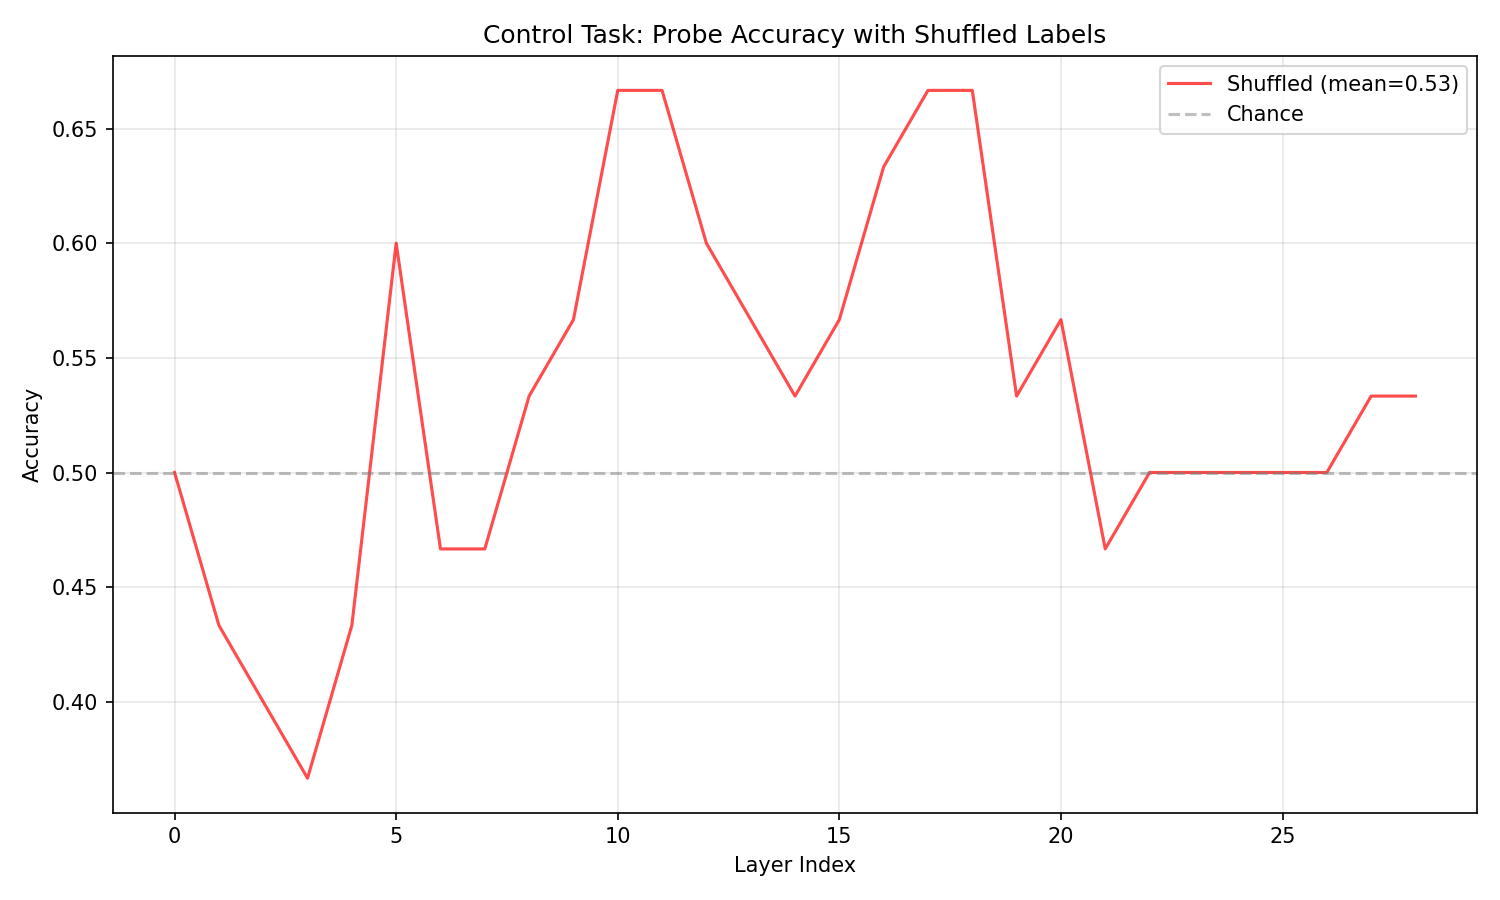


difficulty_probe_classification.png:


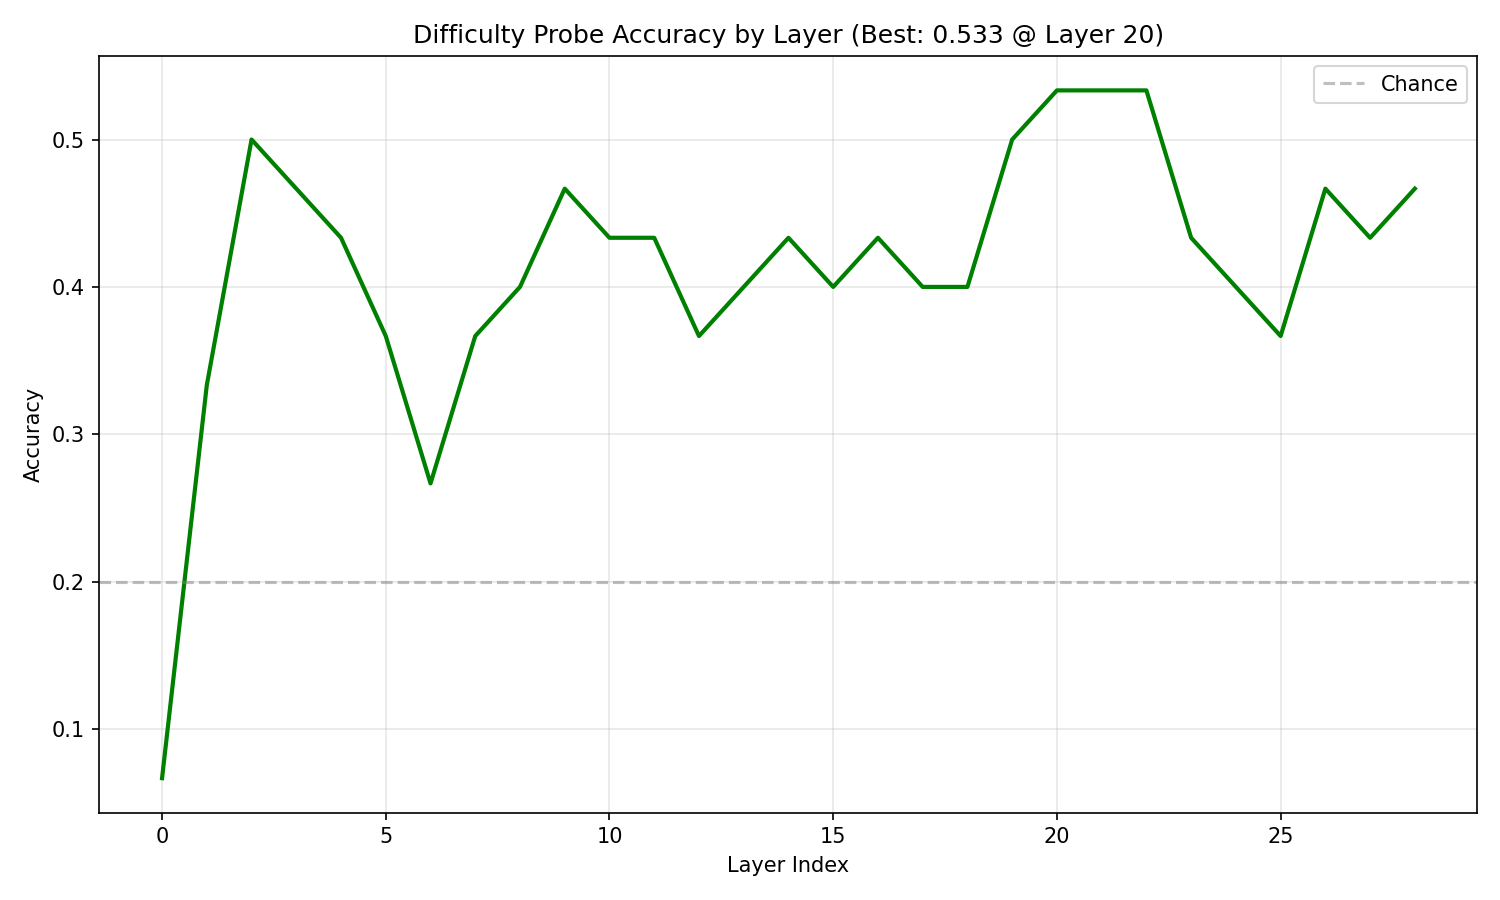


difficulty_probe_regression.png:


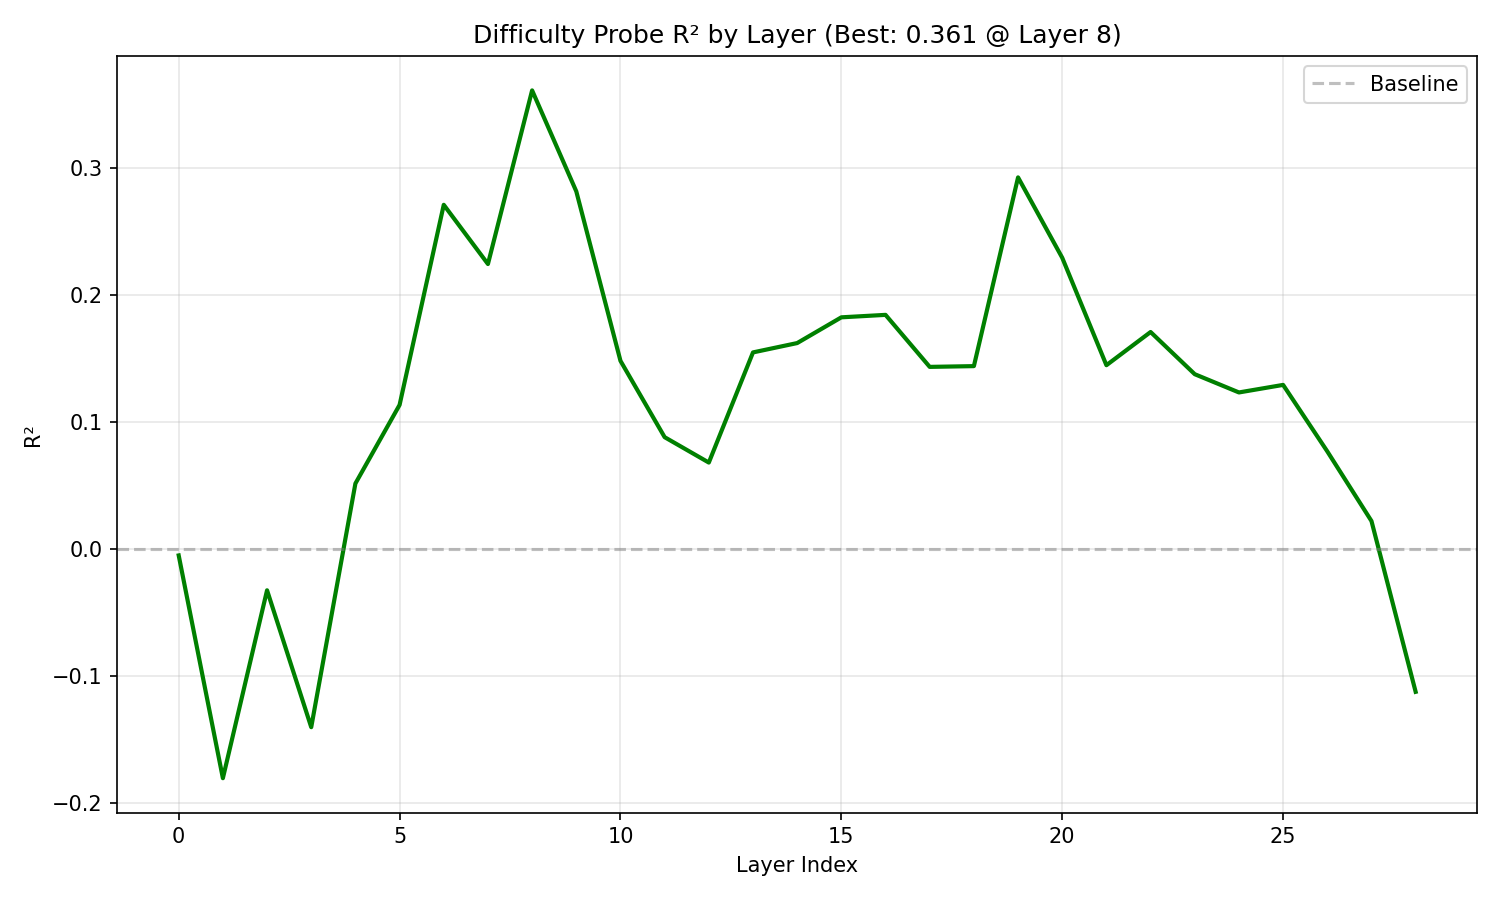


pca_layer20_correctness.png:


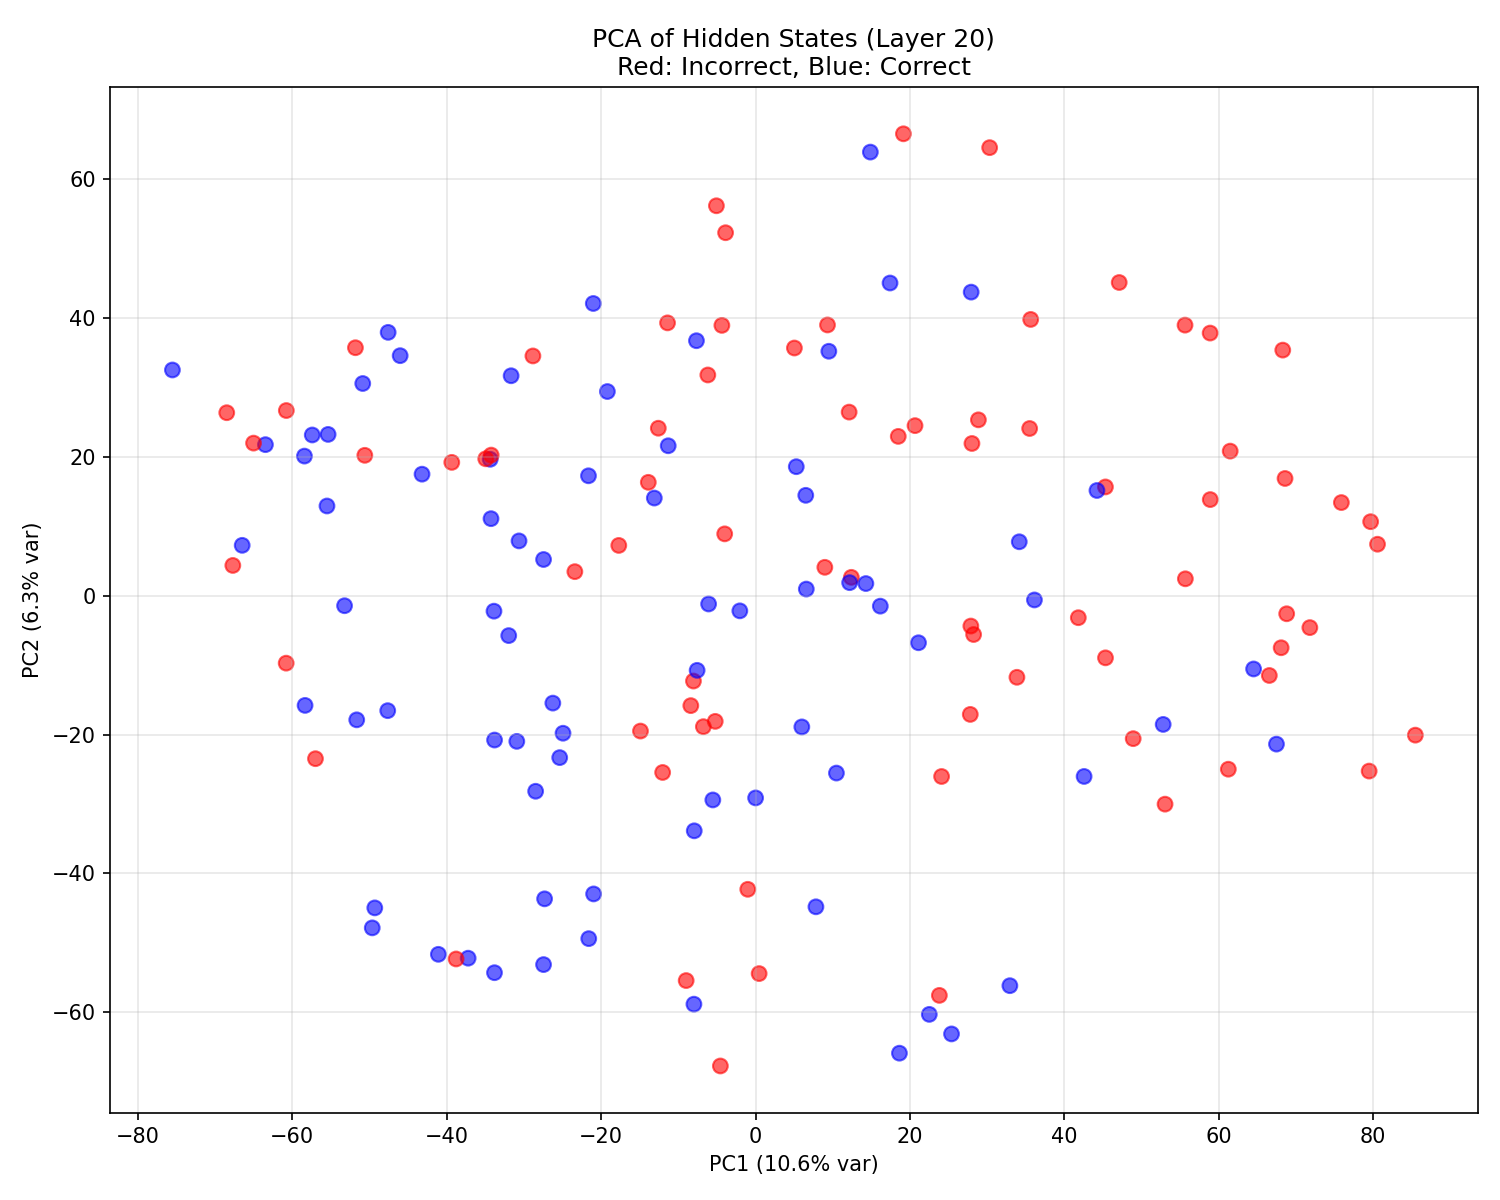


pca_layer20_difficulty.png:


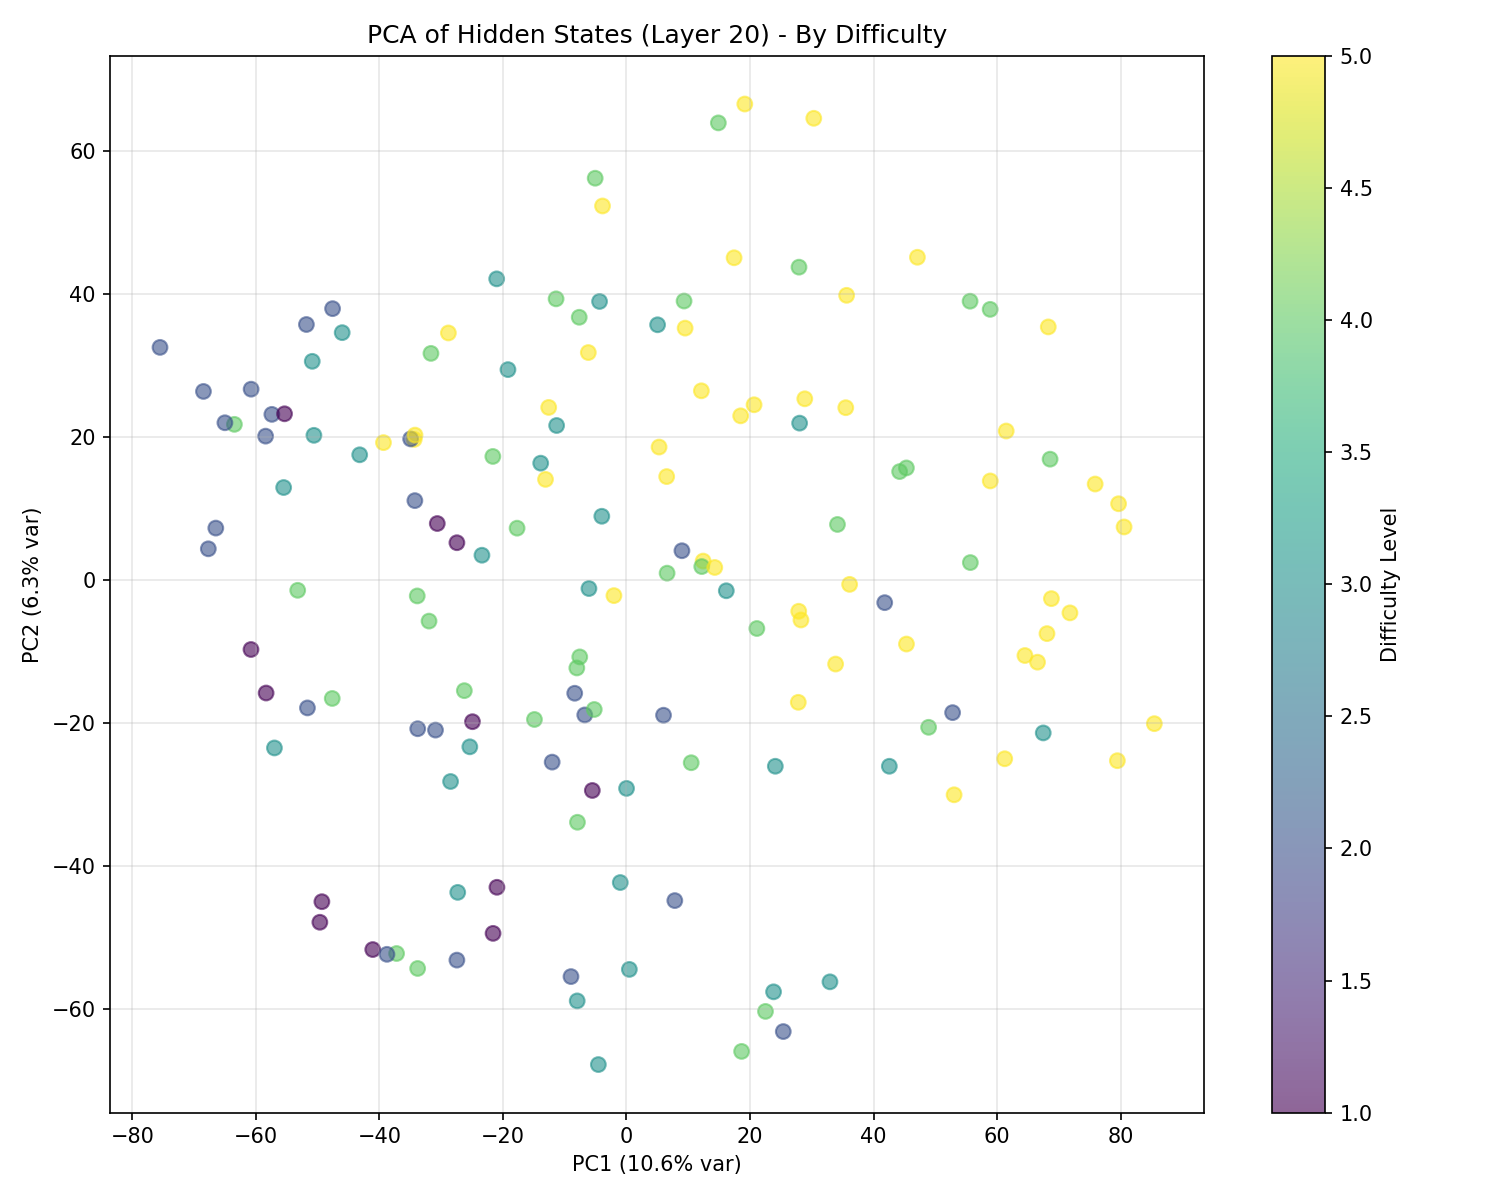


pca_layer20_topic.png:


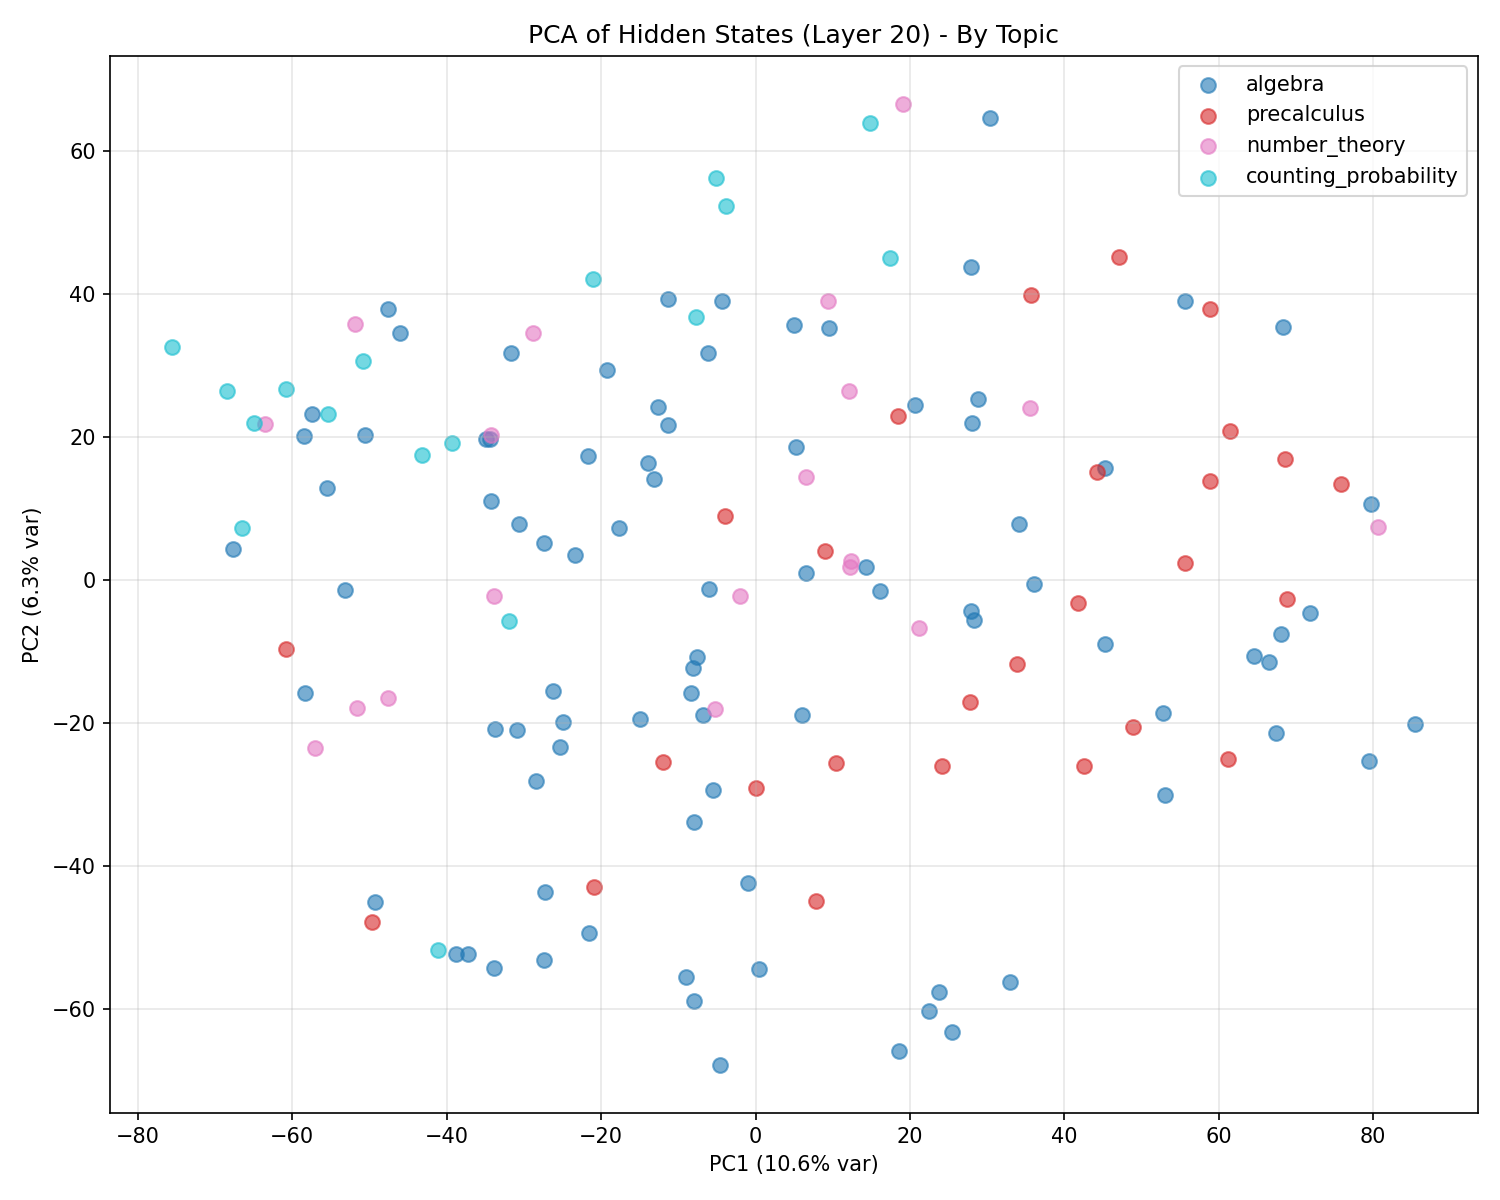


success_probe_accuracy.png:


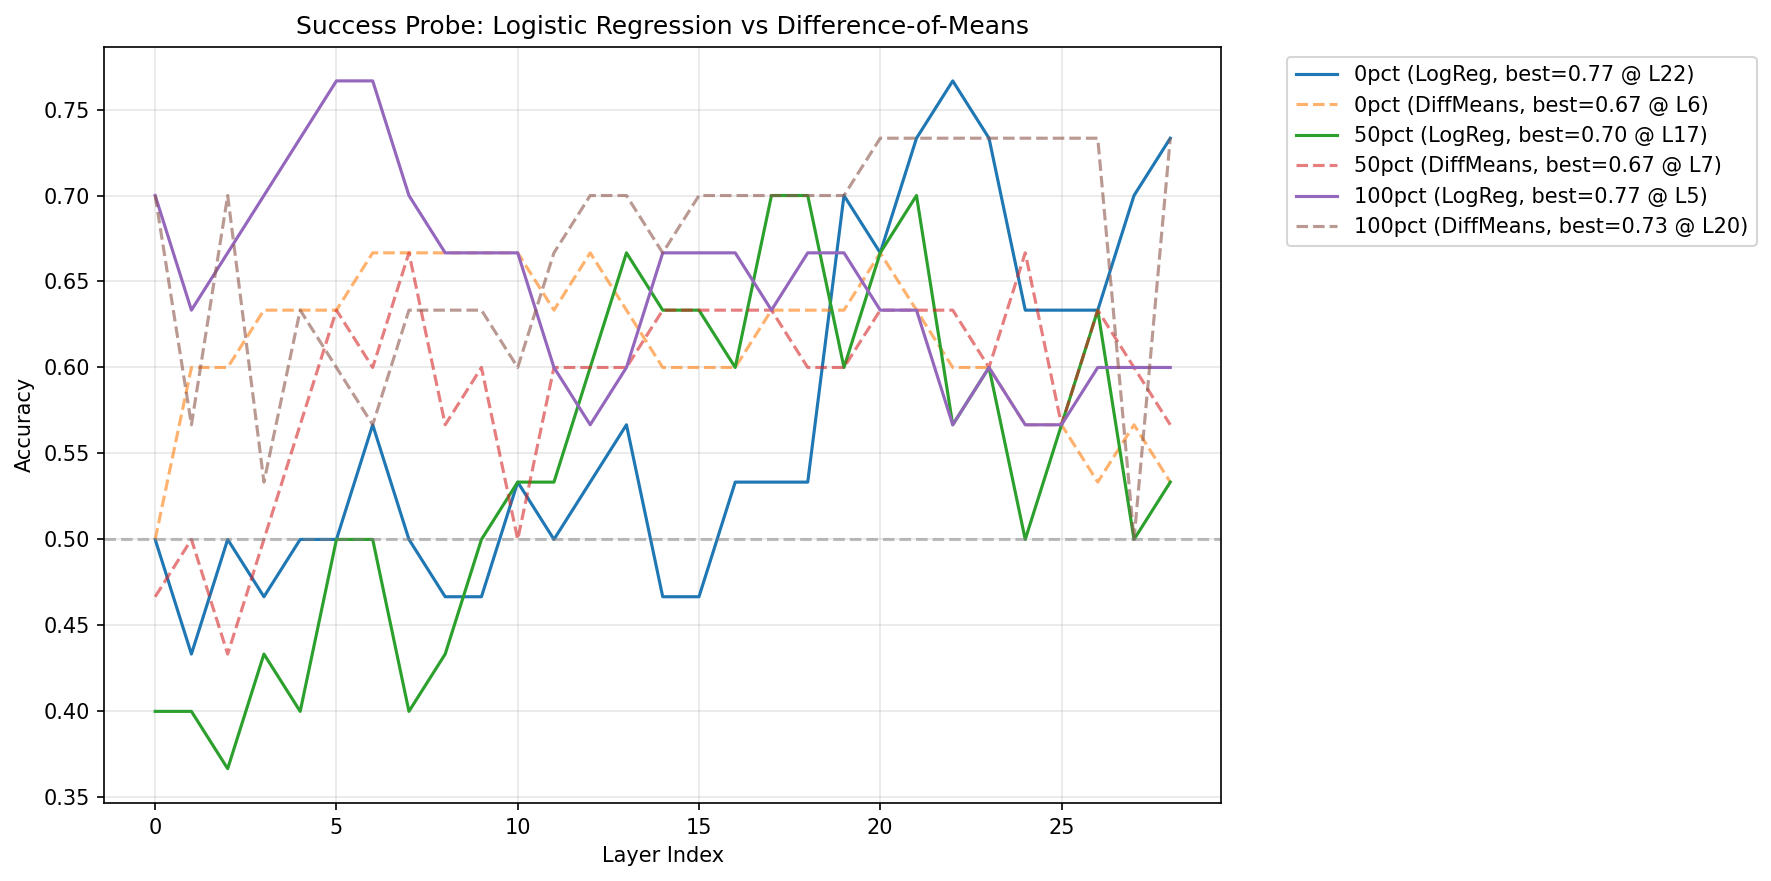


success_probe_heatmap_2d.png:


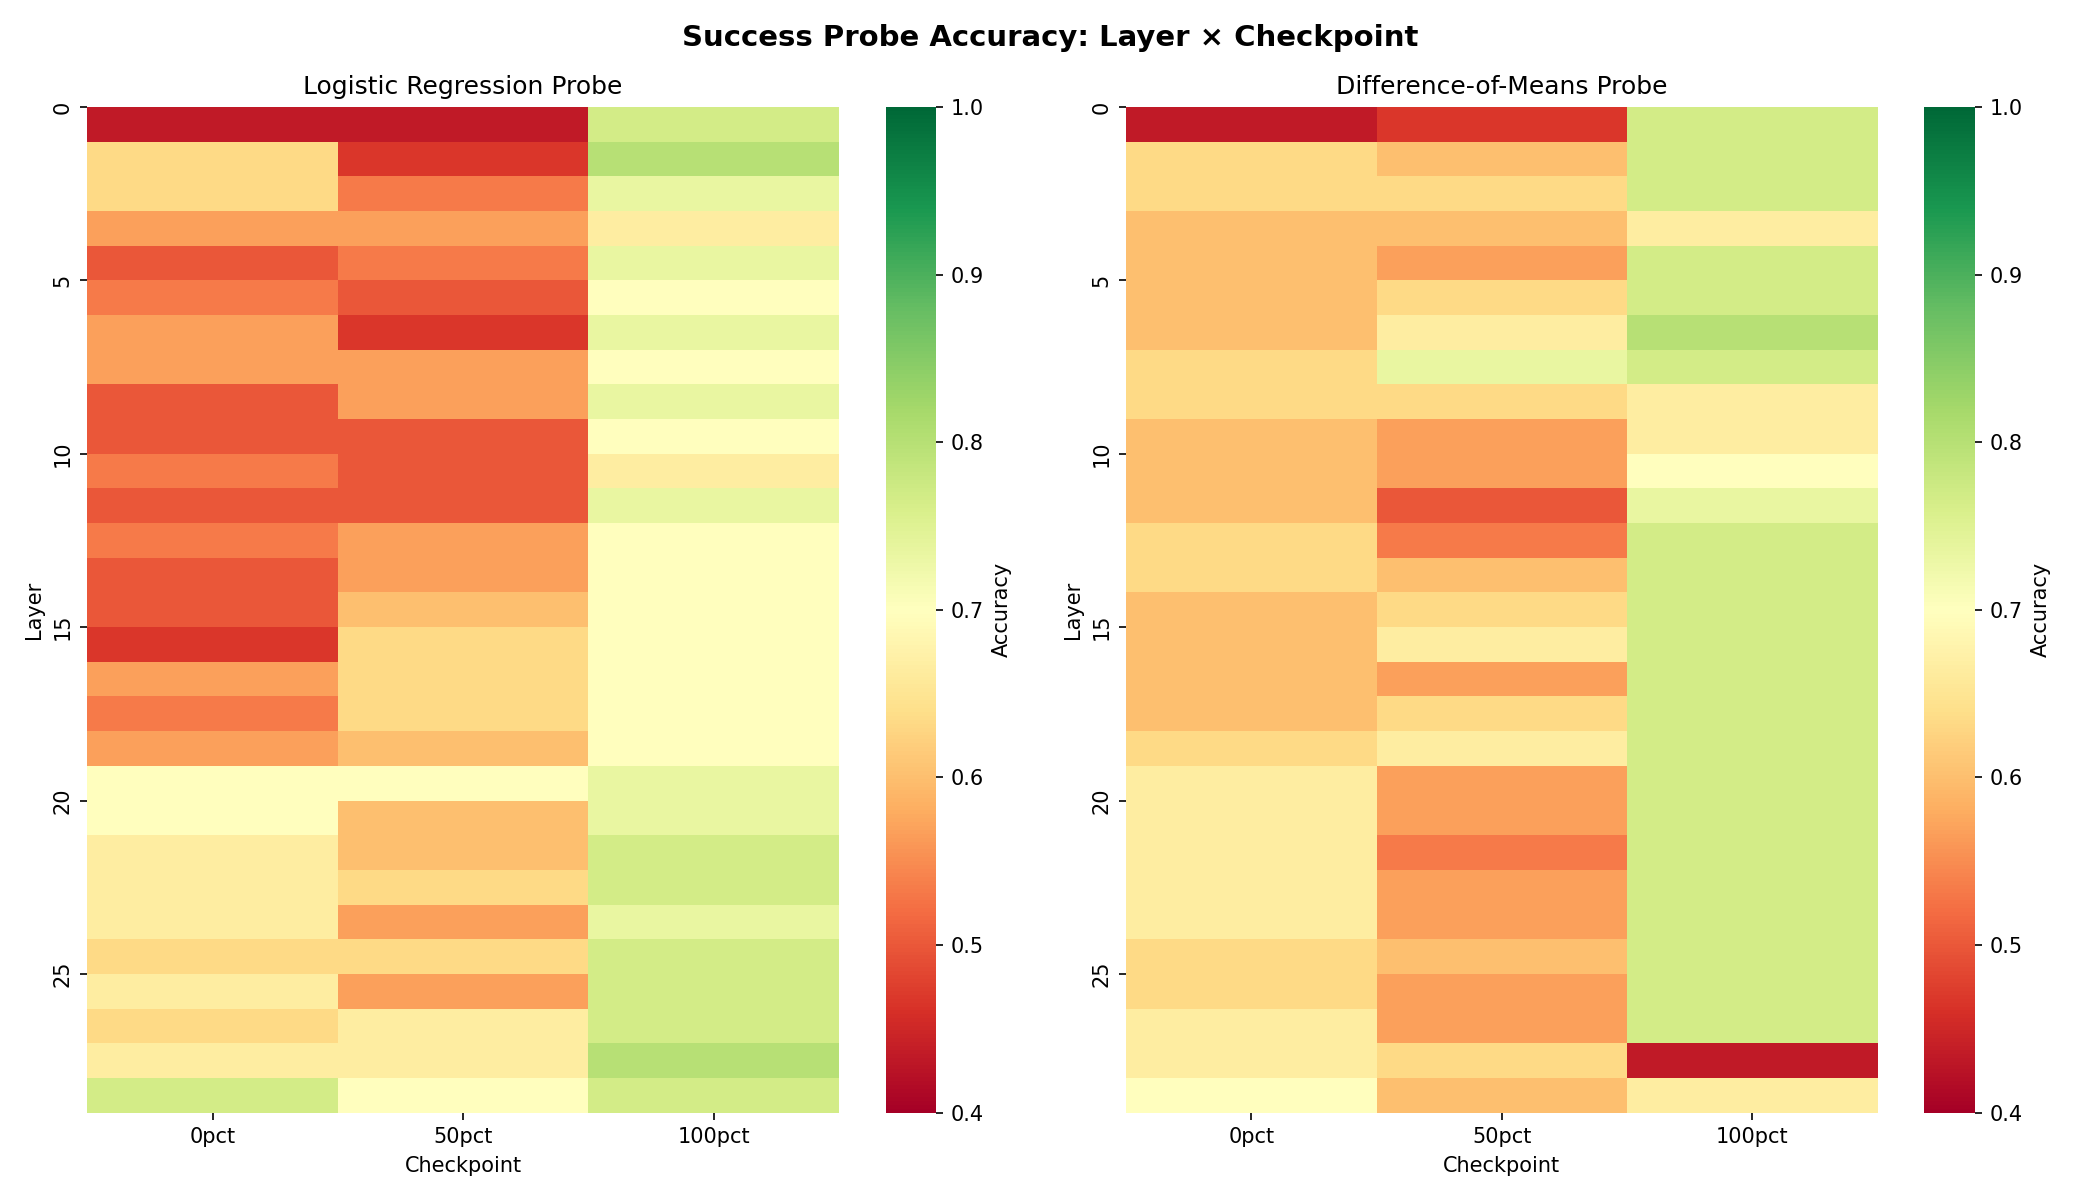


topic_probe_accuracy.png:


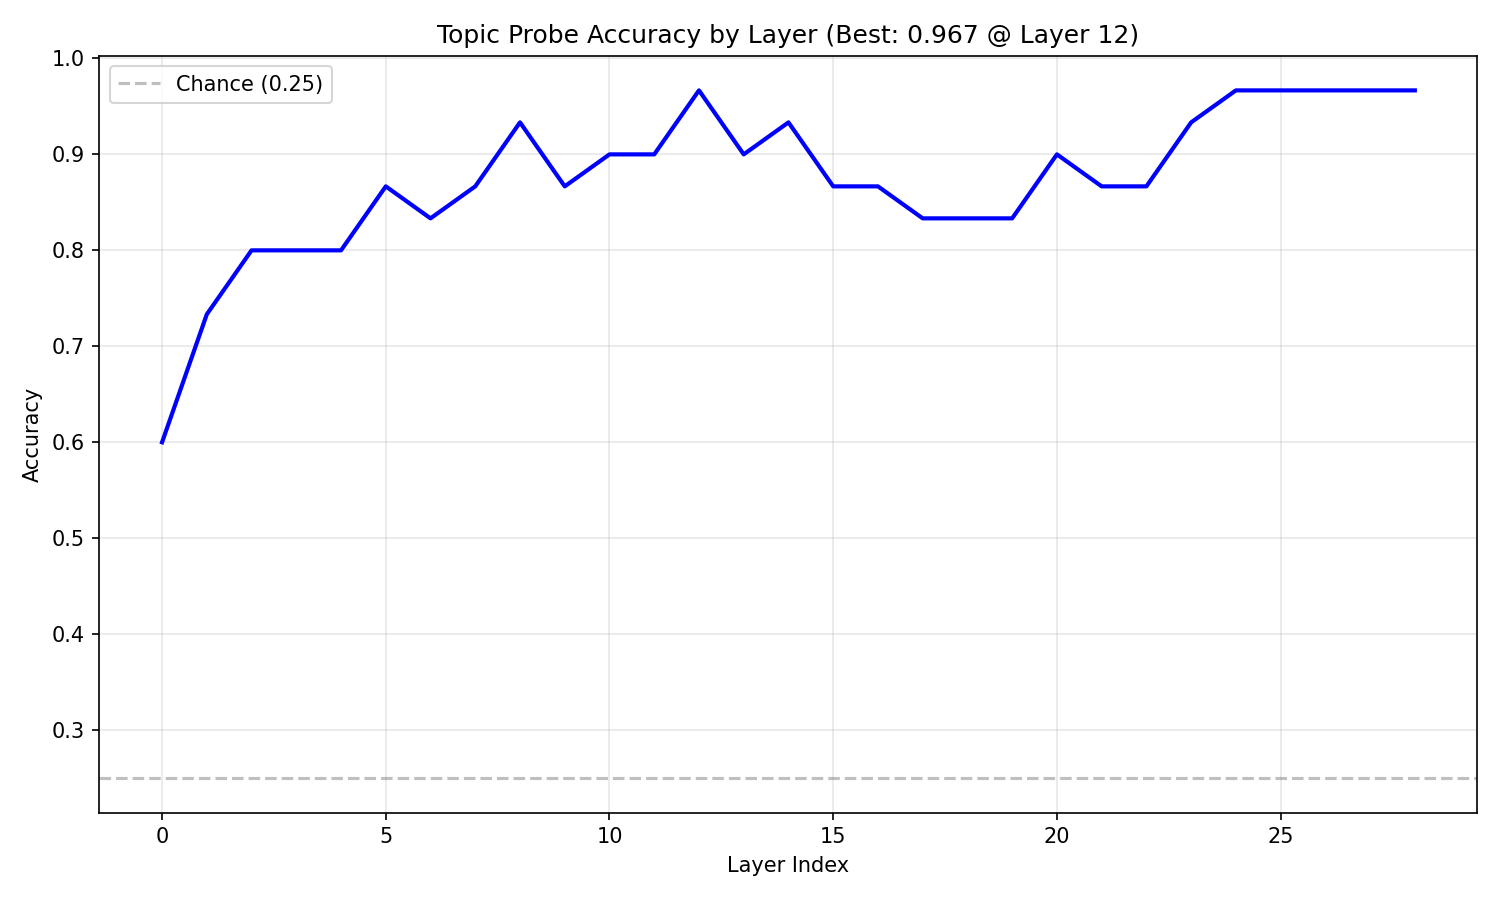


SUMMARY
  num_samples: 150
  num_layers: 29
  hidden_dim: 3584
  has_50pct: True
  success_0pct_logreg_best: 0.7666666666666667
  success_0pct_diff_best: 0.6666666666666666
  success_50pct_logreg_best: 0.7
  success_50pct_diff_best: 0.6666666666666666
  success_100pct_logreg_best: 0.7666666666666667
  success_100pct_diff_best: 0.7333333333333333
  topic_0pct_best_layer: 12
  topic_0pct_best_score: 0.9666666666666667
  difficulty_class_0pct_best_layer: 20
  difficulty_class_0pct_best_score: 0.5333333333333333
  difficulty_regress_0pct_best_layer: 8
  difficulty_regress_0pct_best_score: 0.36086996337786914


In [24]:
# Display probe results
from IPython.display import Image, display
import os

results_dir = "probe_results"

# Show all plots
for f in sorted(os.listdir(results_dir)):
    if f.endswith('.png'):
        print(f"\n{f}:")
        display(Image(filename=f"{results_dir}/{f}"))

# Show summary
import json
with open(f"{results_dir}/summary.json") as f:
    summary = json.load(f)

print("\n" + "="*50)
print("SUMMARY")
print("="*50)
for k, v in summary.items():
    print(f"  {k}: {v}")

In [11]:
# # FIRST MINI RUN
# # 1. Collect probe data (with all metadata)
# !python probing-llm-math/src/collect_probe_data.py \
#     --num_samples 10 \
#     --dataset math \
#     --balance \
#     --output_file probe_data.pt

# # 2. Train all probes
# !python probing-llm-math/src/train_probe.py \
#     --data_file probe_data.pt \
#     --output_dir probe_results

# # 3. Generate heatmap (separate run, more samples)
# !python probing-llm-math/src/stratified_eval.py \
#     --samples_per_cell 5 \
#     --output_dir eval_results

In [25]:
# import os
# from IPython.display import Image, display

# print("--- Evaluation Results ---")
# result_dir = "eval_results"

# # Print summary.txt content
# summary_path = os.path.join(result_dir, "summary.txt")
# if os.path.exists(summary_path):
#     with open(summary_path, "r") as f:
#         summary_text = f.read()
#     print(summary_text)
# else:
#     print(f"(summary not found at {summary_path})")

# # Visualize heatmap
# heatmap_path = os.path.join(result_dir, "accuracy_heatmap.png")
# if os.path.exists(heatmap_path):
#     print("Displaying accuracy heatmap:")
#     display(Image(filename=heatmap_path))
# else:
#     print(f"(heatmap not found at {heatmap_path})")

# # Optionally confirm number of results
# results_pt_path = os.path.join(result_dir, "results.pt")
# if os.path.exists(results_pt_path):
#     print(f"\nSaved results file exists: {results_pt_path}")
# else:
#     print("(results.pt not found)")



--- Evaluation Results ---
(summary not found at eval_results/summary.txt)
(heatmap not found at eval_results/accuracy_heatmap.png)
(results.pt not found)


In [13]:
# # 2. Train Probes & Analyze

# !python3 probing-llm-math/src/train_probe.py

In [26]:
# # 3. Visualize Results
# from IPython.display import Image, display
# import os

# results_dir = "probe_results"
# if os.path.exists(results_dir):
#     print("Probe Accuracy by Layer:")
#     display(Image(filename=f"{results_dir}/probe_accuracy.png"))

#     # Check for PCA plot (might vary by layer index)
#     pca_files = [f for f in os.listdir(results_dir) if f.startswith("pca_layer")]
#     if pca_files:
#         print("PCA Visualization:")
#         display(Image(filename=f"{results_dir}/{pca_files[0]}"))
# else:
#     print("No results found. Did the training script run successfully?")

Probe Accuracy by Layer:


FileNotFoundError: [Errno 2] No such file or directory: 'probe_results/probe_accuracy.png'

In [29]:
# Re-check predictions with fixed evaluator
import pandas as pd
import importlib

# Reload evaluator
import src.evaluator
importlib.reload(src.evaluator)
from src.evaluator import is_equivalent, extract_answer

df = pd.read_csv("probe_audit.csv")
new_correct = 0
changes = []

for idx, row in df.iterrows():
    gt = str(row['ground_truth'])
    pred = str(row['clean_prediction'])
    new_result = is_equivalent(pred, gt)
    if new_result != row.get('is_correct', False):
        changes.append((idx, gt, pred, new_result))
        if new_result:
            new_correct += 1

print(f"Found {len(changes)} changed evaluations ({new_correct} new correct)")
for idx, gt, pred, result in changes[:10]:
    print(f"  Row {idx}: {gt} vs {pred} -> {'✓' if result else '✗'}")

Found 20 changed evaluations (20 new correct)
  Row 5: 4210_{5} vs 4210_5 -> ✓
  Row 21: \dfrac{1}{128} vs \frac{1}{128} -> ✓
  Row 30: 575\text{ students} vs 575 -> ✓
  Row 35: 840^\circ vs 840 -> ✓
  Row 51: \frac 59 vs \frac{5}{9} -> ✓
  Row 58: \frac 34 vs \frac{3}{4} -> ✓
  Row 61: \dfrac{3}{2} vs \frac{3}{2} -> ✓
  Row 93: 4210_{7} vs 4210_7 -> ✓
  Row 98: \text{A} vs A -> ✓
  Row 101: D vs \frac{C^2 - C^2(1 - D) + D(1 - D)^2}{C^2 + (1 - D)^2} = \frac{C^2 - C^2 + C^2 D + D(1 - 2D + D^2)}{C^2 + (1 - D)^2} = \frac{C^2 D + D - 2D^2 + D^3}{C^2 + (1 - D)^2} = \frac{D(C^2 + 1 - 2D + D^2)}{C^2 + (1 - D)^2} = \frac{D(C^2 + (1 - D)^2)}{C^2 + (1 - D)^2} = D. -> ✓


In [30]:
# Quick test with smaller model
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

model_name = "Qwen/Qwen2.5-Math-1.5B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    load_in_4bit=True,
    device_map="cuda"
)

# Test one problem
messages = [
    {"role": "system", "content": "Solve and put answer in \\boxed{}."},
    {"role": "user", "content": "What is 15% of 80?"}
]
text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
inputs = tokenizer(text, return_tensors="pt").to("cuda")
out = model.generate(**inputs, max_new_tokens=256)
print(tokenizer.decode(out[0], skip_special_tokens=True))

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/656 [00:00<?, ?B/s]

The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

system
Solve and put answer in \boxed{}.
user
What is 15% of 80?
assistant
To find 15% of 80, we can follow these steps:

1. Convert the percentage to a decimal. Since 15% is the same as 15 out of 100, we can write it as:
   \[
   15\% = \frac{15}{100} = 0.15
   \]

2. Multiply the decimal by the number 80:
   \[
   0.15 \times 80
   \]

3. Perform the multiplication:
   \[
   0.15 \times 80 = 12
   \]

So, 15% of 80 is \boxed{12}.


In [32]:
# Pull updates
!cd probing-llm-math && git pull

# Collect data with both pooling methods (default)
!python probing-llm-math/src/collect_probe_data.py \
    --num_samples 200 \
    --dataset math \
    --balance \
    --output_file probe_data_1.5b.pt \
    --seed 42

# Train probes (handles new format automatically)
!python probing-llm-math/src/train_probe.py \
    --data_file probe_data_1.5b.pt \
    --output_dir probe_results_1.5b

Already up to date.
Loading math dataset...
Loaded 4521 problems
Topics: {'algebra', 'number_theory', 'counting_probability', 'precalculus'}
Levels: {1, 2, 3, 4, 5}
Dataset size: 4521
Loading model: Qwen/Qwen2.5-Math-1.5B-Instruct (4-bit: True)...
2025-11-30 02:56:19.214231: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764471379.233672   83297 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764471379.239010   83297 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1764471379.253015   83297 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:17

In [4]:
# Pull updates
!cd probing-llm-math && git pull

# Collect data with both pooling methods (default)
!python probing-llm-math/src/collect_probe_data.py \
    --num_samples 1000 \
    --dataset math \
    --balance \
    --output_file probe_data_1.5b_1000.pt \
    --seed 42

# Train probes (handles new format automatically)
!python probing-llm-math/src/train_probe.py \
    --data_file probe_data_1.5b_1000.pt \
    --output_dir probe_data_1.5b_1000

Already up to date.
Loading math dataset...
README.md: 3.93kB [00:00, 22.6MB/s]
Traceback (most recent call last):
  File "/usr/lib/python3.12/http/client.py", line 1430, in getresponse
    response.begin()
  File "/usr/lib/python3.12/http/client.py", line 331, in begin
    version, status, reason = self._read_status()
                              ^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/http/client.py", line 292, in _read_status
    line = str(self.fp.readline(_MAXLINE + 1), "iso-8859-1")
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/socket.py", line 720, in readinto
    return self._sock.recv_into(b)
           ^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/ssl.py", line 1251, in recv_into
    return self.read(nbytes, buffer)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/ssl.py", line 1103, in read
    return self._sslobj.read(len, buffer)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
KeyboardInterrupt

During handling of the ab

In [ ]:
!python probing-llm-math/src/stratified_eval.py \
    --samples_per_cell 100 \
    --output_dir eval_results_1.5b_100

In [ ]:
import shutil
shutil.copytree("probe_results_1.5b_1000", "/content/drive/MyDrive/probe_results_1.5b_1000", dirs_exist_ok=True)
shutil.copy("probe_data_1.5b_1000.pt", "/content/drive/MyDrive/probe_data_1.5b_1000.pt")
print("Saved to Drive!")

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# Pull updates
!cd probing-llm-math && git pull

# Collect data with both pooling methods (default)
# ~1000 samples × 52s = ~14.5 hours
!python probing-llm-math/src/collect_probe_data.py \
    --num_samples 500 \
    --dataset math \
    --balance \
    --output_file probe_data_1.5b_1000.pt \
    --seed 42

# Train probes (handles new format automatically)
# FIX: output_dir was wrong (said probe_data not probe_results)
!python probing-llm-math/src/train_probe.py \
    --data_file probe_data_1.5b_1000.pt \
    --output_dir probe_results_1.5b_1000

# ⚠️ WARNING: 100 samples/cell × 4 topics × 5 levels = 2000 samples = ~29 MORE hours!
# Reduce to 20 samples/cell = 400 samples = ~6 hours
!python probing-llm-math/src/stratified_eval.py \
    --samples_per_cell 20 \
    --output_dir eval_results_1.5b

# Save to Drive
import shutil
shutil.copytree("probe_results_1.5b_1000", "/content/drive/MyDrive/probe_results_1.5b_1000", dirs_exist_ok=True)
shutil.copy("probe_data_1.5b_1000.pt", "/content/drive/MyDrive/probe_data_1.5b_1000.pt")
shutil.copytree("eval_results_1.5b", "/content/drive/MyDrive/eval_results_1.5b", dirs_exist_ok=True)
print("Saved to Drive!")

Already up to date.
Loading math dataset...
README.md: 3.93kB [00:00, 19.4MB/s]
algebra/train-00000-of-00001.parquet: 100% 505k/505k [00:01<00:00, 424kB/s]
algebra/test-00000-of-00001.parquet: 100% 353k/353k [00:00<00:00, 724kB/s]
Generating train split: 100% 1744/1744 [00:00<00:00, 46175.63 examples/s]
Generating test split: 100% 1187/1187 [00:00<00:00, 241693.23 examples/s]
number_theory/train-00000-of-00001.parqu(…): 100% 309k/309k [00:00<00:00, 631kB/s]
number_theory/test-00000-of-00001.parque(…): 100% 182k/182k [00:00<00:00, 371kB/s]
Generating train split: 100% 869/869 [00:00<00:00, 182406.67 examples/s]
Generating test split: 100% 540/540 [00:00<00:00, 177376.78 examples/s]
intermediate_algebra/train-00000-of-0000(…): 100% 575k/575k [00:00<00:00, 1.17MB/s]
intermediate_algebra/test-00000-of-00001(…): 100% 395k/395k [00:00<00:00, 807kB/s]
Generating train split: 100% 1295/1295 [00:00<00:00, 183067.87 examples/s]
Generating test split: 100% 903/903 [00:00<00:00, 209645.55 examples

In [7]:
# Download audit log to view/analyze
from google.colab import files
files.download('probe_audit.csv')

# Or copy to Drive
import shutil
shutil.copy('probe_audit.csv', '/content/drive/MyDrive/probe_audit_500.csv')
print("Copied audit log to Drive!")

# Quick preview
import pandas as pd
df = pd.read_csv('probe_audit.csv')
print(f"Total samples: {len(df)}")
print(f"Correct: {df['is_correct'].sum()}")
print(f"Incorrect: {(~df['is_correct']).sum()}")
print("\nSample of incorrect predictions:")
print(df[df['is_correct'] == False][['topic', 'level', 'ground_truth', 'clean_prediction']].head(10))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Copied audit log to Drive!
Total samples: 500
Correct: 250
Incorrect: 250

Sample of incorrect predictions:
                   topic    level          ground_truth  \
0                algebra  Level 5  2004 \sqrt{2} - 2003   
7                algebra  Level 3                    90   
12               algebra  Level 5                   5.5   
15               algebra  Level 5                 x = 3   
16               algebra  Level 5                    89   
24               algebra  Level 4          -3(x+2)(x-1)   
26  counting_probability  Level 5                    84   
27           precalculus  Level 2         \cos 58^\circ   
32         number_theory  Level 4                   100   
36  counting_probability  Level 5                  1041   

                                     clean_prediction  
0                                                   1  
7                                                  70  
12                                                2.8  
15                

In [9]:
# Force update in Colab
!cd probing-llm-math && git fetch origin && git reset --hard origin/colab-pipeline-setup

# Clear Python cache
import sys
for mod in list(sys.modules.keys()):
    if 'model_utils' in mod or 'stratified_eval' in mod or 'evaluator' in mod:
        del sys.modules[mod]

# Now run stratified eval
!python probing-llm-math/src/stratified_eval.py \
    --samples_per_cell 20 \
    --output_dir eval_results_1.5b

remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 4 (delta 3), reused 4 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 441 bytes | 441.00 KiB/s, done.
From https://github.com/1hamzaiqbal/probing-llm-math
   7d3f70a..e4c2d25  colab-pipeline-setup -> origin/colab-pipeline-setup
HEAD is now at e4c2d25 Fix: Use generate_answer instead of generate_answer_fast
Loading stratified dataset...
Loaded 400 problems

Problem distribution:
  algebra: [20, 20, 20, 20, 20]
  number_theory: [20, 20, 20, 20, 20]
  counting_and_probability: [20, 20, 20, 20, 20]
  precalculus: [20, 20, 20, 20, 20]

Loading model...
Loading model: Qwen/Qwen2.5-Math-1.5B-Instruct (4-bit: True)...
2025-11-30 18:24:24.687610: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To

In [10]:
!cd probing-llm-math && git fetch origin && git reset --hard origin/colab-pipeline-setup

remote: Enumerating objects: 54, done.
remote: Counting objects: 100% (54/54), done.
remote: Compressing objects: 100% (34/34), done.
remote: Total 45 (delta 15), reused 39 (delta 9), pack-reused 0 (from 0)
Unpacking objects: 100% (45/45), 1.09 MiB | 10.60 MiB/s, done.
From https://github.com/1hamzaiqbal/probing-llm-math
   e4c2d25..93d729f  colab-pipeline-setup -> origin/colab-pipeline-setup
HEAD is now at 93d729f Major repo cleanup and reorganization


In [11]:
import pandas as pd
import importlib
import sys

# Clear cache
for mod in list(sys.modules.keys()):
    if 'evaluator' in mod:
        del sys.modules[mod]

# Import fresh
sys.path.insert(0, 'probing-llm-math/src')
from evaluator import is_equivalent, extract_answer

# Re-check all predictions
df = pd.read_csv('probe_audit.csv')
new_correct = 0
changes = []

for idx, row in df.iterrows():
    gt = str(row['ground_truth'])
    pred = str(row['clean_prediction'])
    old_result = row['is_correct']
    new_result = is_equivalent(pred, gt)

    if new_result != old_result:
        changes.append((idx, gt, pred, old_result, new_result))
        if new_result:
            new_correct += 1

print(f"Found {len(changes)} changed evaluations ({new_correct} new correct)")
for idx, gt, pred, old, new in changes[:15]:
    symbol = "✓" if new else "✗"
    print(f"  Row {idx}: {gt[:30]} vs {pred[:30]} -> {symbol}")

Found 11 changed evaluations (11 new correct)
  Row 15: x = 3 vs 3 -> ✓
  Row 24: -3(x+2)(x-1) vs -3x^2 - 3x + 6 -> ✓
  Row 135: -\frac12 vs -\frac{1}{2} -> ✓
  Row 232: x = 4 vs 4 -> ✓
  Row 236: \frac{\sqrt6}3 vs \frac{\sqrt{6}}{3} -> ✓
  Row 371: \frac78 vs \frac{7}{8} -> ✓
  Row 394: b=4 vs 4 -> ✓
  Row 429: 1+\sqrt5 vs 1 + \sqrt{5} -> ✓
  Row 469: -\frac32 vs -\frac{3}{2} -> ✓
  Row 473: \frac12 vs \frac{1}{2} -> ✓
  Row 476: (4x - 7) vs 4x - 7 -> ✓


In [12]:
import torch

# Load existing data
loaded = torch.load('probe_data_1.5b_1000.pt')
data = loaded['data']
metadata = loaded['metadata']

# Update is_correct for each sample based on new evaluator
updated = 0
for d in data:
    gt = str(d['ground_truth'])
    pred = extract_answer(str(d['prediction']))
    new_correct = is_equivalent(pred, gt)
    if new_correct != d['is_correct']:
        d['is_correct'] = new_correct
        updated += 1

print(f"Updated {updated} labels")

# Count new balance
correct = sum(1 for d in data if d['is_correct'])
print(f"New balance: {correct} correct, {len(data) - correct} incorrect")

# Save corrected data
torch.save({'data': data, 'metadata': metadata}, 'probe_data_1.5b_500_fixed.pt')
print("Saved to probe_data_1.5b_500_fixed.pt")

Updated 11 labels
New balance: 261 correct, 239 incorrect
Saved to probe_data_1.5b_500_fixed.pt


In [13]:
!python probing-llm-math/src/train_probe.py \
    --data_file probe_data_1.5b_500_fixed.pt \
    --output_dir probe_results_1.5b_500_fixed

Loading data from probe_data_1.5b_500_fixed.pt...
Loaded 500 samples (new format with metadata)
Metadata: {'num_samples': 500, 'num_layers': 29, 'hidden_dim': 1536, 'pooling_method': 'both', 'dataset': 'math', 'seed': 42, 'has_50pct': True, 'has_mean_pooling': True, 'has_last_token': True}
Num layers: 29, Hidden dim: 1536
Topics: ['number_theory', 'precalculus', 'algebra', 'counting_probability']
Levels: [1, 2, 3, 4, 5]
Has 50% checkpoints: True
Has mean pooling: True

TRAINING SUCCESS PROBES
Class balance: 261 correct, 239 incorrect

--- 0pct checkpoint ---
/content/probing-llm-math/src/train_probe.py:98: RuntimeWarning: invalid value encountered in divide
  w = w / w_norm  # Normalize
  Layer 0: LogReg=0.480, DiffMeans=0.480
  Layer 5: LogReg=0.620, DiffMeans=0.650
  Layer 10: LogReg=0.600, DiffMeans=0.650
  Layer 15: LogReg=0.720, DiffMeans=0.690
  Layer 20: LogReg=0.680, DiffMeans=0.700
  Layer 25: LogReg=0.650, DiffMeans=0.690
  LogReg Best: Layer 17 = 0.730
  DiffMeans Best: Laye

Already up to date.
Loaded 500 samples from probe_audit.csv

TOKEN COUNT STATISTICS

Overall:
  Mean tokens: 594.5
  Median tokens: 537.5
  Std tokens: 281.2
  Min: 137, Max: 1024

Correct answers (n=250):
  Mean tokens: 458.1
  Median tokens: 399.5
  Std tokens: 206.4

Incorrect answers (n=250):
  Mean tokens: 731.0
  Median tokens: 777.0
  Std tokens: 280.2

T-test (correct vs incorrect):
  t-statistic: -12.401
  p-value: 0.0000
  → Significant difference!
/content/probing-llm-math/src/analyze_tokens.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Correctness', y='num_tokens', ax=ax2, palette=['green', 'red'])

Saved: token_analysis/token_distribution.png
Saved: token_analysis/accuracy_by_tokens.png
Saved: token_analysis/tokens_by_topic_level.png
Saved: token_analysis/token_trend.png

SUMMARY

Best accuracy range: 317-

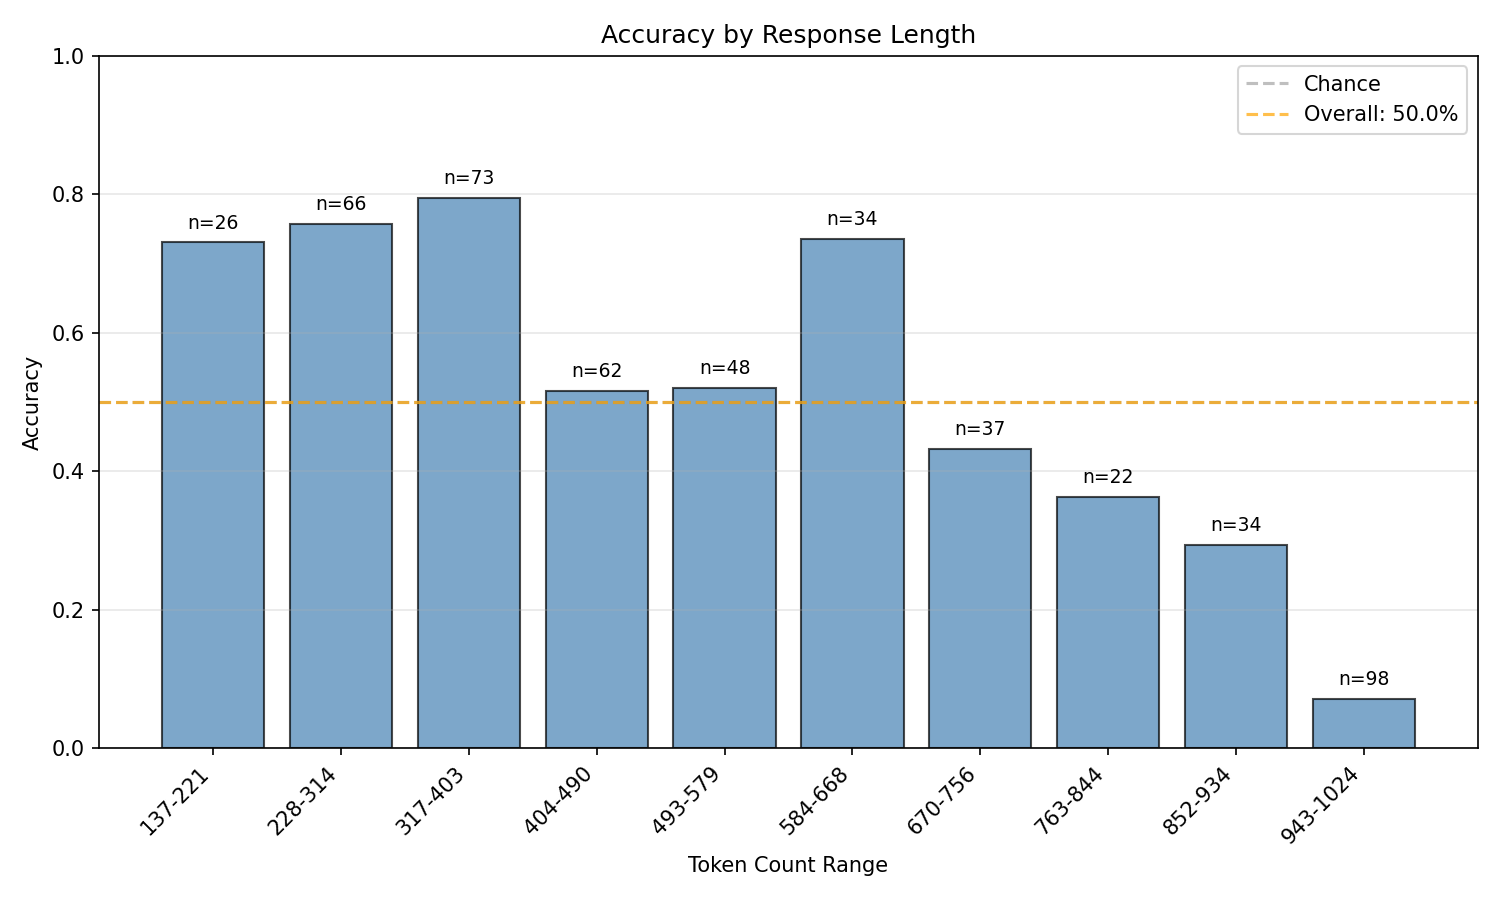


token_distribution.png:


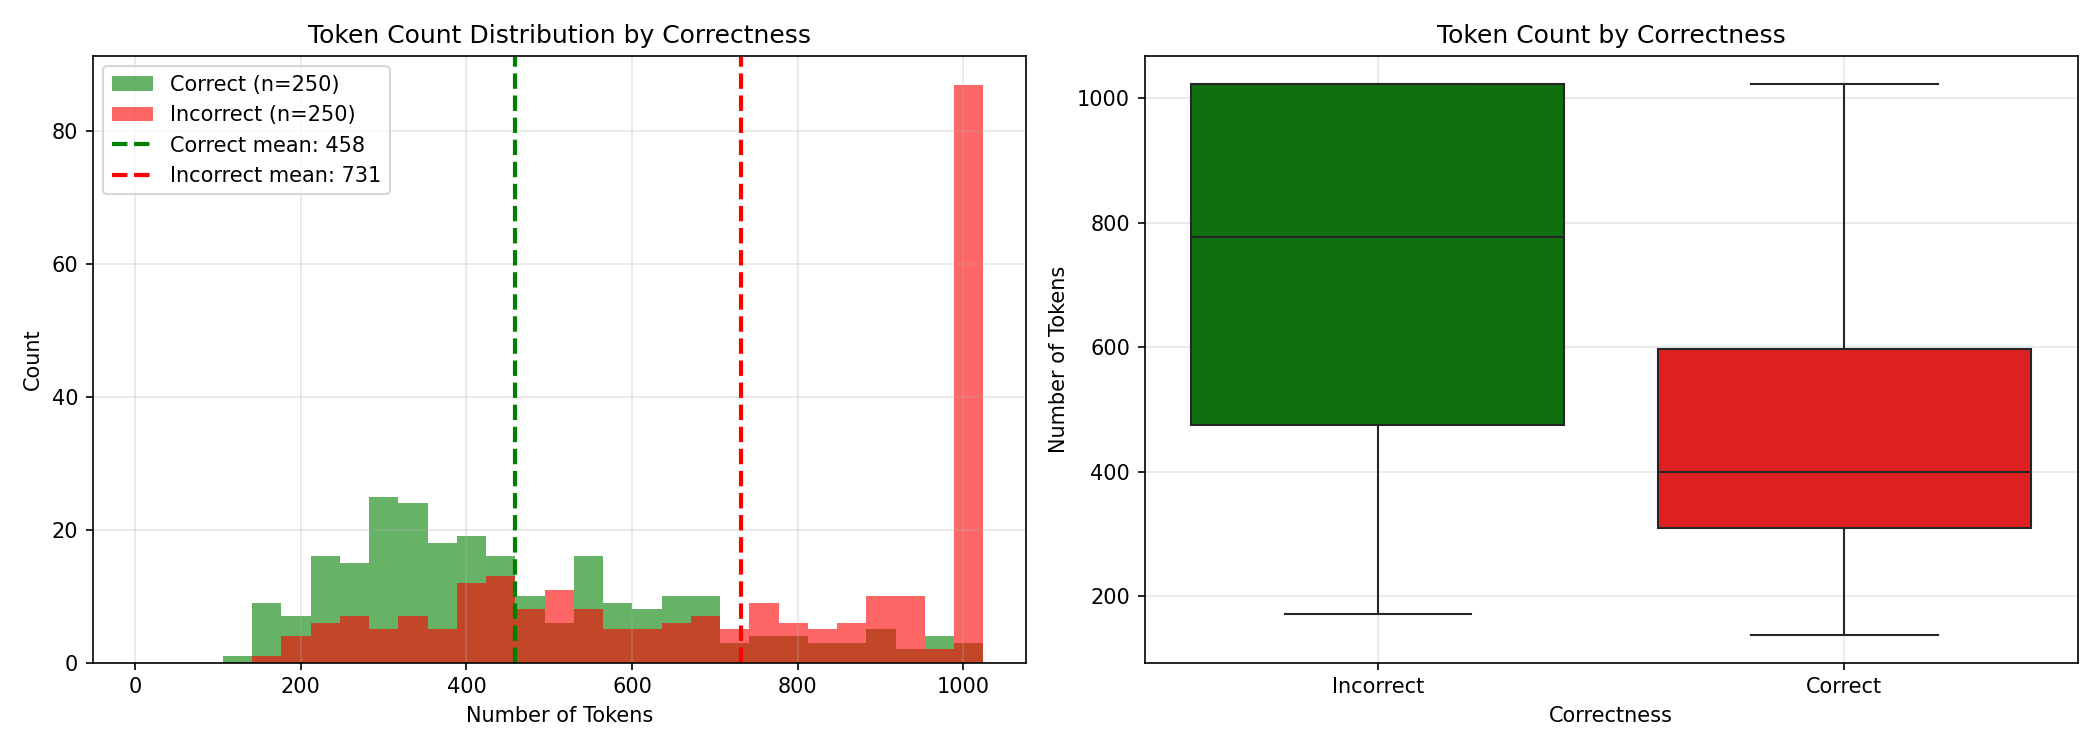


token_trend.png:


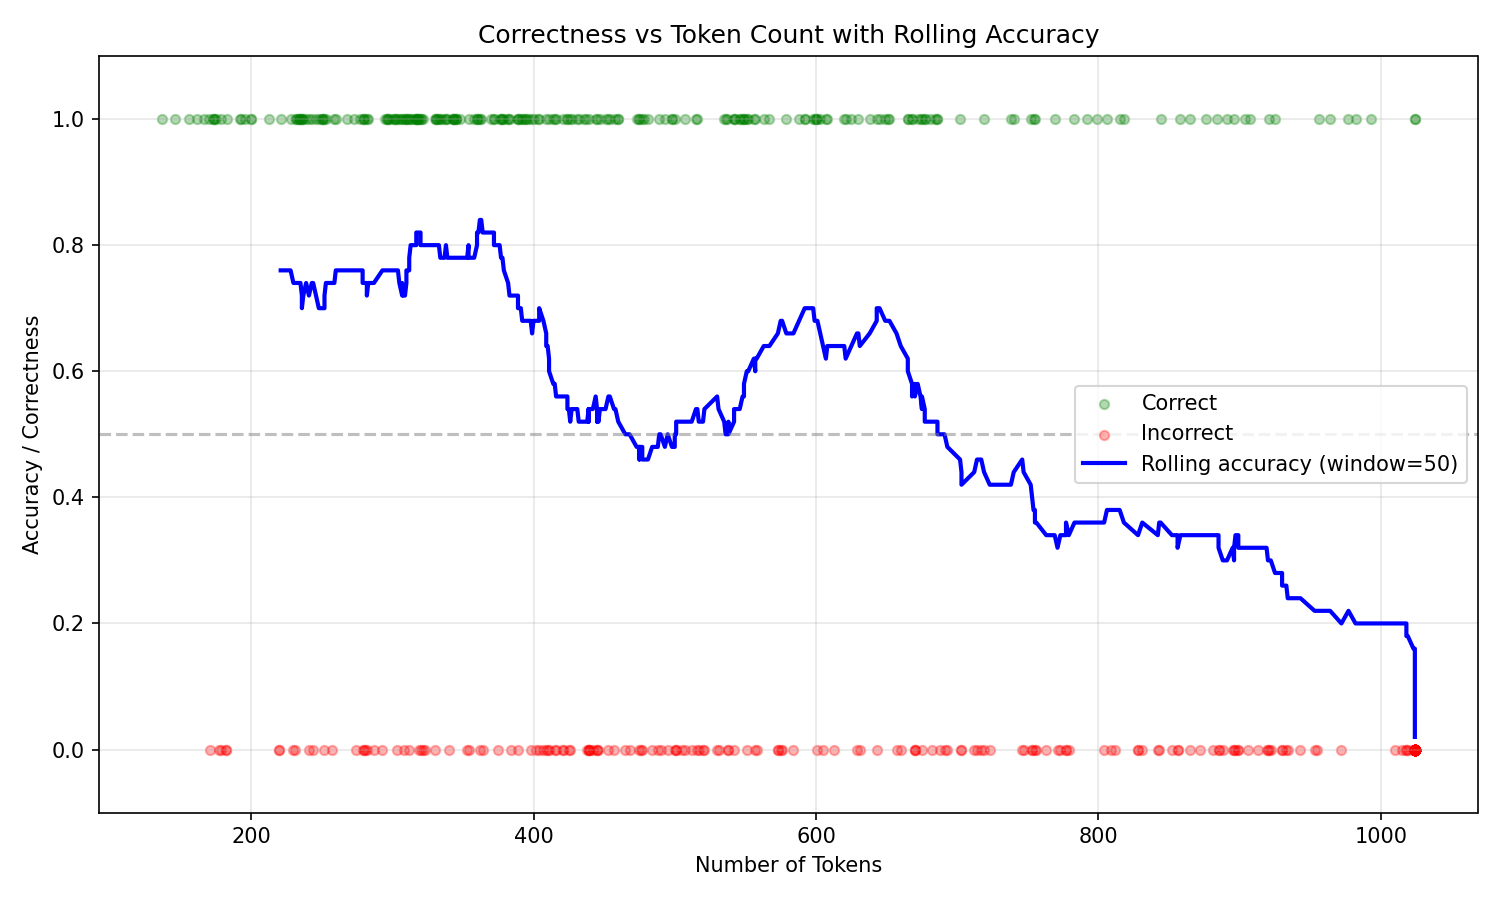


tokens_by_topic_level.png:


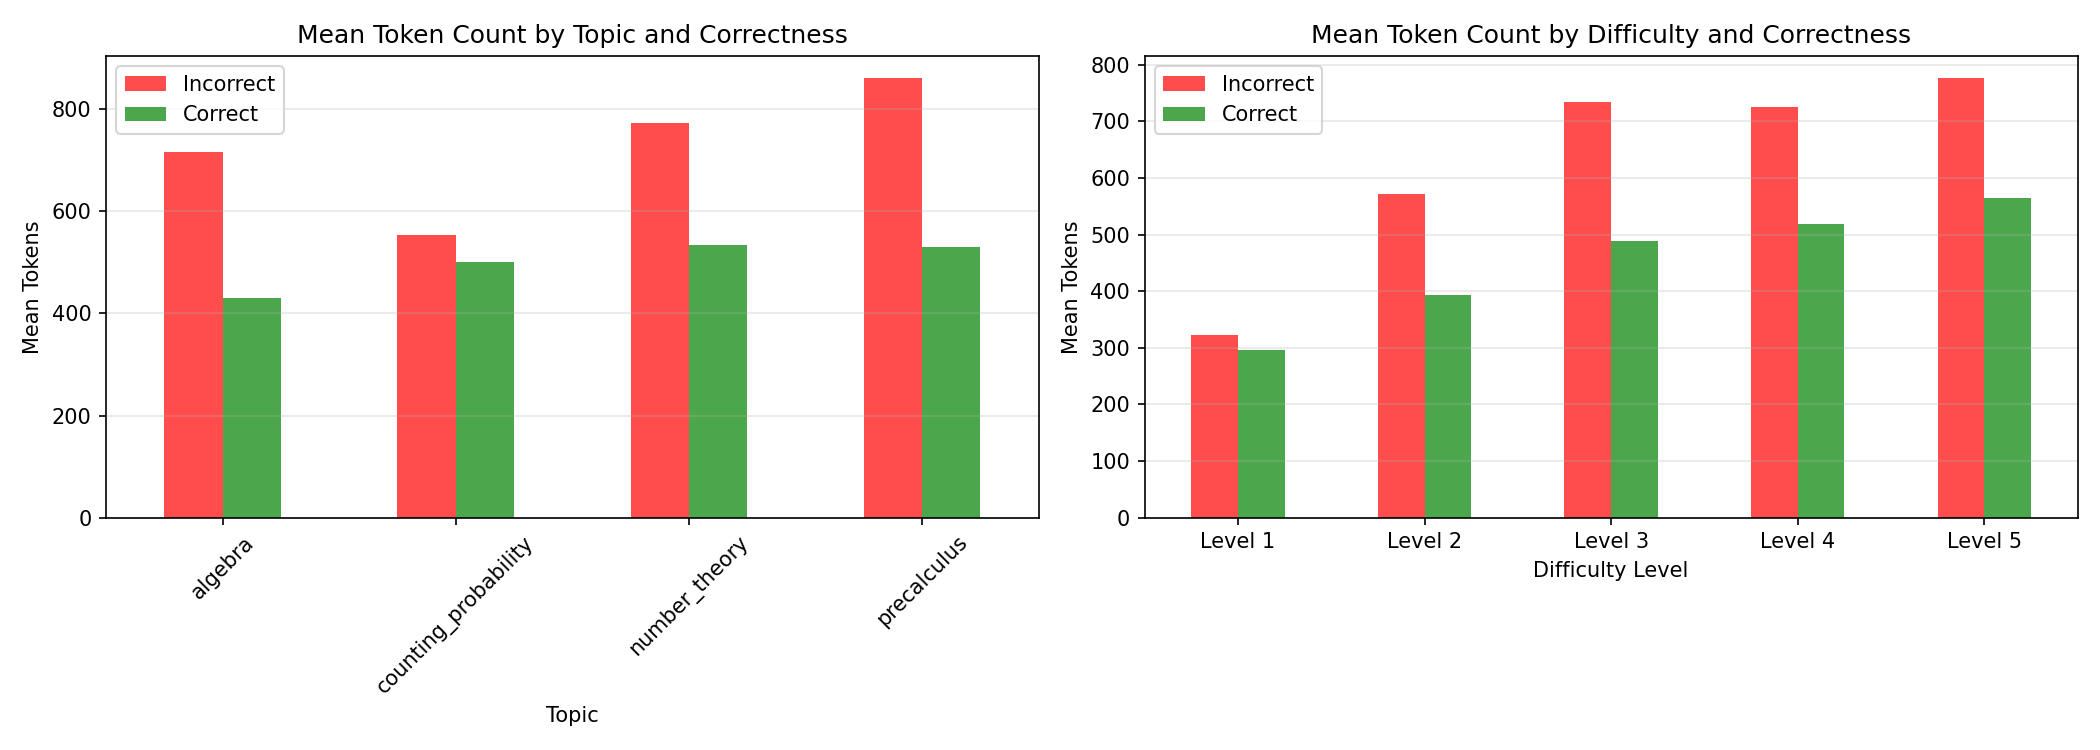

In [14]:
!cd probing-llm-math && git pull

# Analyze token counts
!python probing-llm-math/src/analyze_tokens.py \
    --audit_file probe_audit.csv \
    --output_dir token_analysis

# View the plots
from IPython.display import Image, display
import os
for f in sorted(os.listdir("token_analysis")):
    if f.endswith('.png'):
        print(f"\n{f}:")
        display(Image(f"token_analysis/{f}"))

Already up to date.
Loading data from probe_data_1.5b_500_fixed.pt...
Loaded 500 samples
Checkpoints: ['0pct', '50pct', '100pct']
Target layer for analysis: 15

PART 1: TRAINING PROBES AND EXTRACTING CONFIDENCE
  0pct: Accuracy=0.944, ECE=0.228
  50pct: Accuracy=0.926, ECE=0.290
  100pct: Accuracy=0.954, ECE=0.174

PART 2: CALIBRATION CURVES (RELIABILITY DIAGRAMS)
Saved: confidence_analysis/calibration_curves.png

PART 3: CONFIDENCE TRAJECTORIES (0% → 50% → 100%)
Saved: confidence_analysis/confidence_trajectories.png

Confidence change (100pct - 0pct):
  Correct samples: mean=+0.002
  Incorrect samples: mean=-0.027

PART 4: RECOVERY AND DEGRADATION PATTERNS

Prediction Trajectory Categories:
  Stable Correct: 243 (48.6%)
  Stable Incorrect: 221 (44.2%)
  Other: 15 (3.0%)
  Degradation: 7 (1.4%)
  Recovery: 6 (1.2%)
  False Degradation: 5 (1.0%)
  False Recovery: 3 (0.6%)
Saved: confidence_analysis/trajectory_categories.png

PART 5: DOES CONFIDENCE CHANGE PREDICT SUCCESS?

Correlation (

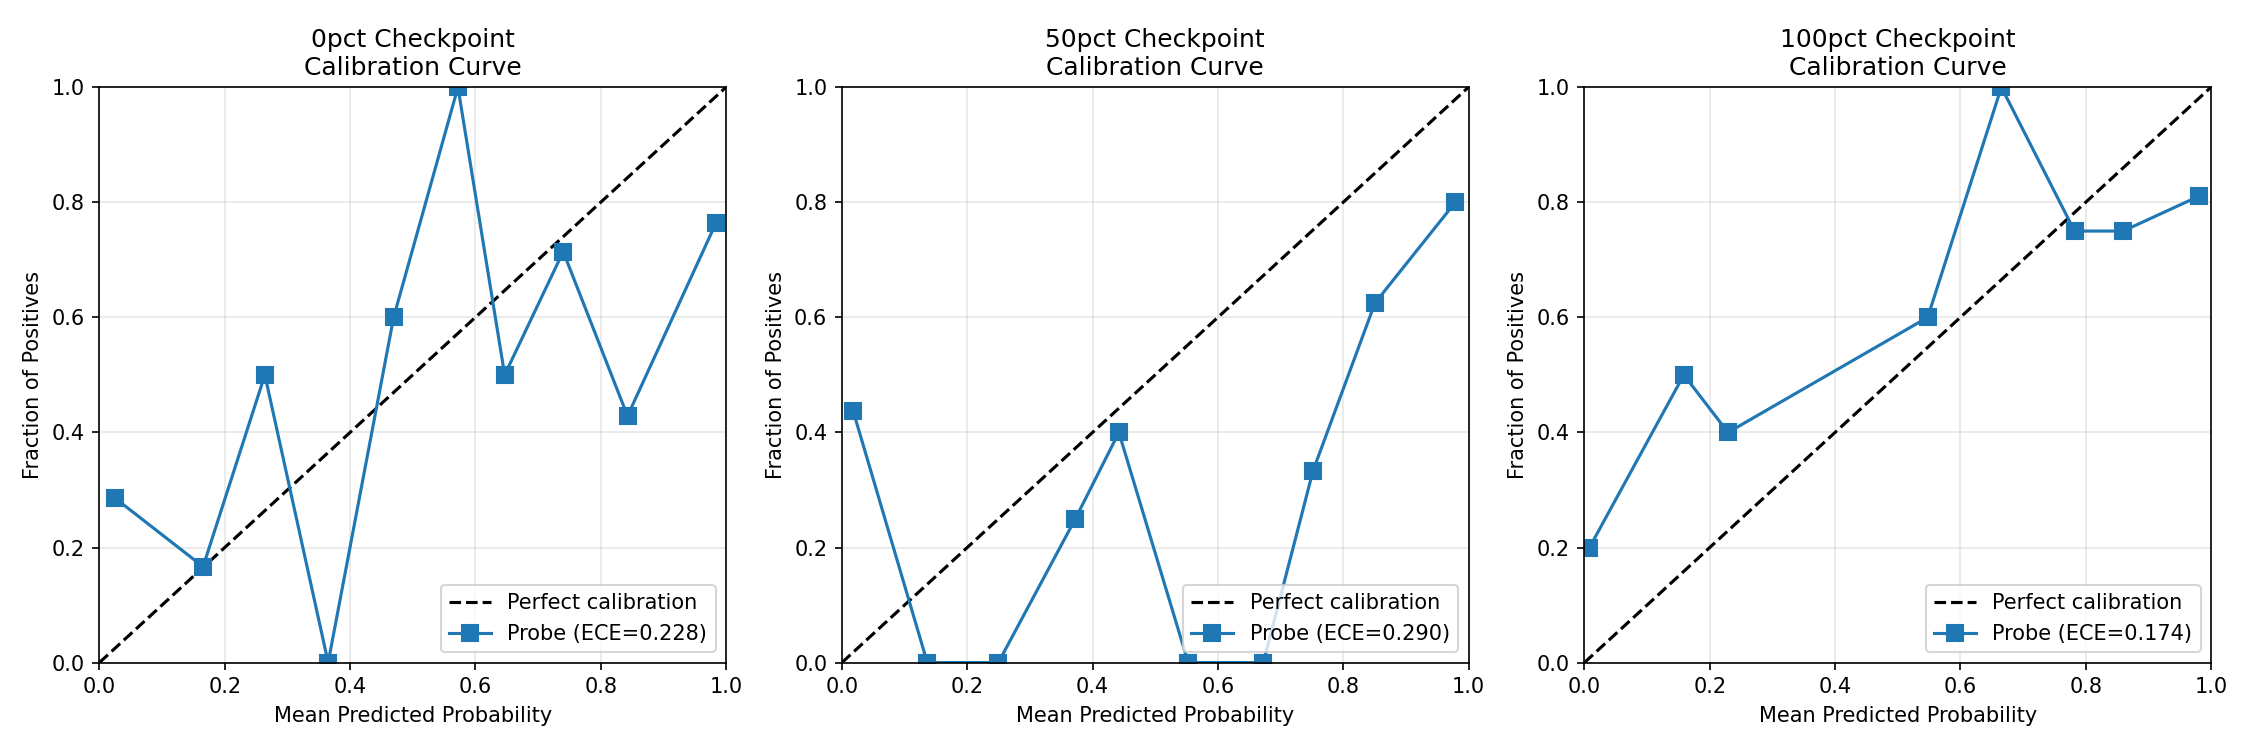


confidence_change_prediction.png:


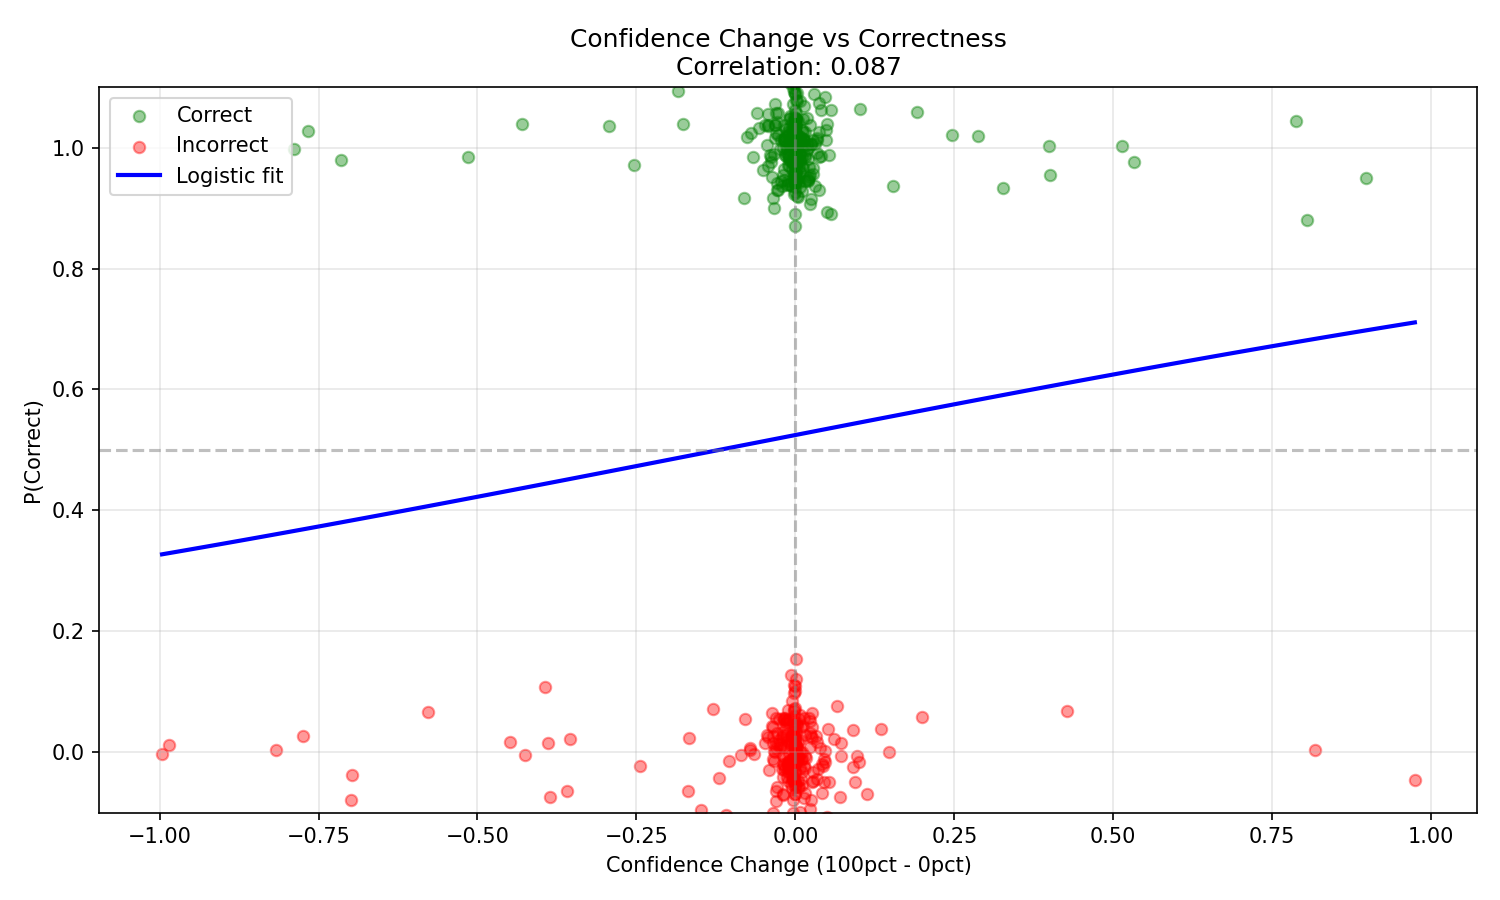


confidence_trajectories.png:


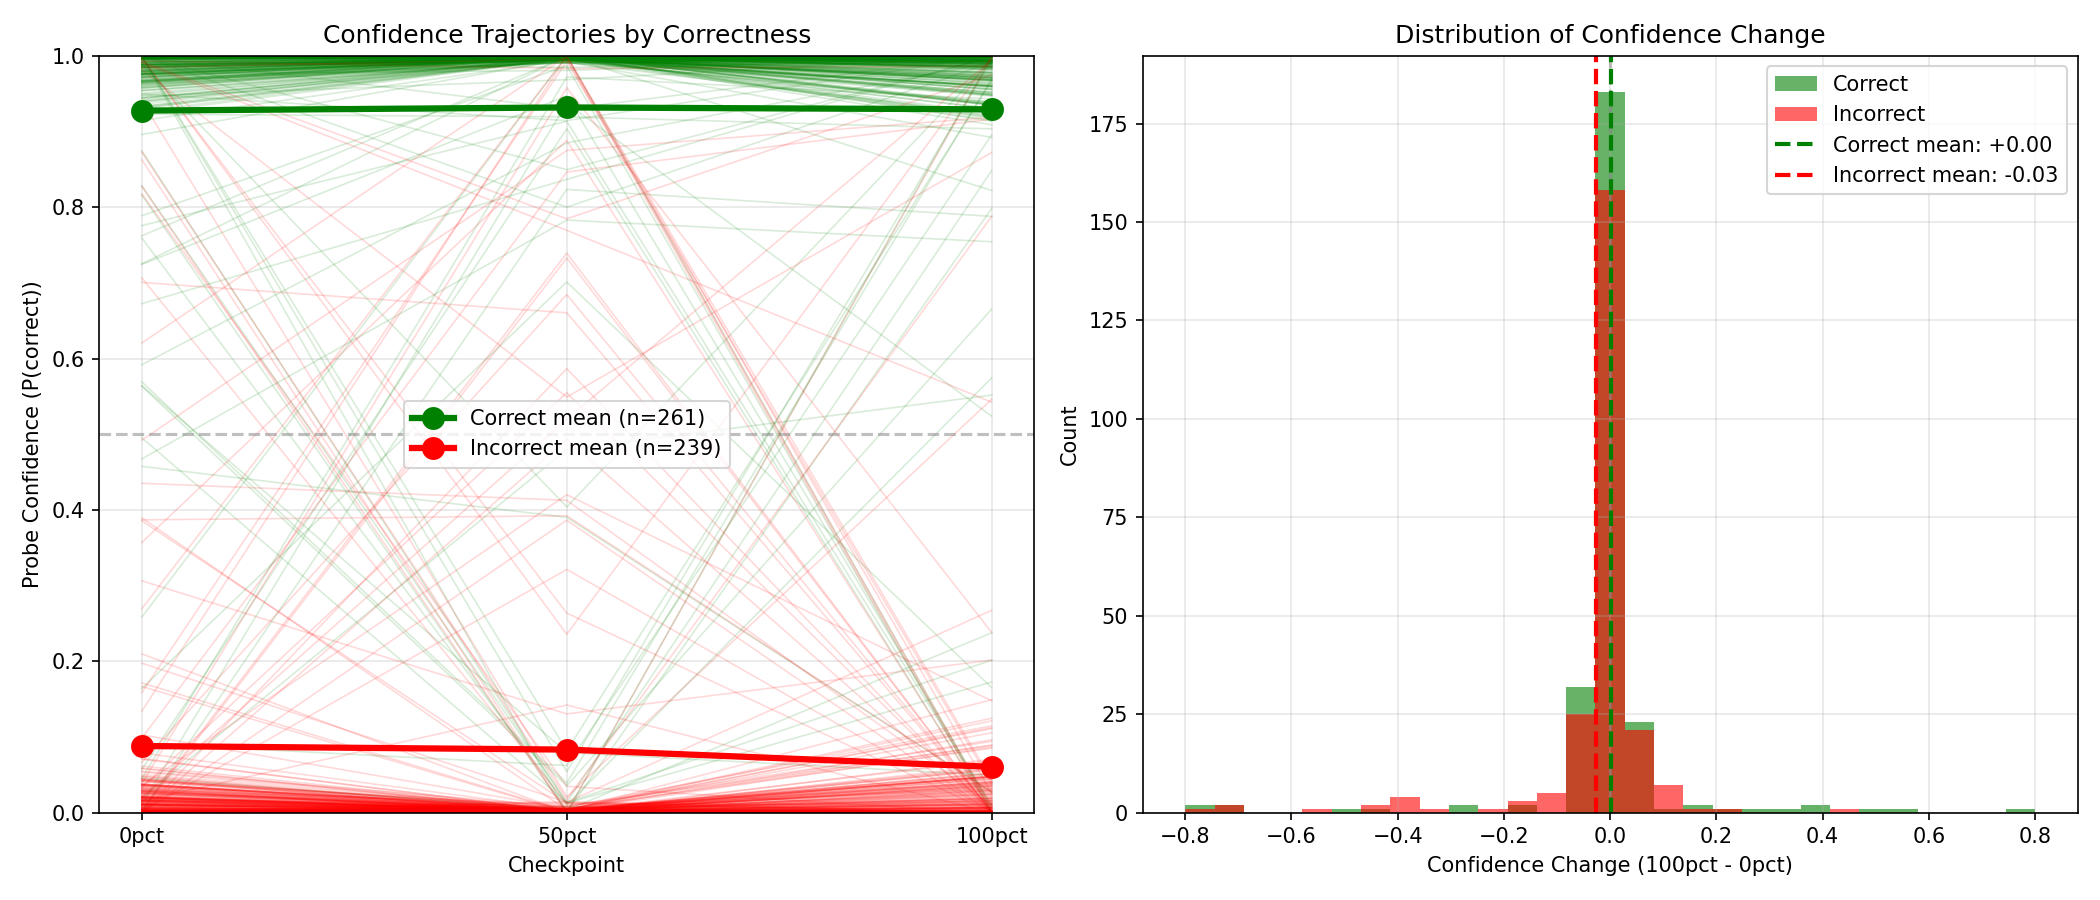


layer_calibration.png:


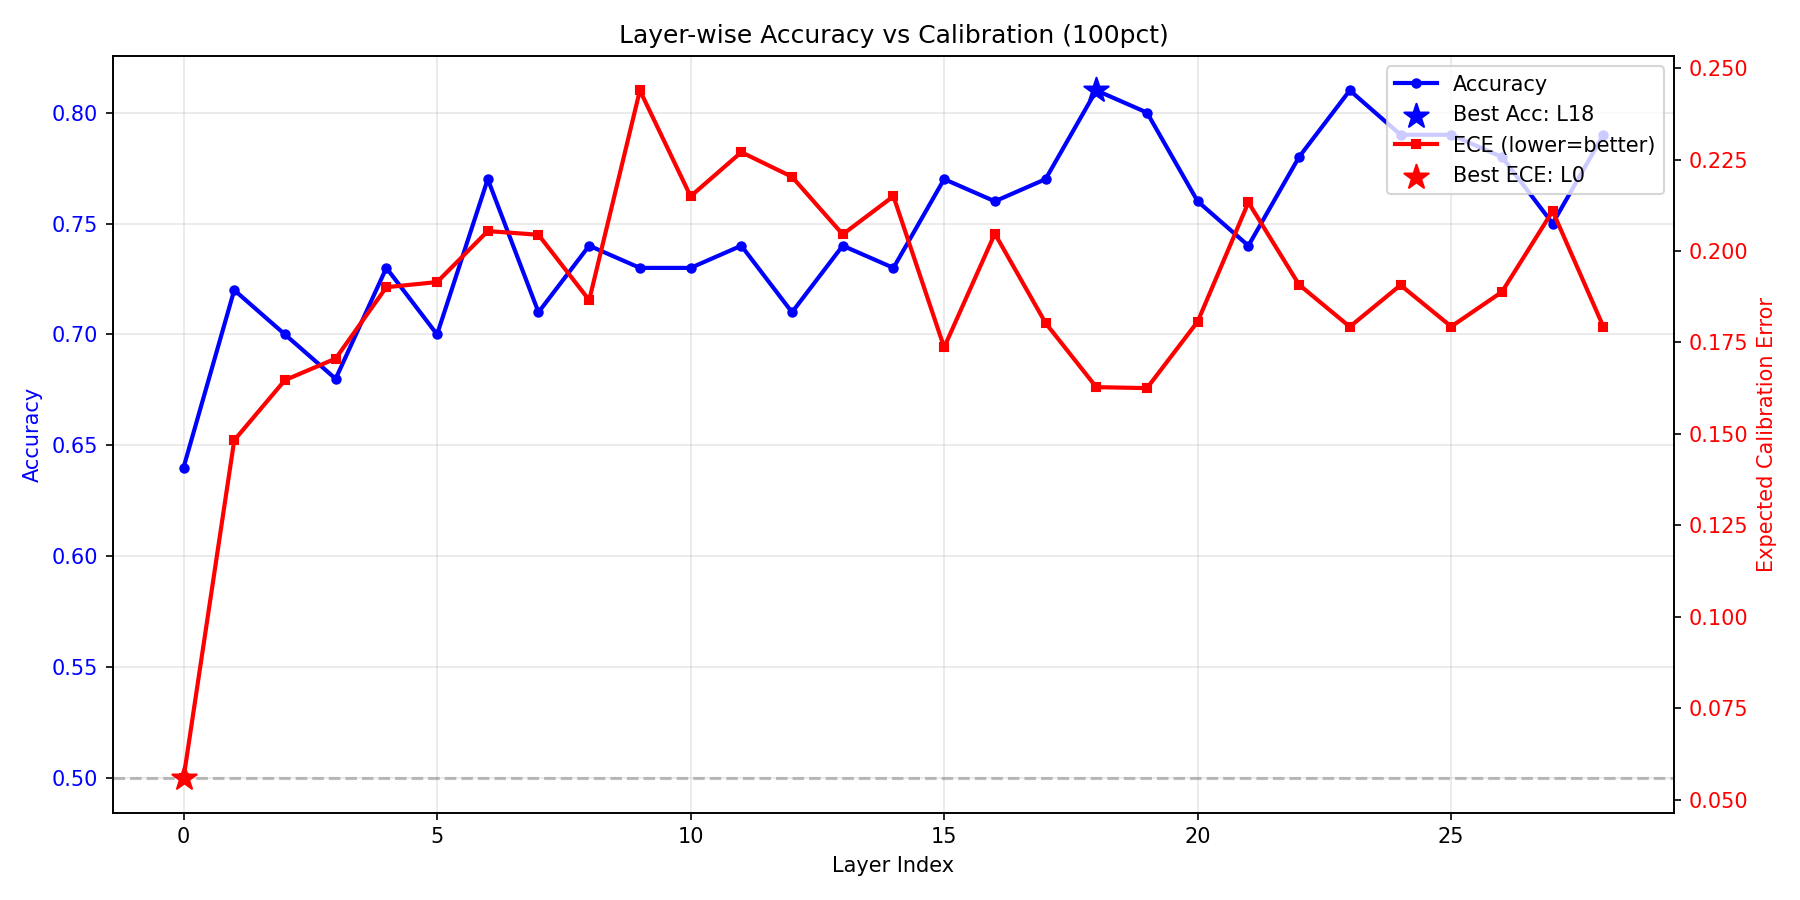


trajectory_categories.png:


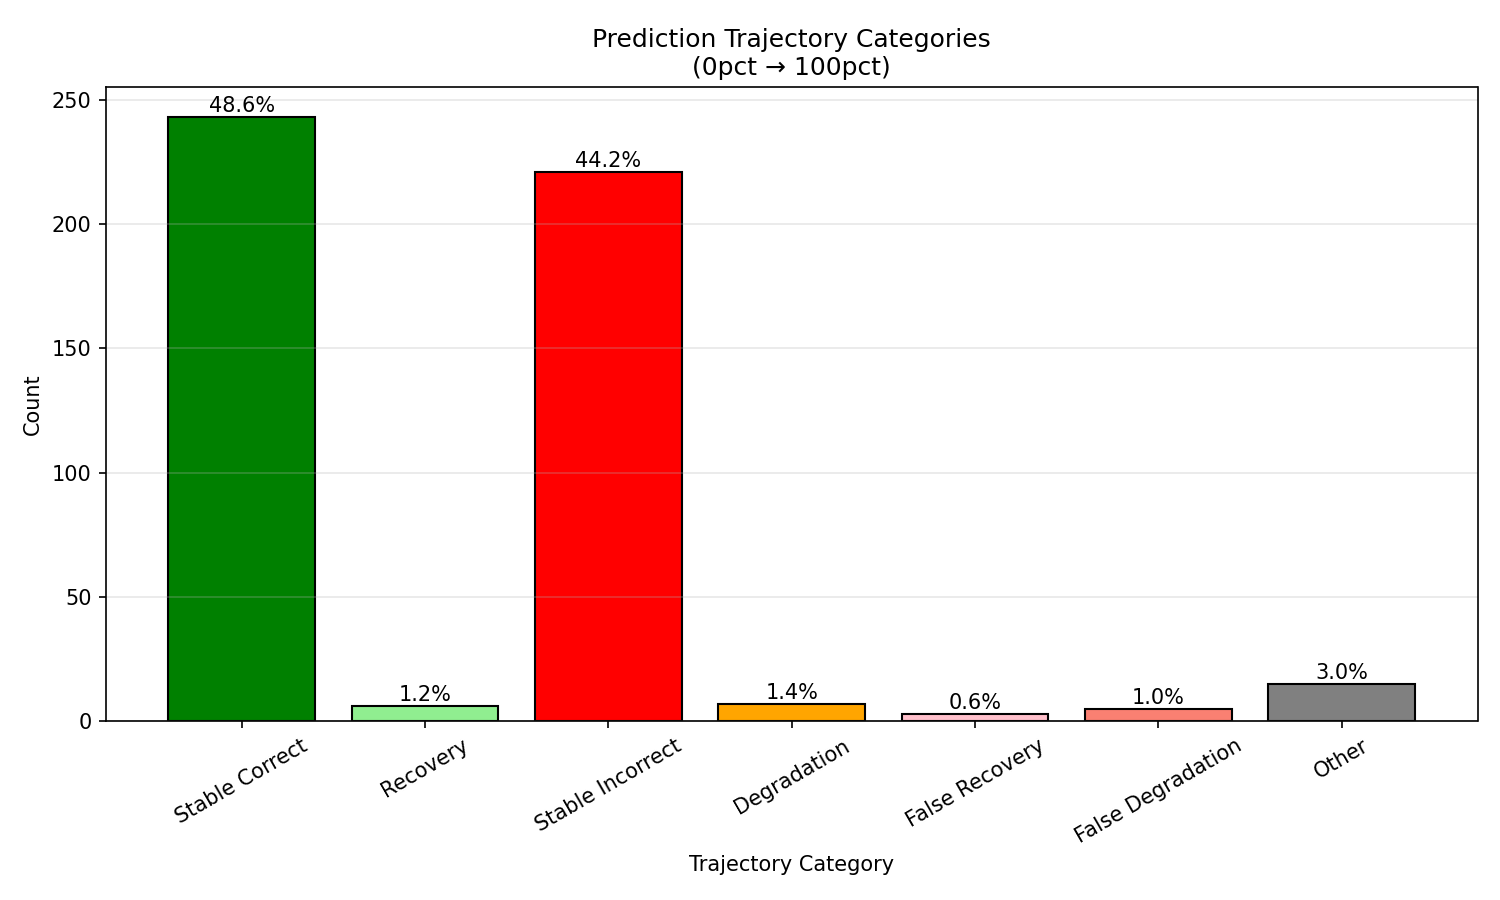

In [15]:
!cd probing-llm-math && git pull

# Run confidence analysis
!python probing-llm-math/src/confidence_analysis.py \
    --data_file probe_data_1.5b_500_fixed.pt \
    --output_dir confidence_analysis \
    --layer 15

# View results
from IPython.display import Image, display
import os
for f in sorted(os.listdir("confidence_analysis")):
    if f.endswith('.png'):
        print(f"\n{f}:")
        display(Image(f"confidence_analysis/{f}"))

In [9]:
!cd probing-llm-math && git pull



!python probing-llm-math/src/train_probe.py \
    --data_file probe_data_1.5b_500_fixed.pt \
    --output_dir probe_results_mlp \
    --mlp

Already up to date.
Loading data from probe_data_1.5b_500_fixed.pt...
Traceback (most recent call last):
  File "/content/probing-llm-math/src/train_probe.py", line 1046, in <module>
    train_all_probes(
  File "/content/probing-llm-math/src/train_probe.py", line 935, in train_all_probes
    data, num_layers, hidden_dim, has_50pct, has_mean_pooling = load_data(data_file)
                                                                ^^^^^^^^^^^^^^^^^^^^
  File "/content/probing-llm-math/src/train_probe.py", line 36, in load_data
    loaded = torch.load(data_file)
             ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/serialization.py", line 1484, in load
    with _open_file_like(f, "rb") as opened_file:
         ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/serialization.py", line 759, in _open_file_like
    return _open_file(name_or_buffer, mode)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/pyth

In [10]:
# ============================================================
# CELL 1: SETUP - Mount Drive, Pull Code, Fix Labels
# ============================================================
import os
import sys
import torch

# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Clone/update repo
REPO_NAME = "probing-llm-math"
if not os.path.exists(REPO_NAME):
    !git clone -b colab-pipeline-setup https://github.com/1hamzaiqbal/probing-llm-math.git
else:
    !cd {REPO_NAME} && git fetch origin && git reset --hard origin/colab-pipeline-setup

# 3. Install dependencies
!pip install -q -r {REPO_NAME}/requirements.txt

# 4. Add to path
sys.path.insert(0, f'{REPO_NAME}/src')
from evaluator import is_equivalent, extract_answer

# 5. Load data from Drive and fix labels
DRIVE_DIR = "/content/drive/MyDrive"
data_file = f"{DRIVE_DIR}/probe_data_1.5b_1000.pt"  # Despite name, this is 500 samples

print(f"Loading from {data_file}...")
loaded = torch.load(data_file)
data = loaded['data']
metadata = loaded['metadata']

# 6. Re-evaluate with fixed evaluator
print("Re-evaluating with updated evaluator...")
updated = 0
for d in data:
    gt = str(d['ground_truth'])
    pred = extract_answer(str(d['prediction']))
    new_correct = is_equivalent(pred, gt)
    if new_correct != d['is_correct']:
        d['is_correct'] = new_correct
        updated += 1

correct = sum(1 for d in data if d['is_correct'])
print(f"Updated {updated} labels")
print(f"New balance: {correct} correct, {len(data) - correct} incorrect")

# 7. Save fixed version (both local and Drive)
fixed_file = "probe_data_1.5b_500_fixed.pt"
torch.save({'data': data, 'metadata': metadata}, fixed_file)
torch.save({'data': data, 'metadata': metadata}, f"{DRIVE_DIR}/{fixed_file}")
print(f"✓ Saved to {fixed_file} and Drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
HEAD is now at 6b1f514 Update PROGRESS.md with final results
Loading from /content/drive/MyDrive/probe_data_1.5b_1000.pt...
Re-evaluating with updated evaluator...
Updated 11 labels
New balance: 261 correct, 239 incorrect
✓ Saved to probe_data_1.5b_500_fixed.pt and Drive


Loading data from probe_data_1.5b_500_fixed.pt...
Loaded 500 samples (new format with metadata)
Metadata: {'num_samples': 500, 'num_layers': 29, 'hidden_dim': 1536, 'pooling_method': 'both', 'dataset': 'math', 'seed': 42, 'has_50pct': True, 'has_mean_pooling': True, 'has_last_token': True}
Num layers: 29, Hidden dim: 1536
Topics: ['number_theory', 'precalculus', 'counting_probability', 'algebra']
Levels: [1, 2, 3, 4, 5]
Has 50% checkpoints: True
Has mean pooling: True

TRAINING SUCCESS PROBES
Class balance: 261 correct, 239 incorrect

--- 0pct checkpoint ---
/content/probing-llm-math/src/train_probe.py:98: RuntimeWarning: invalid value encountered in divide
  w = w / w_norm  # Normalize
  Layer 0: LogReg=0.480, DiffMeans=0.480
  Layer 5: LogReg=0.620, DiffMeans=0.650
  Layer 10: LogReg=0.600, DiffMeans=0.650
  Layer 15: LogReg=0.720, DiffMeans=0.690
  Layer 20: LogReg=0.680, DiffMeans=0.700
  Layer 25: LogReg=0.650, DiffMeans=0.690
  LogReg Best: Layer 17 = 0.730
  DiffMeans Best: Laye

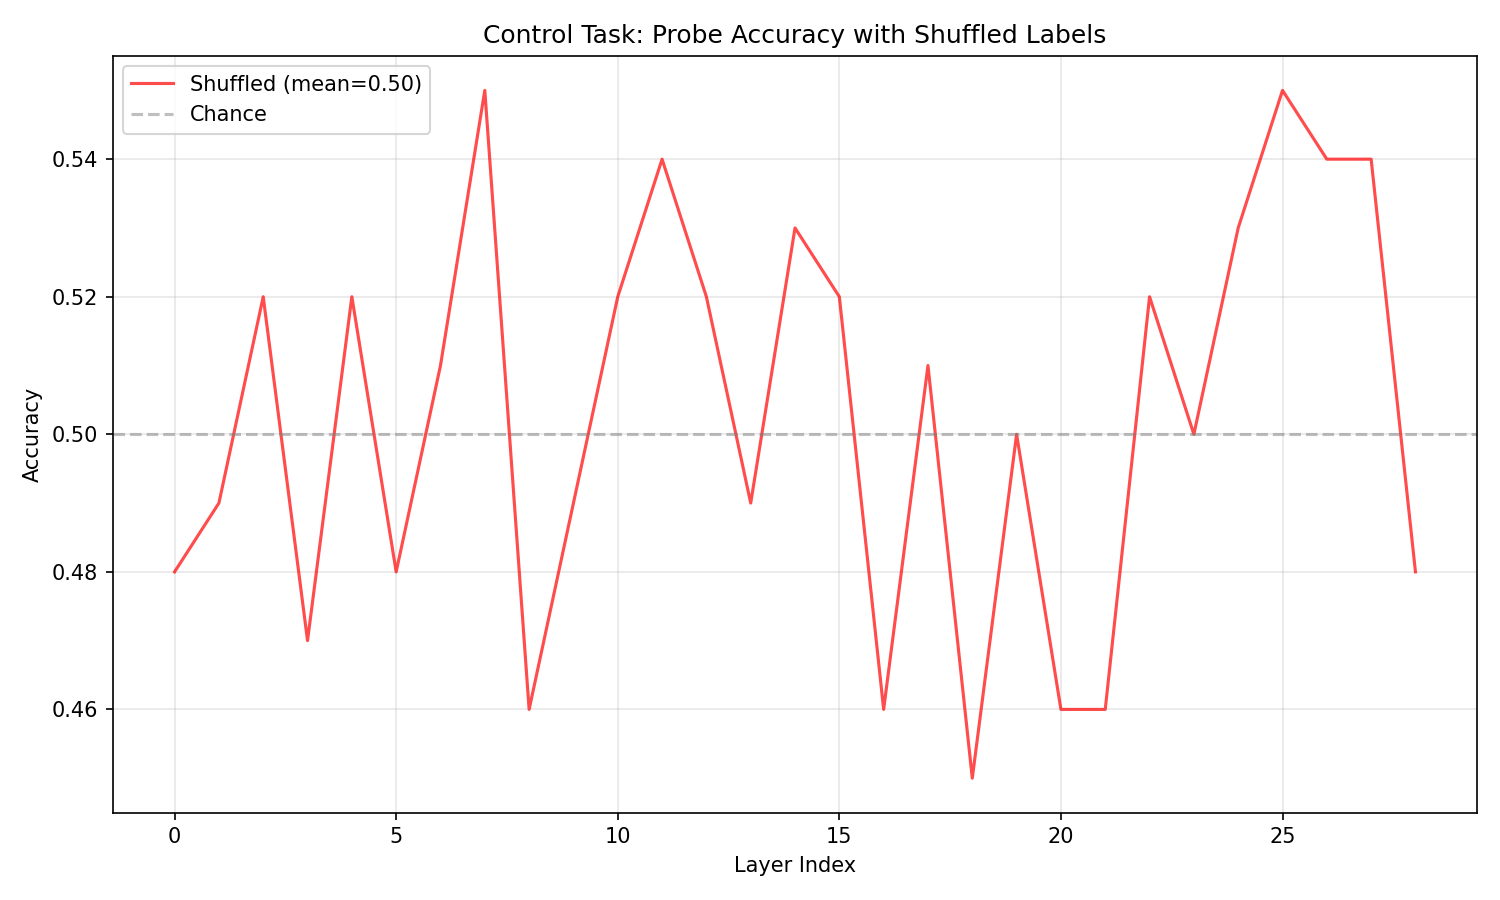


difficulty_probe_classification.png:


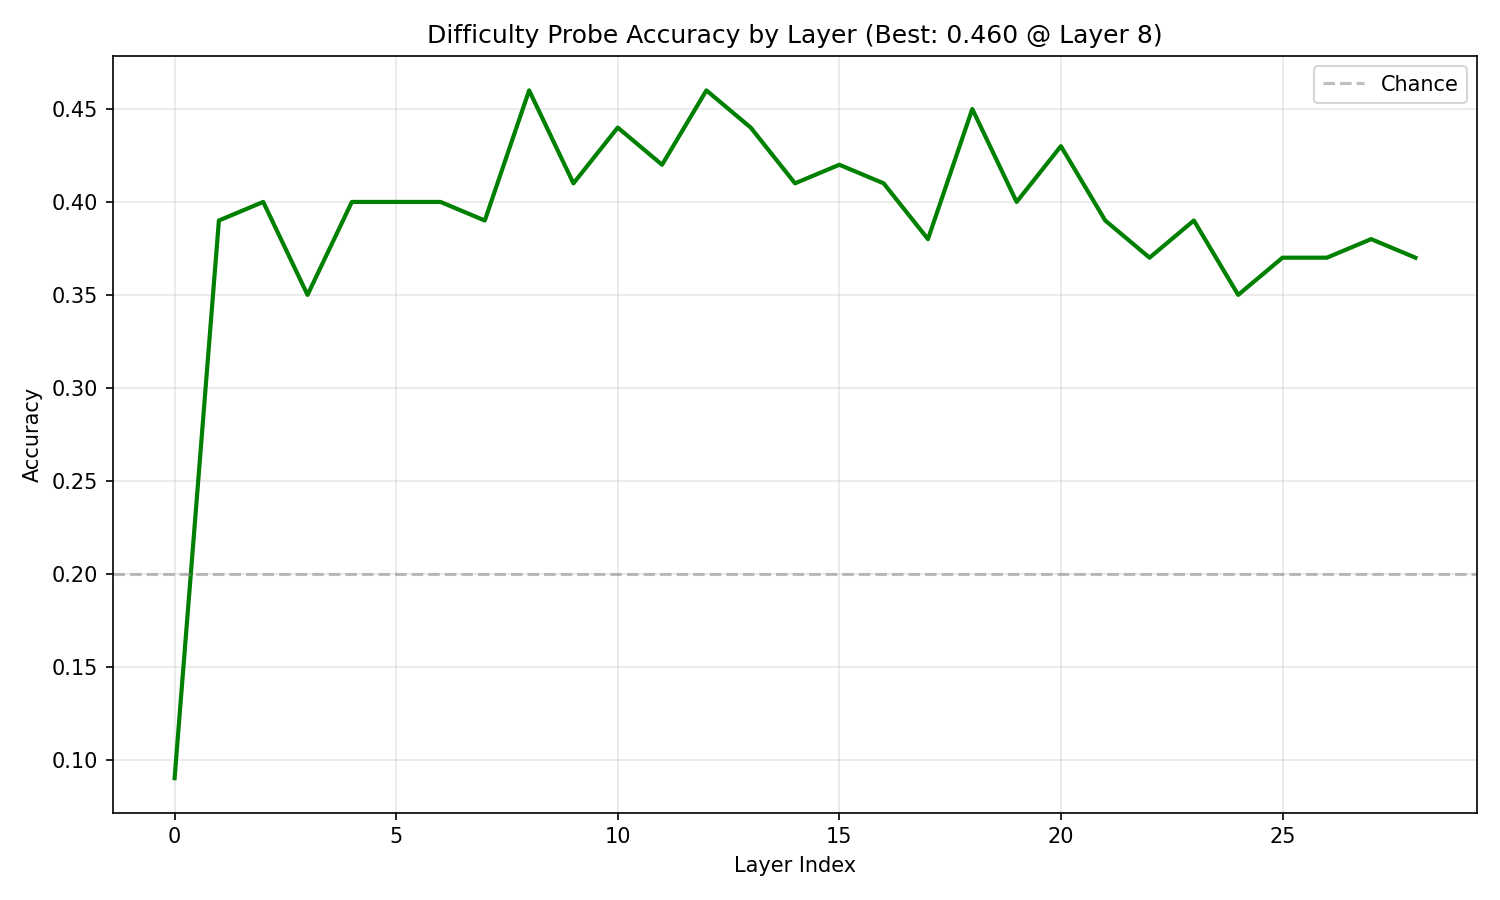


difficulty_probe_regression.png:


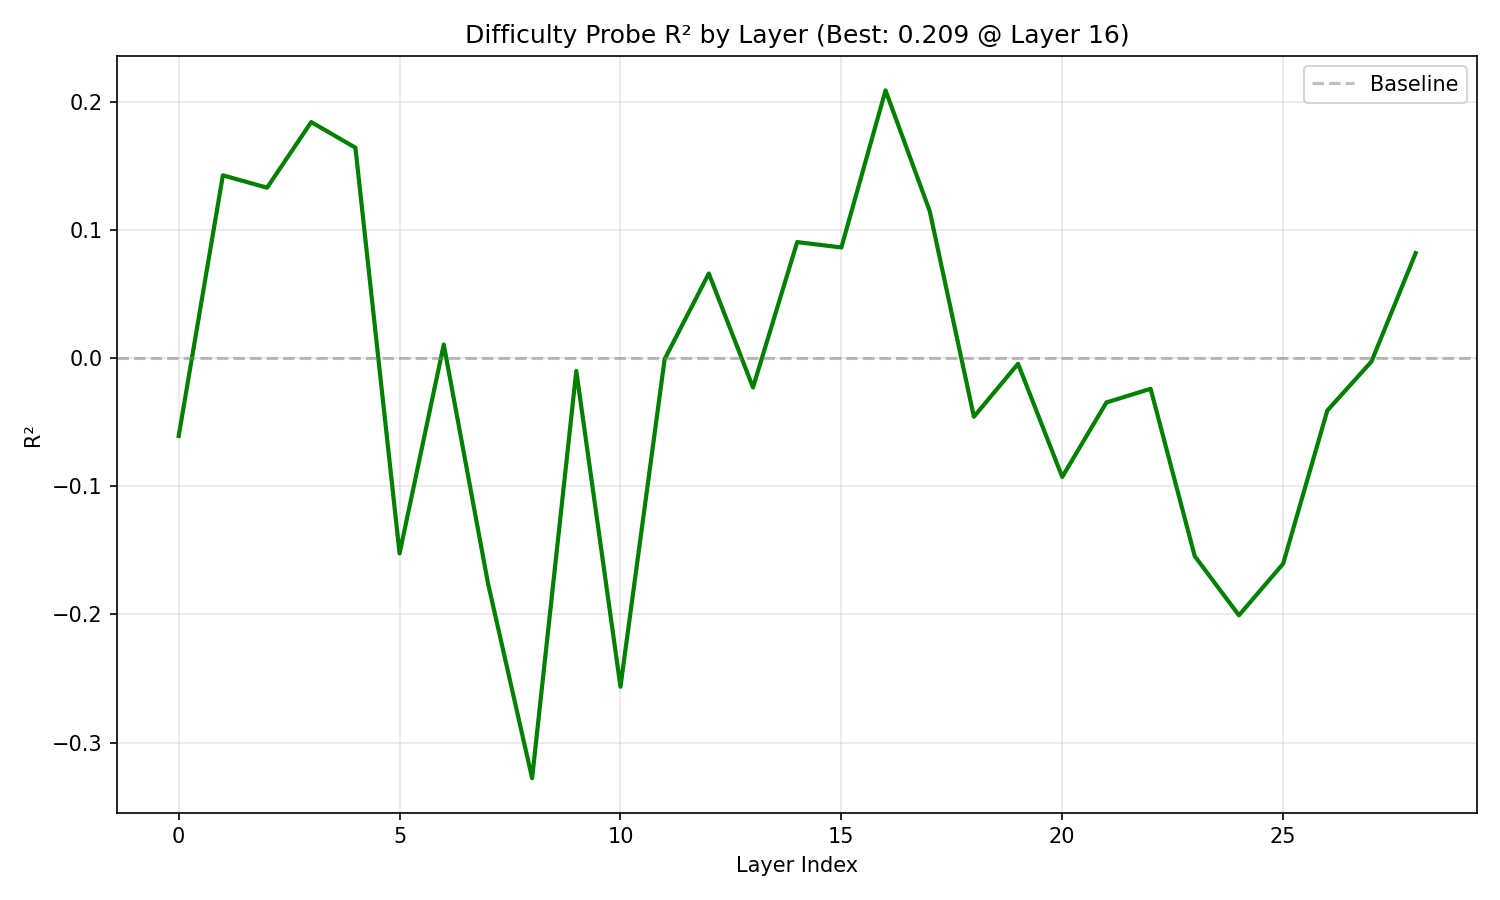


mlp_vs_linear.png:


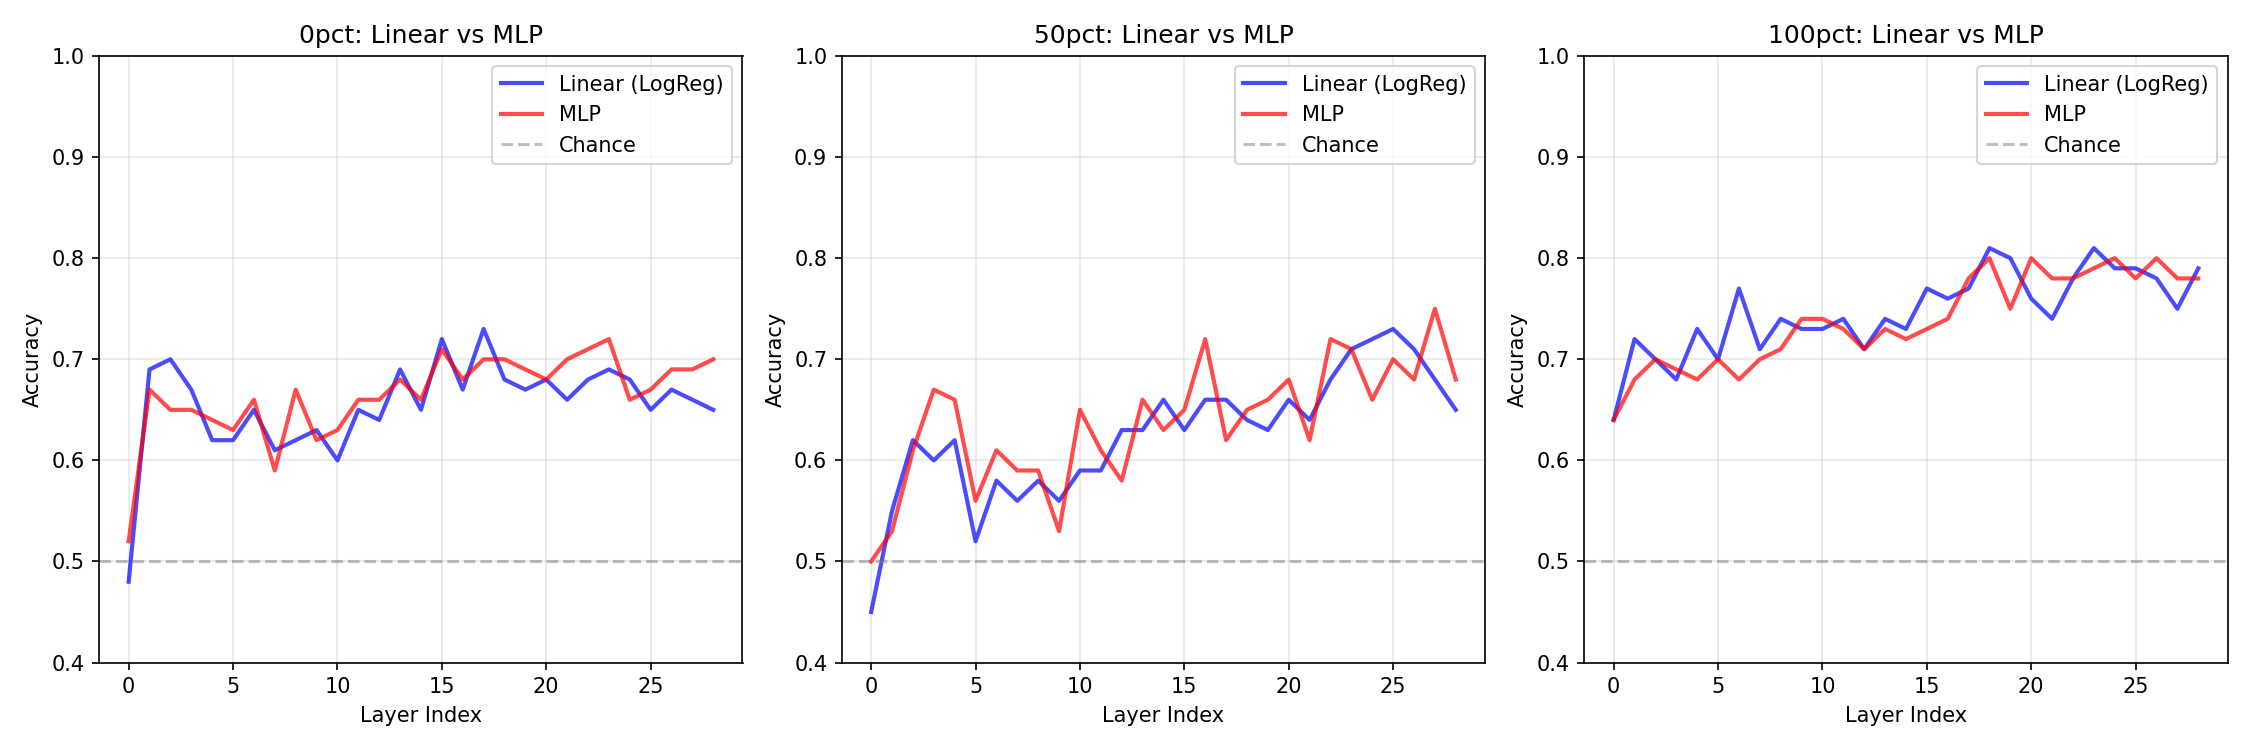


pca_layer20_correctness.png:


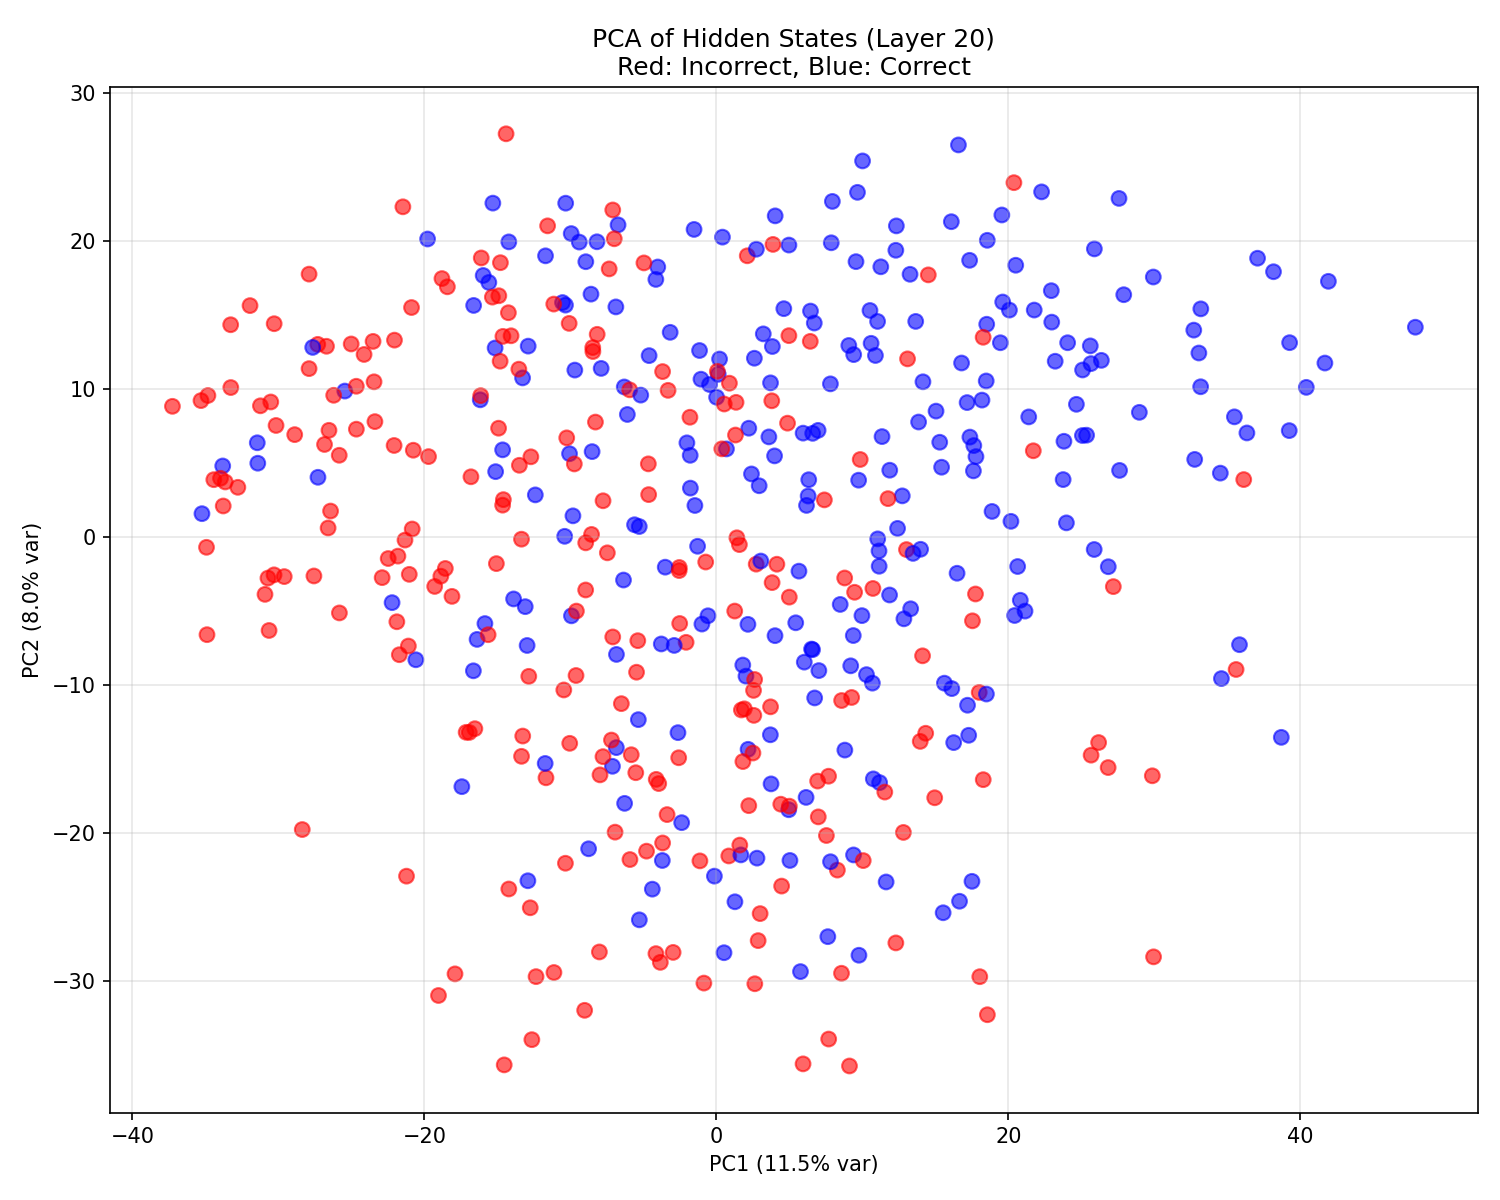


pca_layer20_difficulty.png:


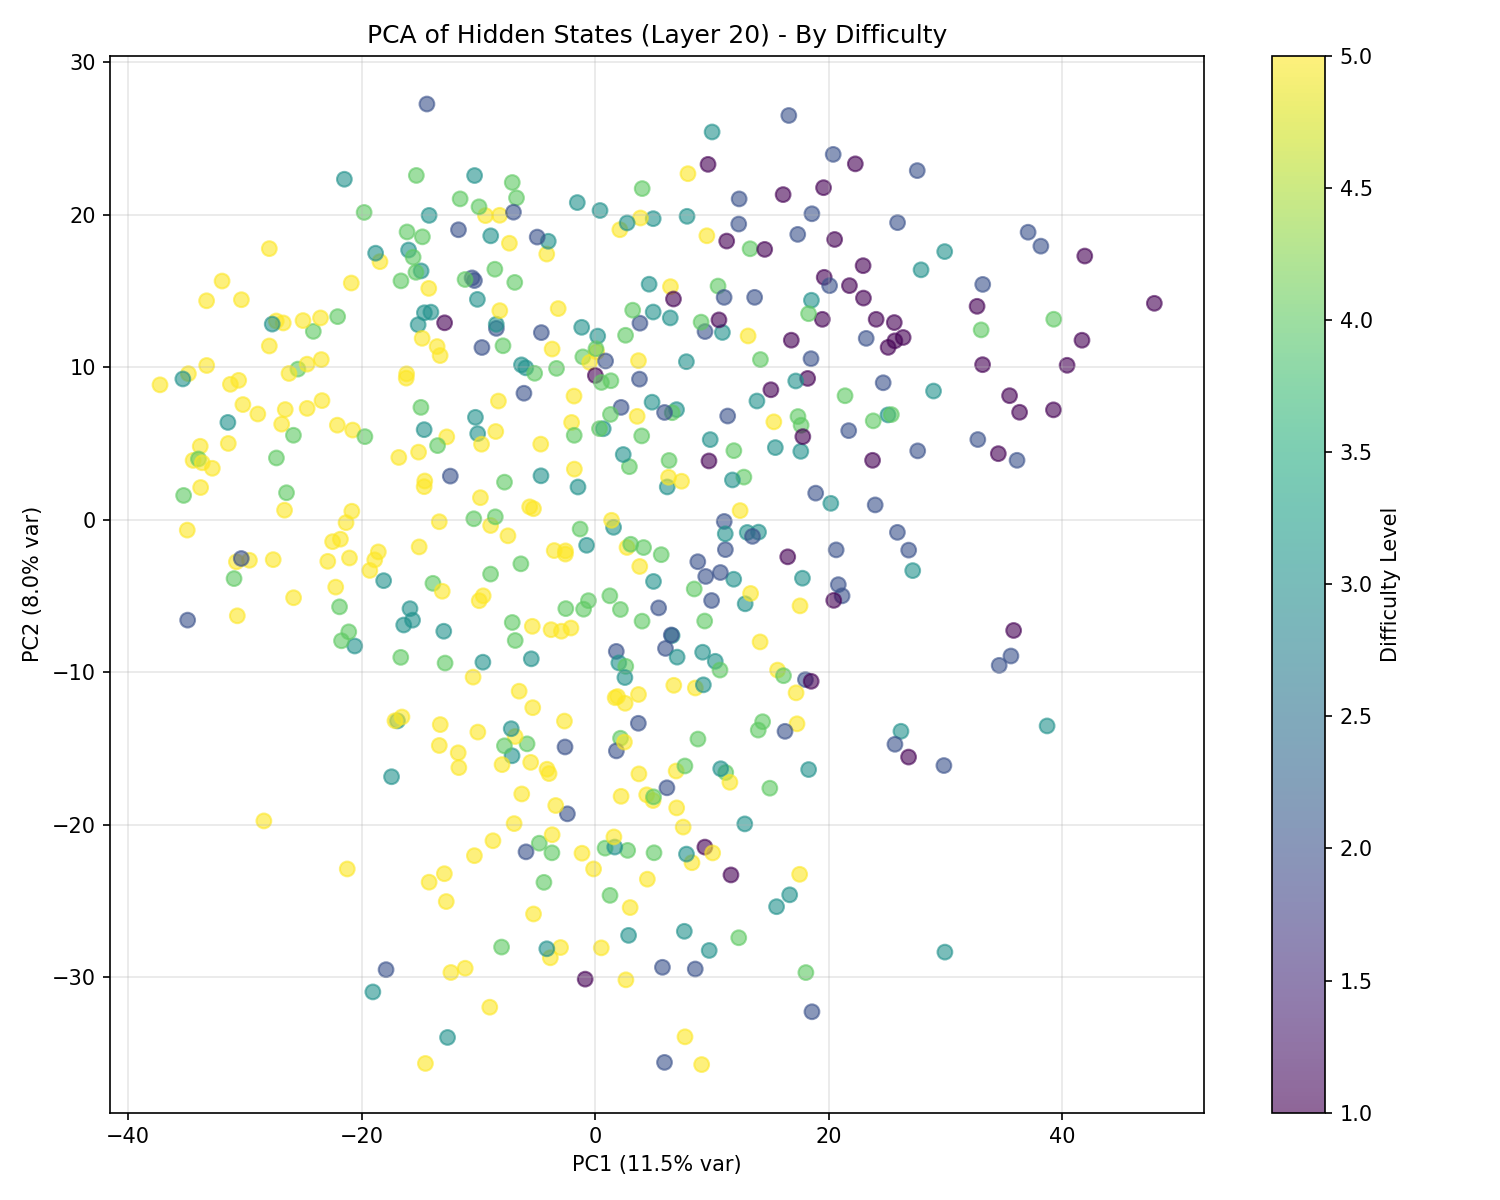


pca_layer20_topic.png:


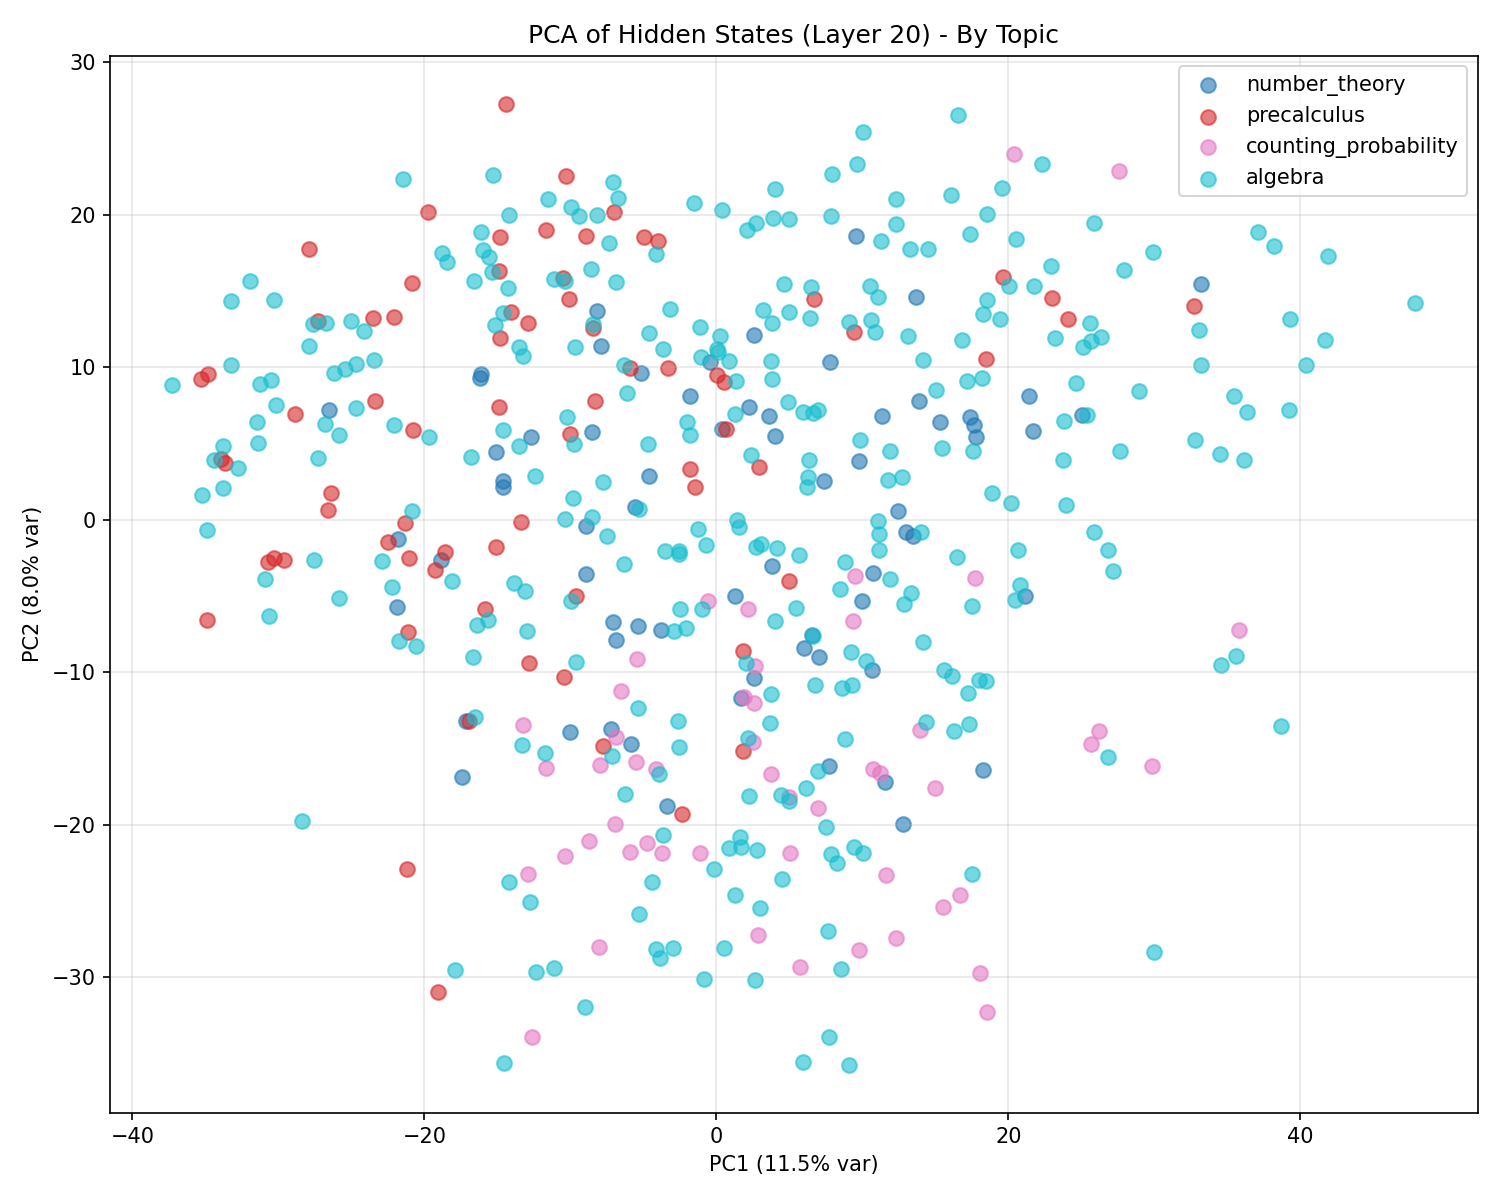


pooling_comparison.png:


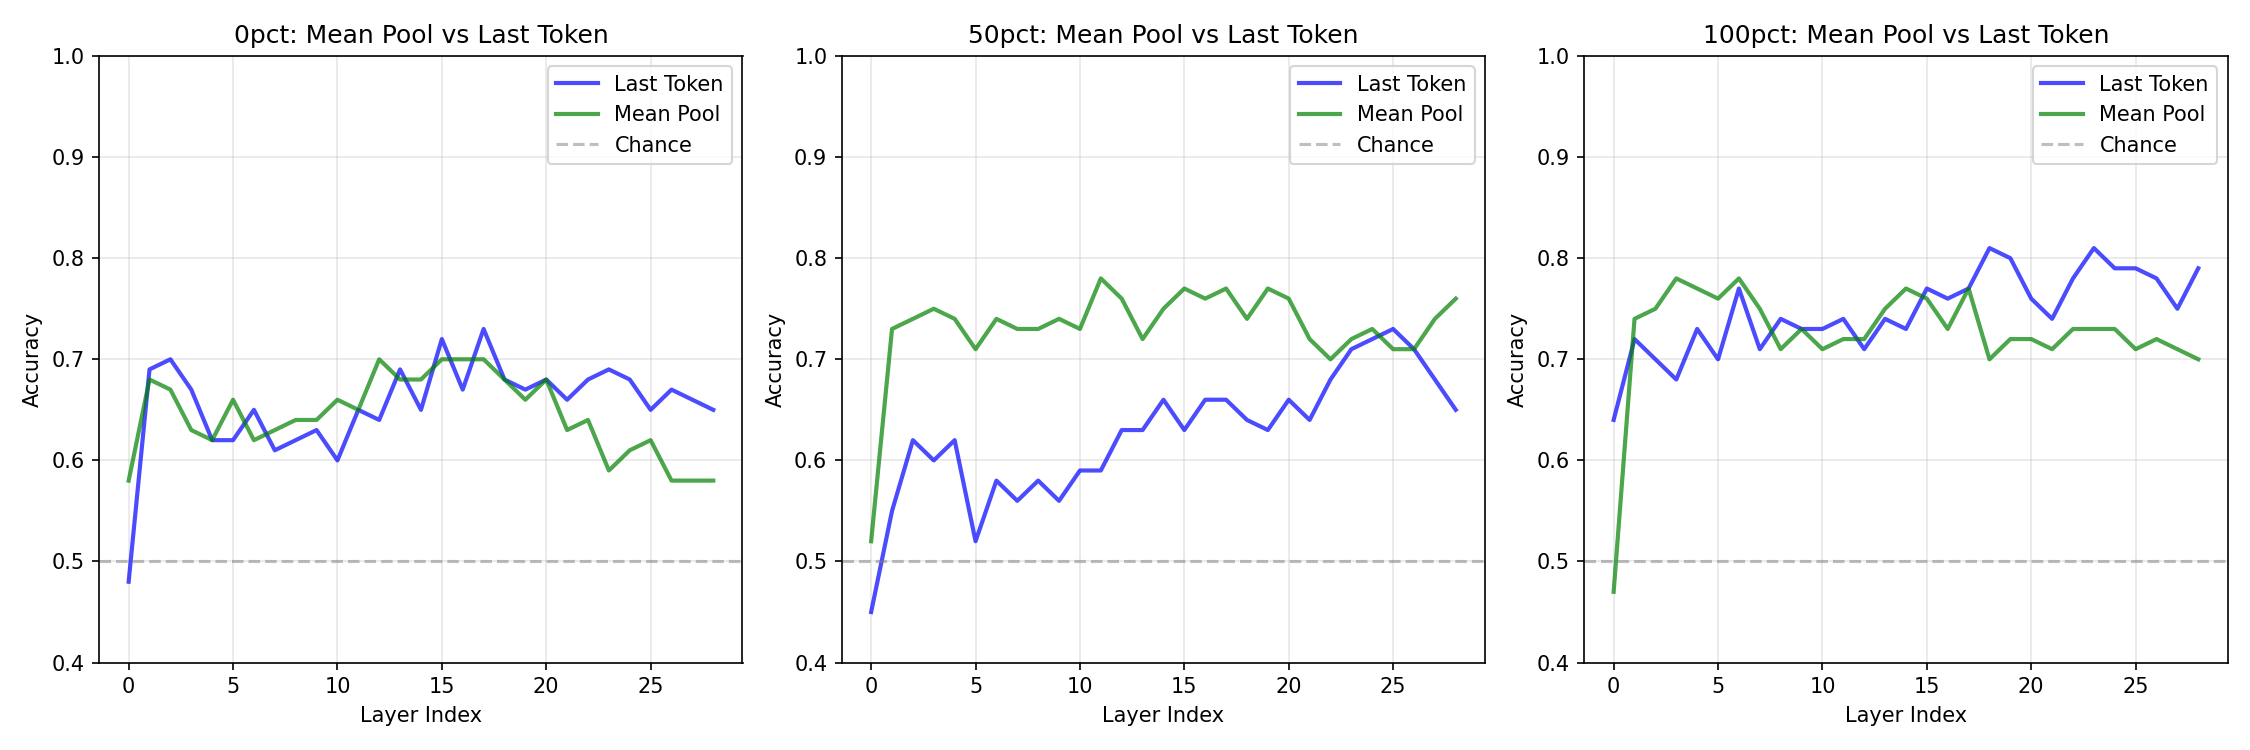


success_probe_accuracy.png:


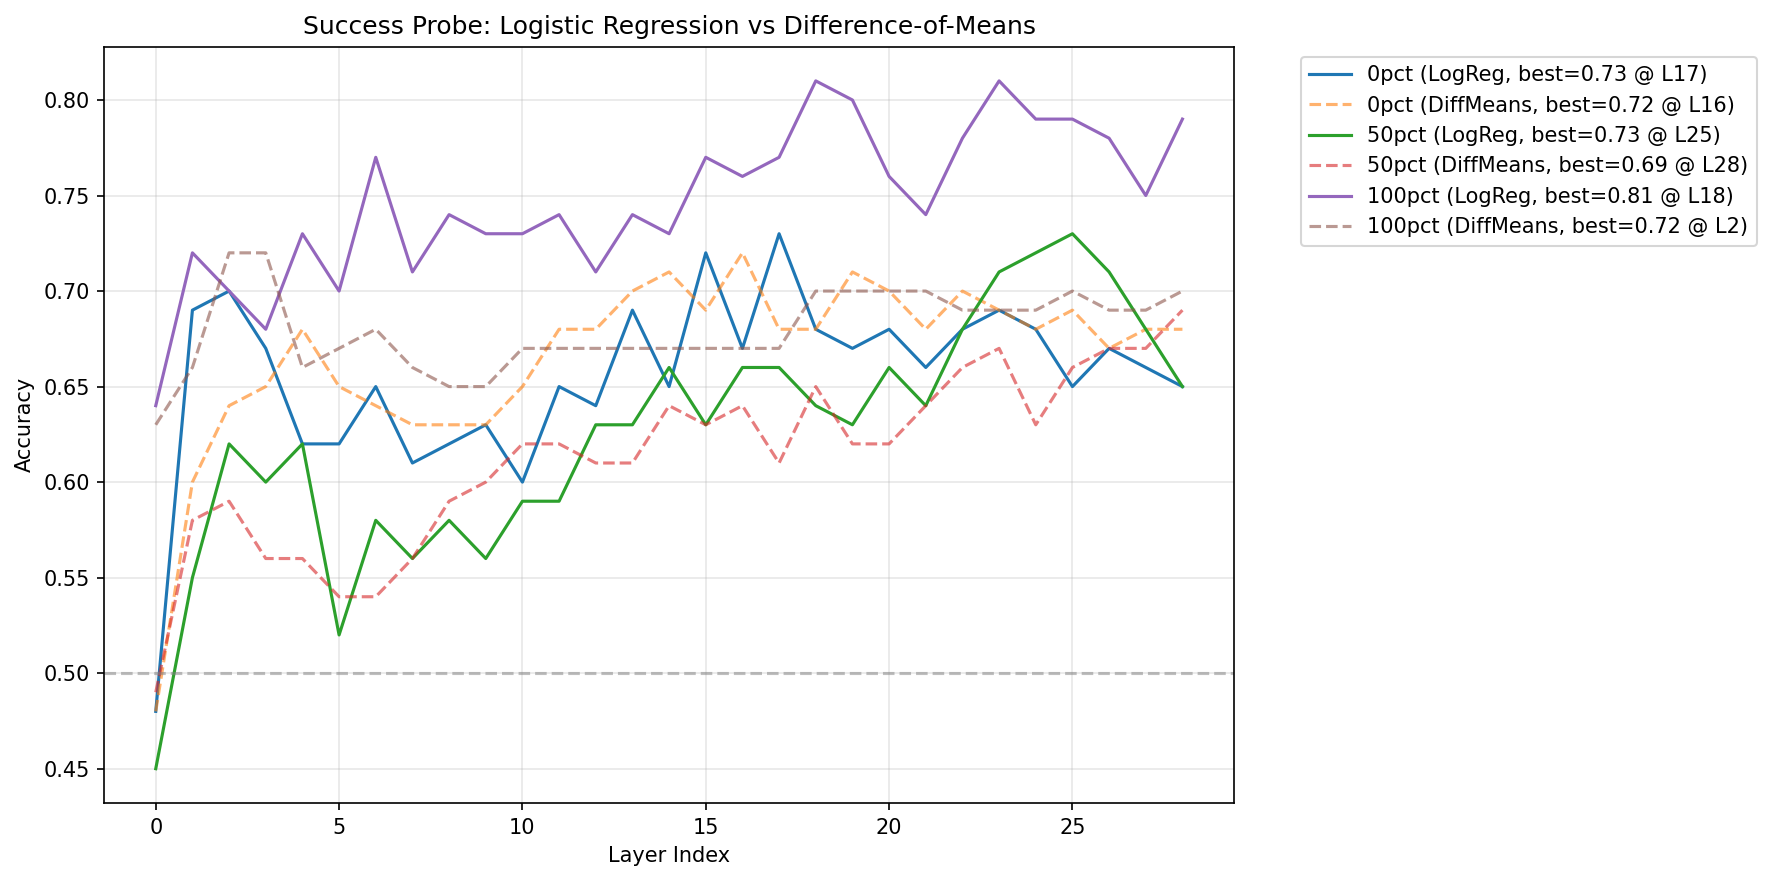


success_probe_heatmap_2d.png:


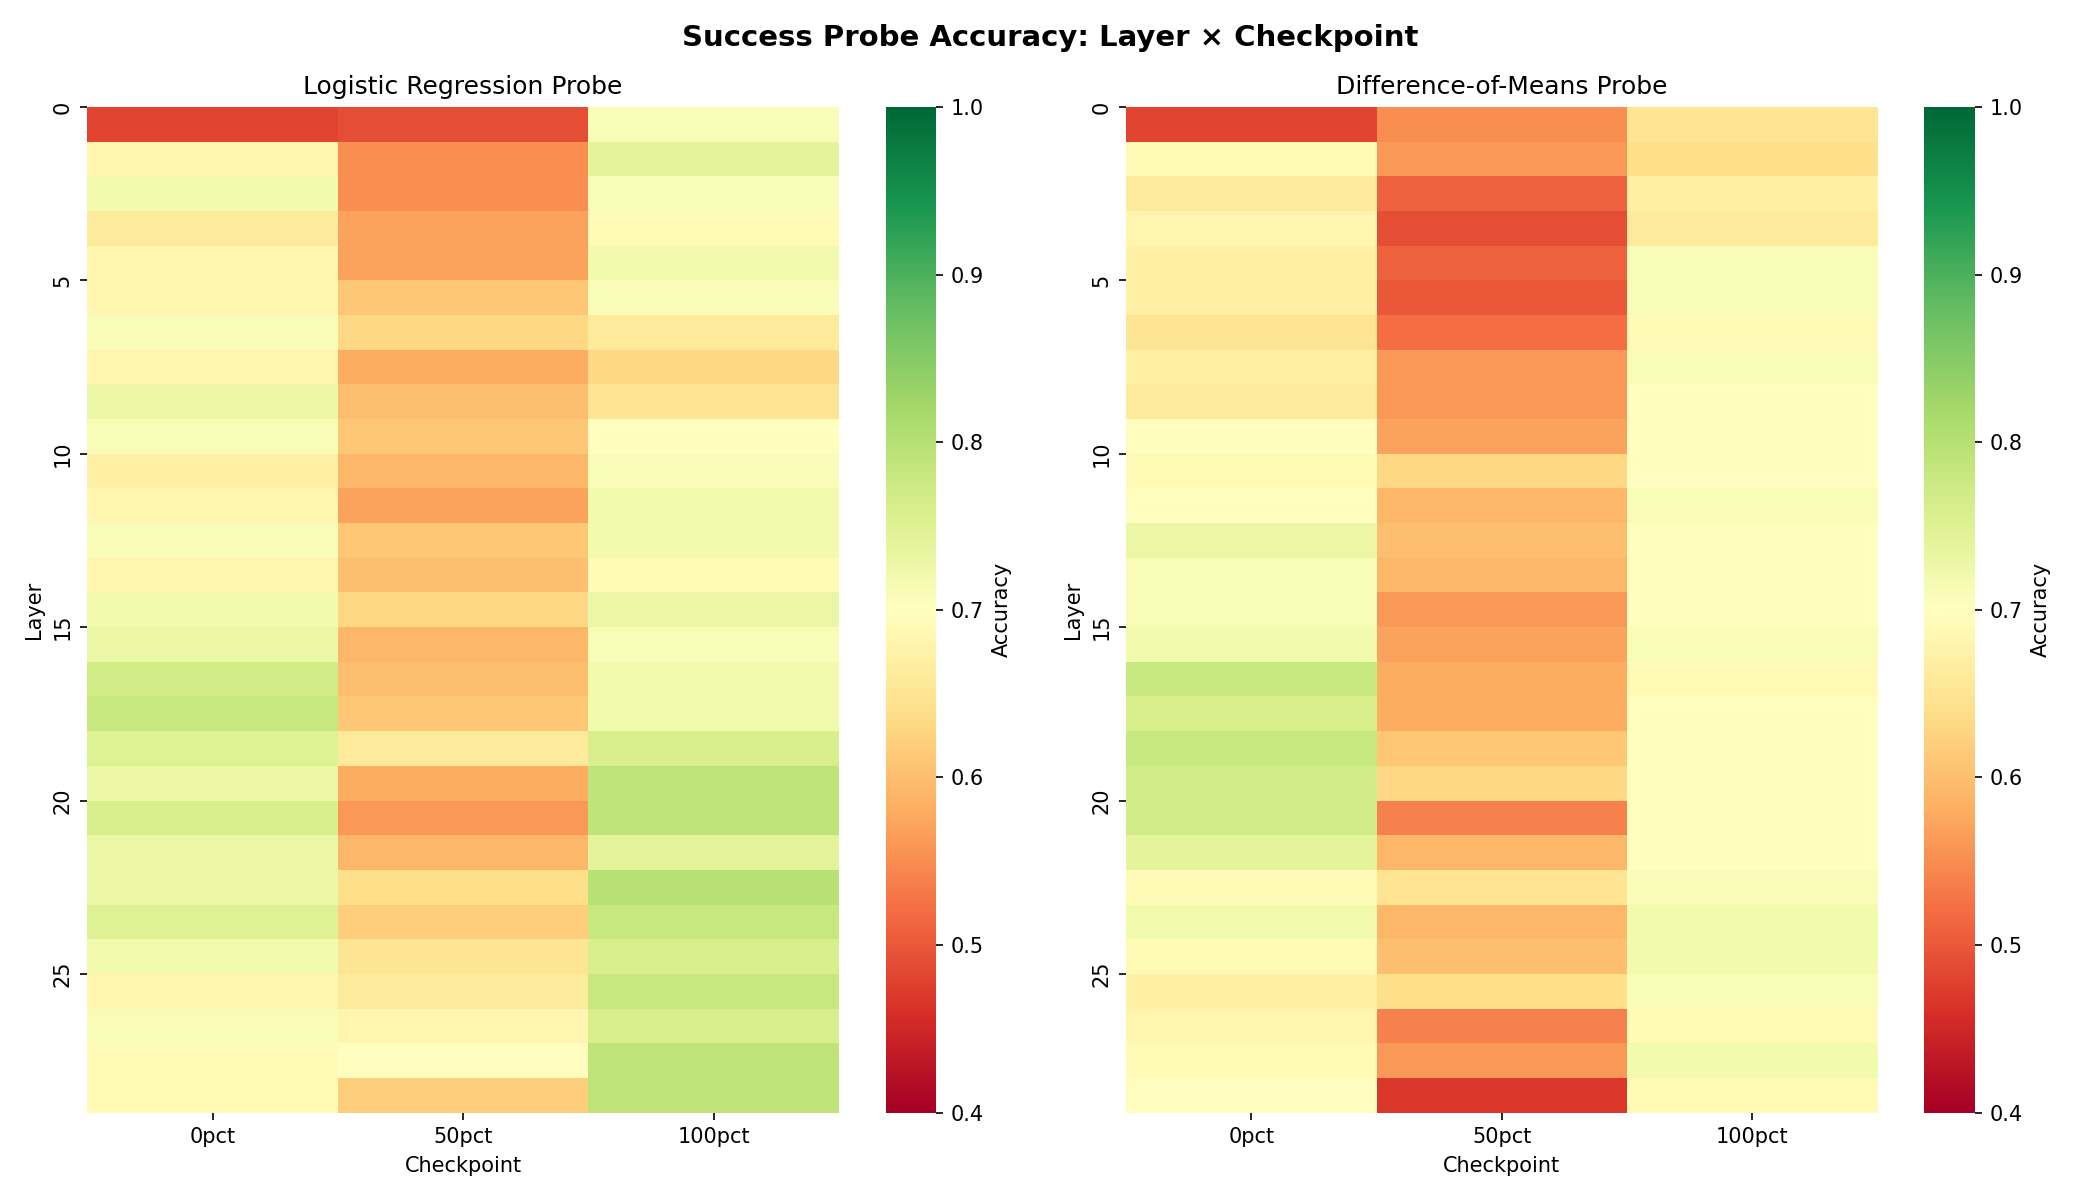


topic_probe_accuracy.png:


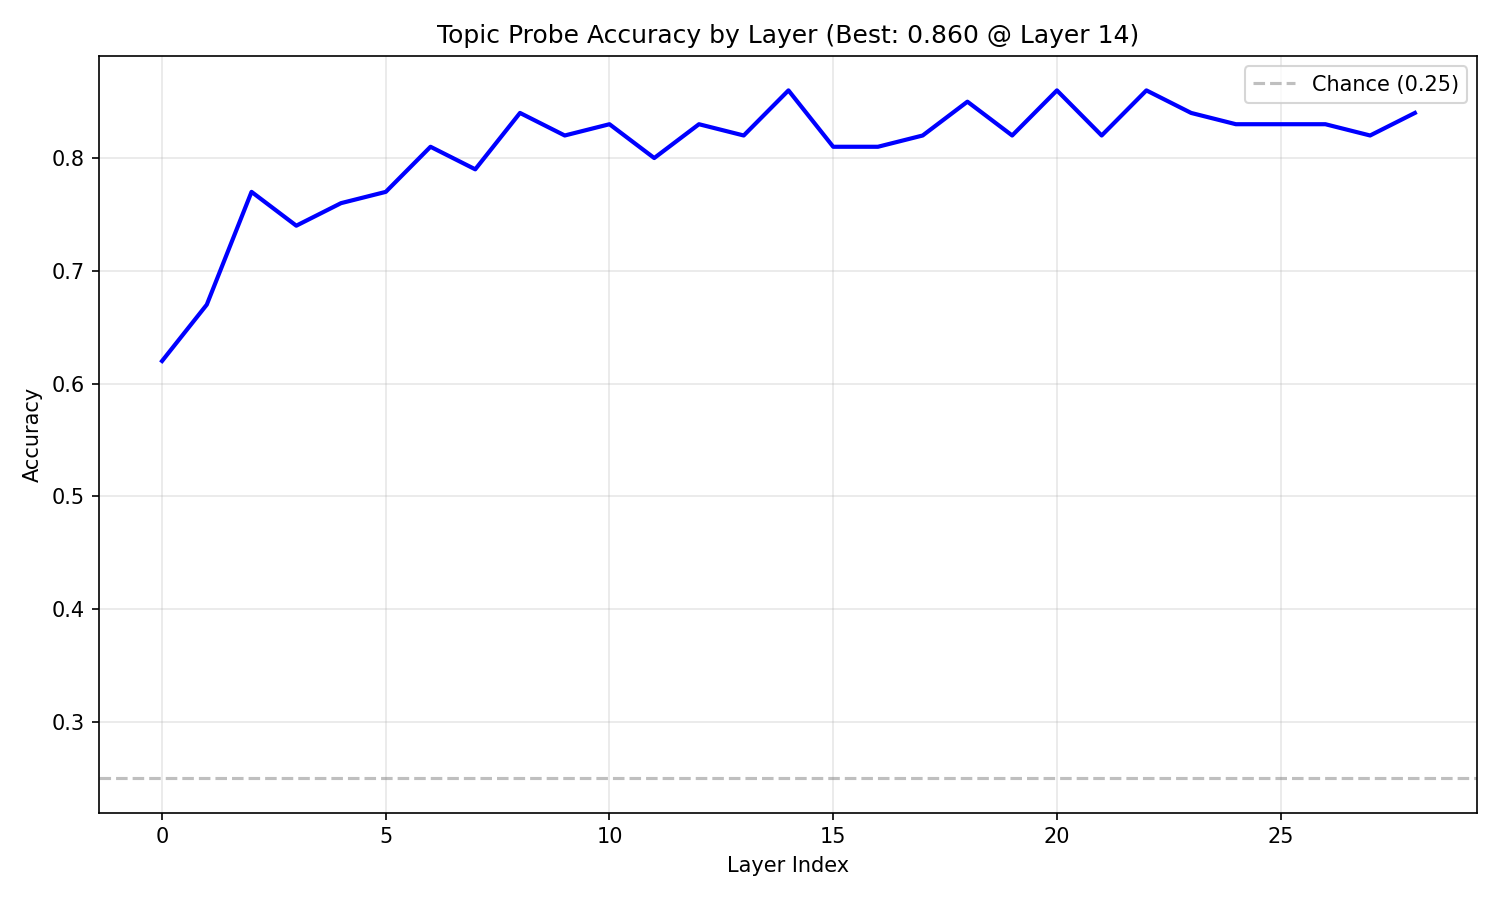

In [11]:
# ============================================================
# CELL 2: MLP PROBES - Train and Save to Drive
# ============================================================
import shutil
import os

DRIVE_DIR = "/content/drive/MyDrive"
fixed_file = "probe_data_1.5b_500_fixed.pt"

# Ensure local copy exists
if not os.path.exists(fixed_file):
    shutil.copy(f"{DRIVE_DIR}/{fixed_file}", fixed_file)

# Train MLP probes
!python probing-llm-math/src/train_probe.py \
    --data_file {fixed_file} \
    --output_dir probe_results_mlp \
    --mlp

# Save to Drive immediately
shutil.copytree("probe_results_mlp", f"{DRIVE_DIR}/probe_results_mlp", dirs_exist_ok=True)
print("✓ MLP results saved to Drive!")

# Display results
from IPython.display import Image, display
for f in sorted(os.listdir("probe_results_mlp")):
    if f.endswith('.png'):
        print(f"\n{f}:")
        display(Image(f"probe_results_mlp/{f}"))

Switched to 7B model. Starting data collection...
Loading math dataset...
README.md: 3.93kB [00:00, 22.1MB/s]
algebra/train-00000-of-00001.parquet: 100% 505k/505k [00:01<00:00, 401kB/s]
algebra/test-00000-of-00001.parquet: 100% 353k/353k [00:00<00:00, 697kB/s]
Generating train split: 100% 1744/1744 [00:00<00:00, 45709.06 examples/s]
Generating test split: 100% 1187/1187 [00:00<00:00, 204495.15 examples/s]
number_theory/train-00000-of-00001.parqu(…): 100% 309k/309k [00:00<00:00, 624kB/s]
number_theory/test-00000-of-00001.parque(…): 100% 182k/182k [00:00<00:00, 346kB/s]
Generating train split: 100% 869/869 [00:00<00:00, 200906.75 examples/s]
Generating test split: 100% 540/540 [00:00<00:00, 166869.83 examples/s]
intermediate_algebra/train-00000-of-0000(…): 100% 575k/575k [00:00<00:00, 1.11MB/s]
intermediate_algebra/test-00000-of-00001(…): 100% 395k/395k [00:00<00:00, 809kB/s]
Generating train split: 100% 1295/1295 [00:00<00:00, 158968.15 examples/s]
Generating test split: 100% 903/903 [0

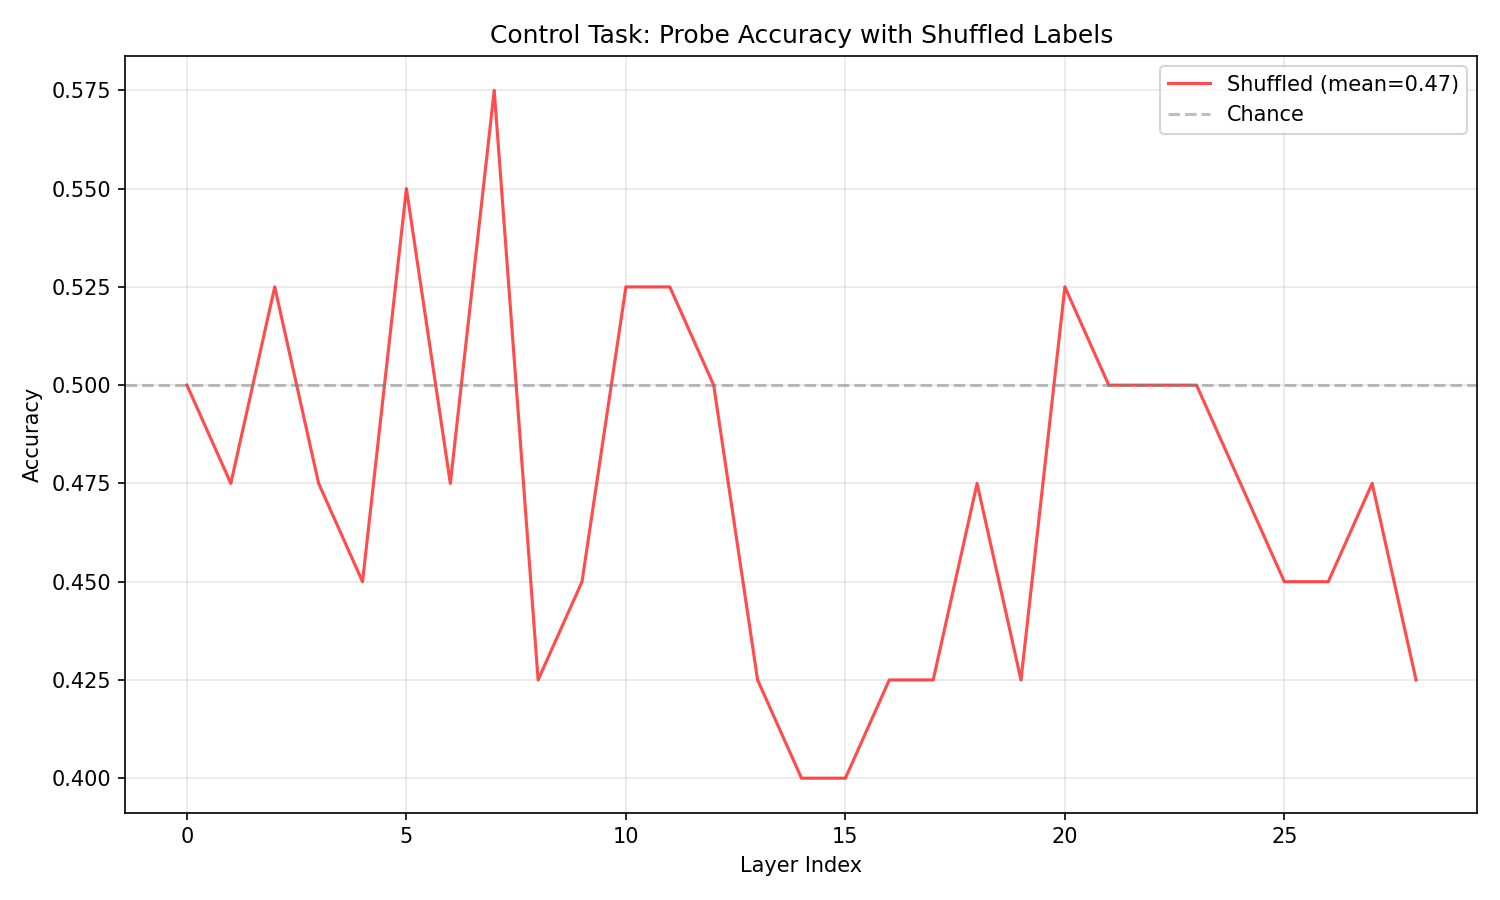


difficulty_probe_classification.png:


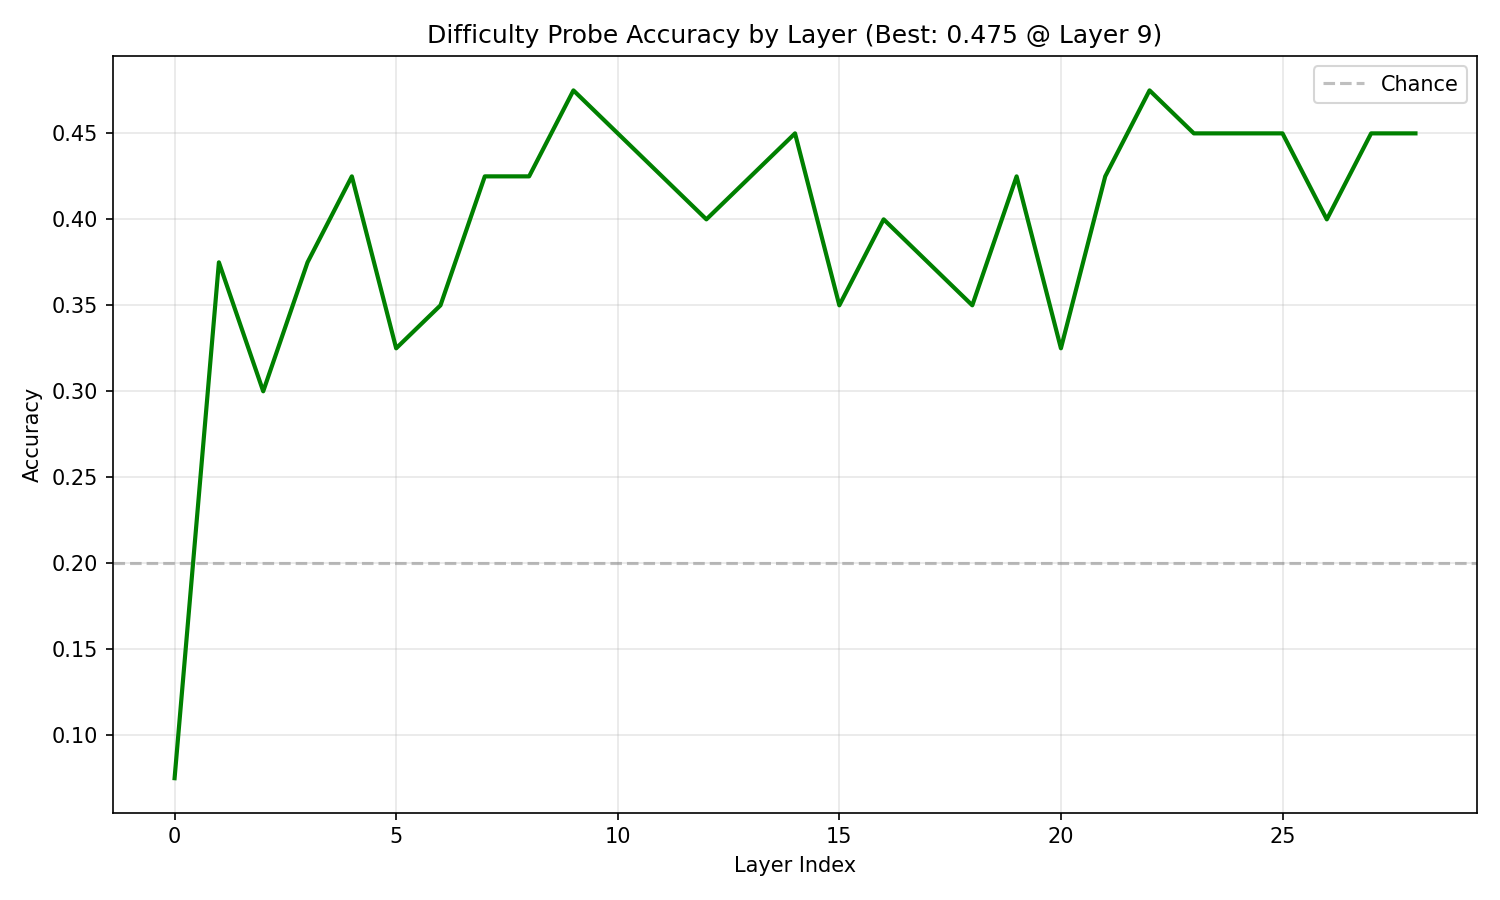


difficulty_probe_regression.png:


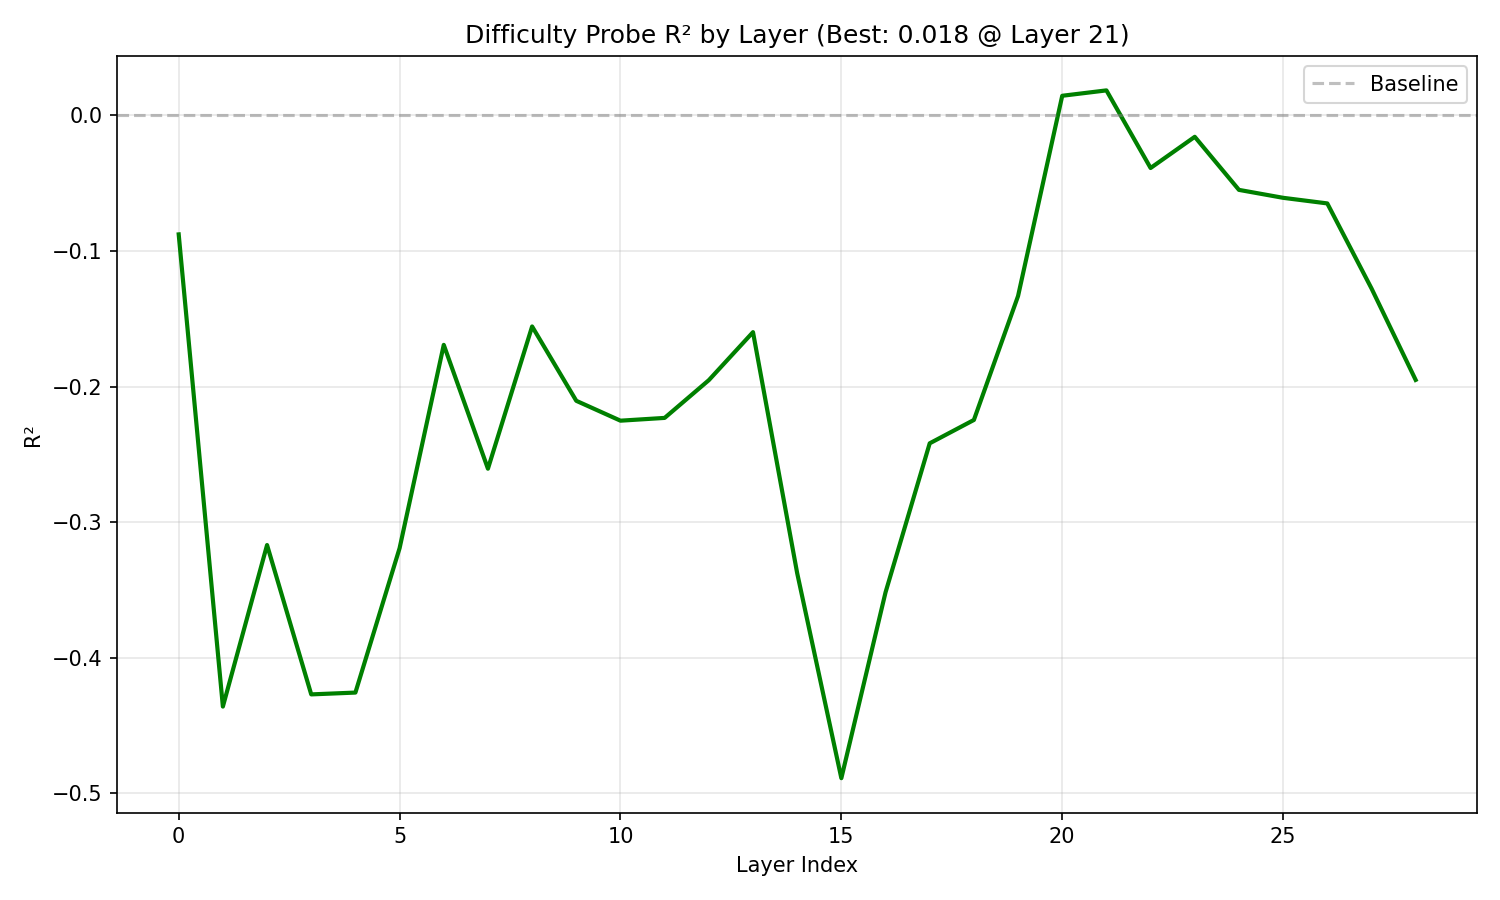


pca_layer20_correctness.png:


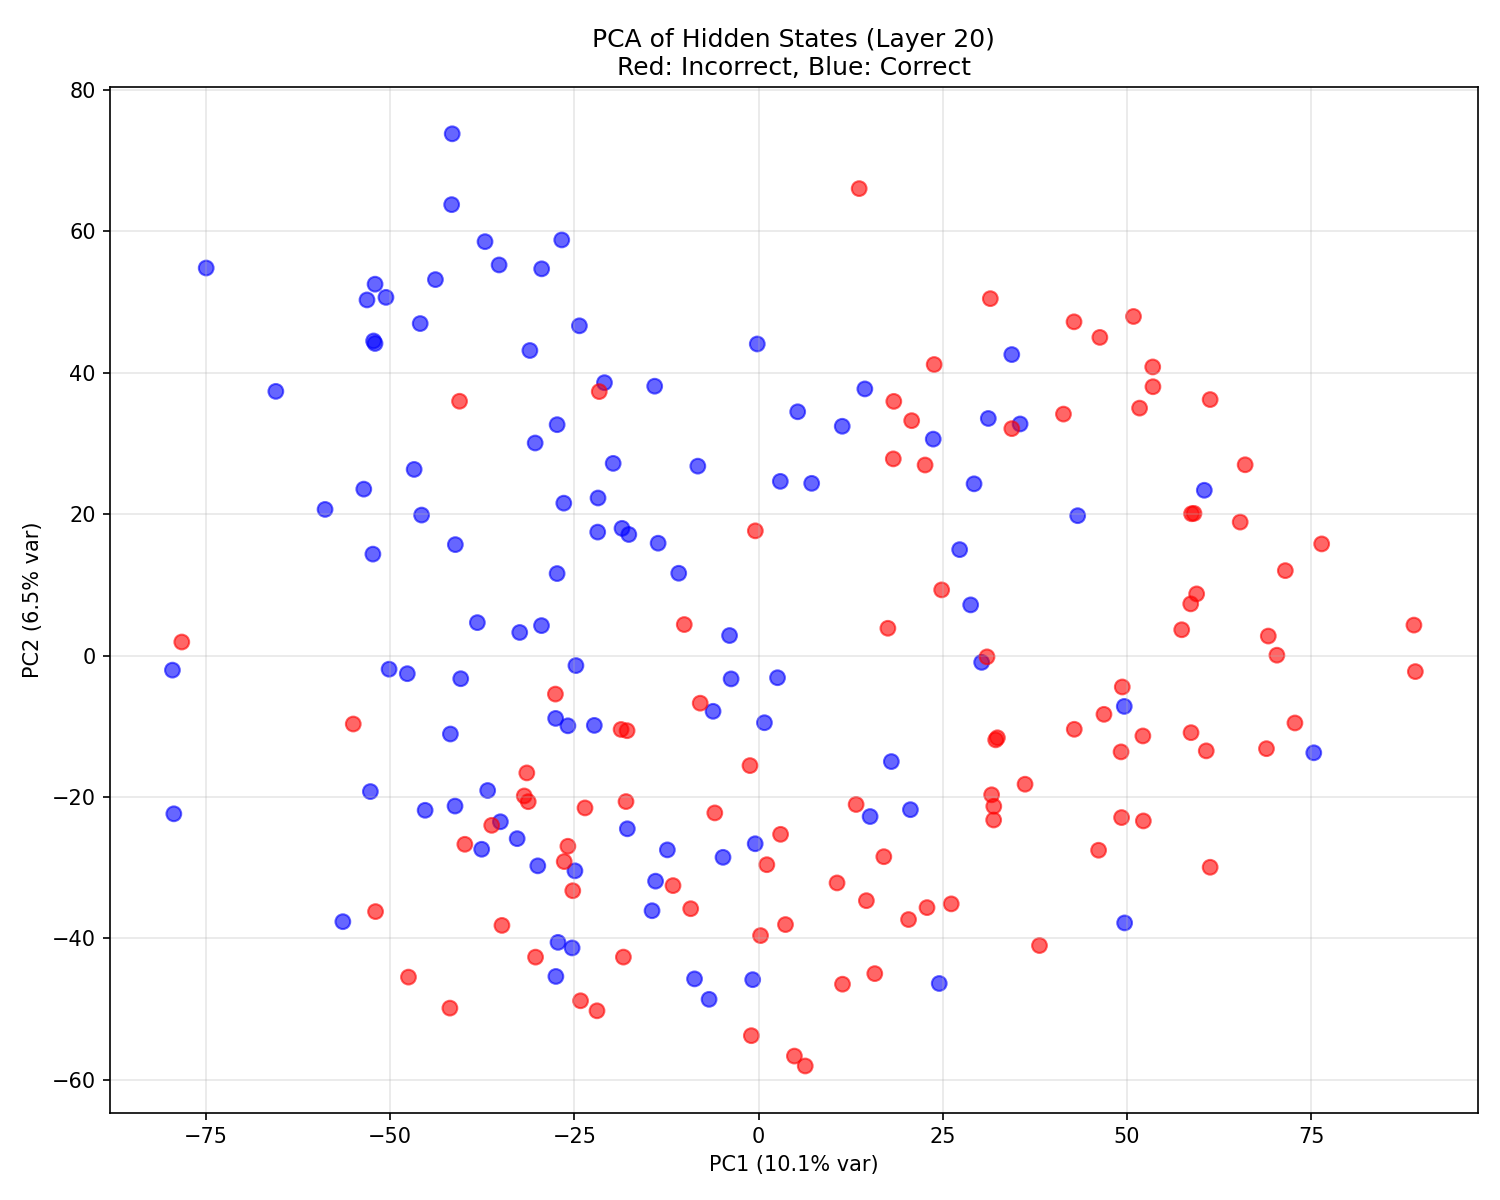


pca_layer20_difficulty.png:


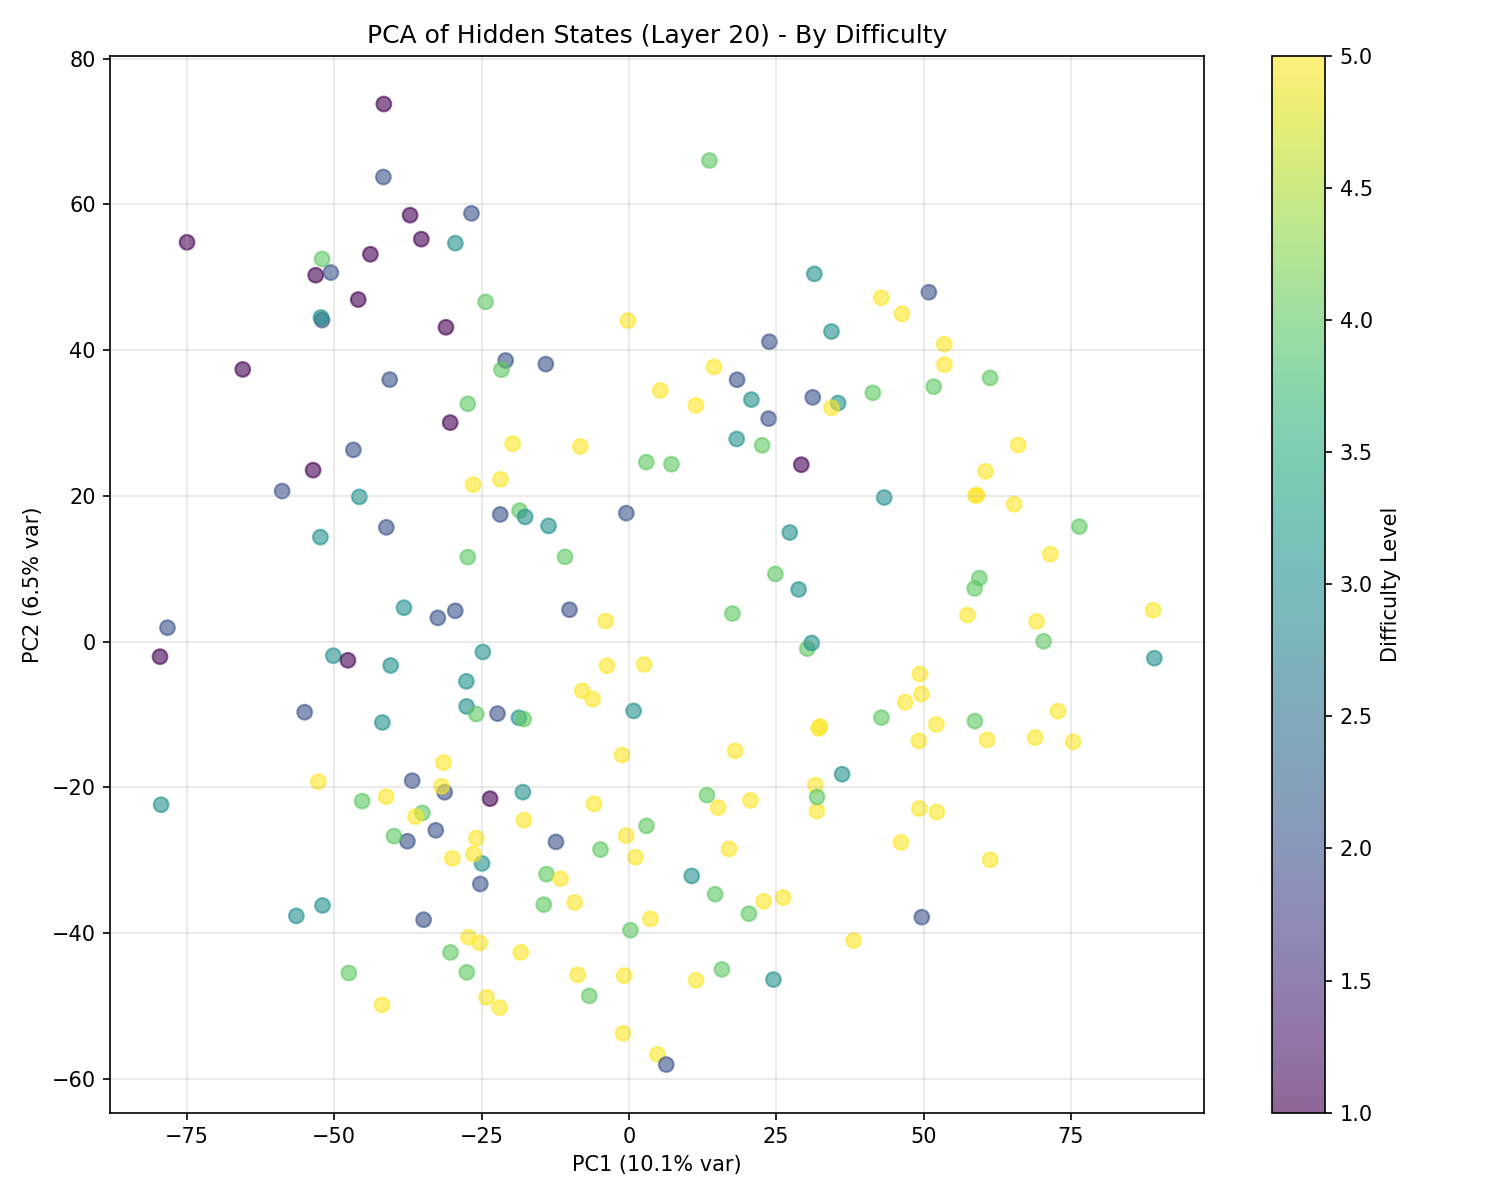


pca_layer20_topic.png:


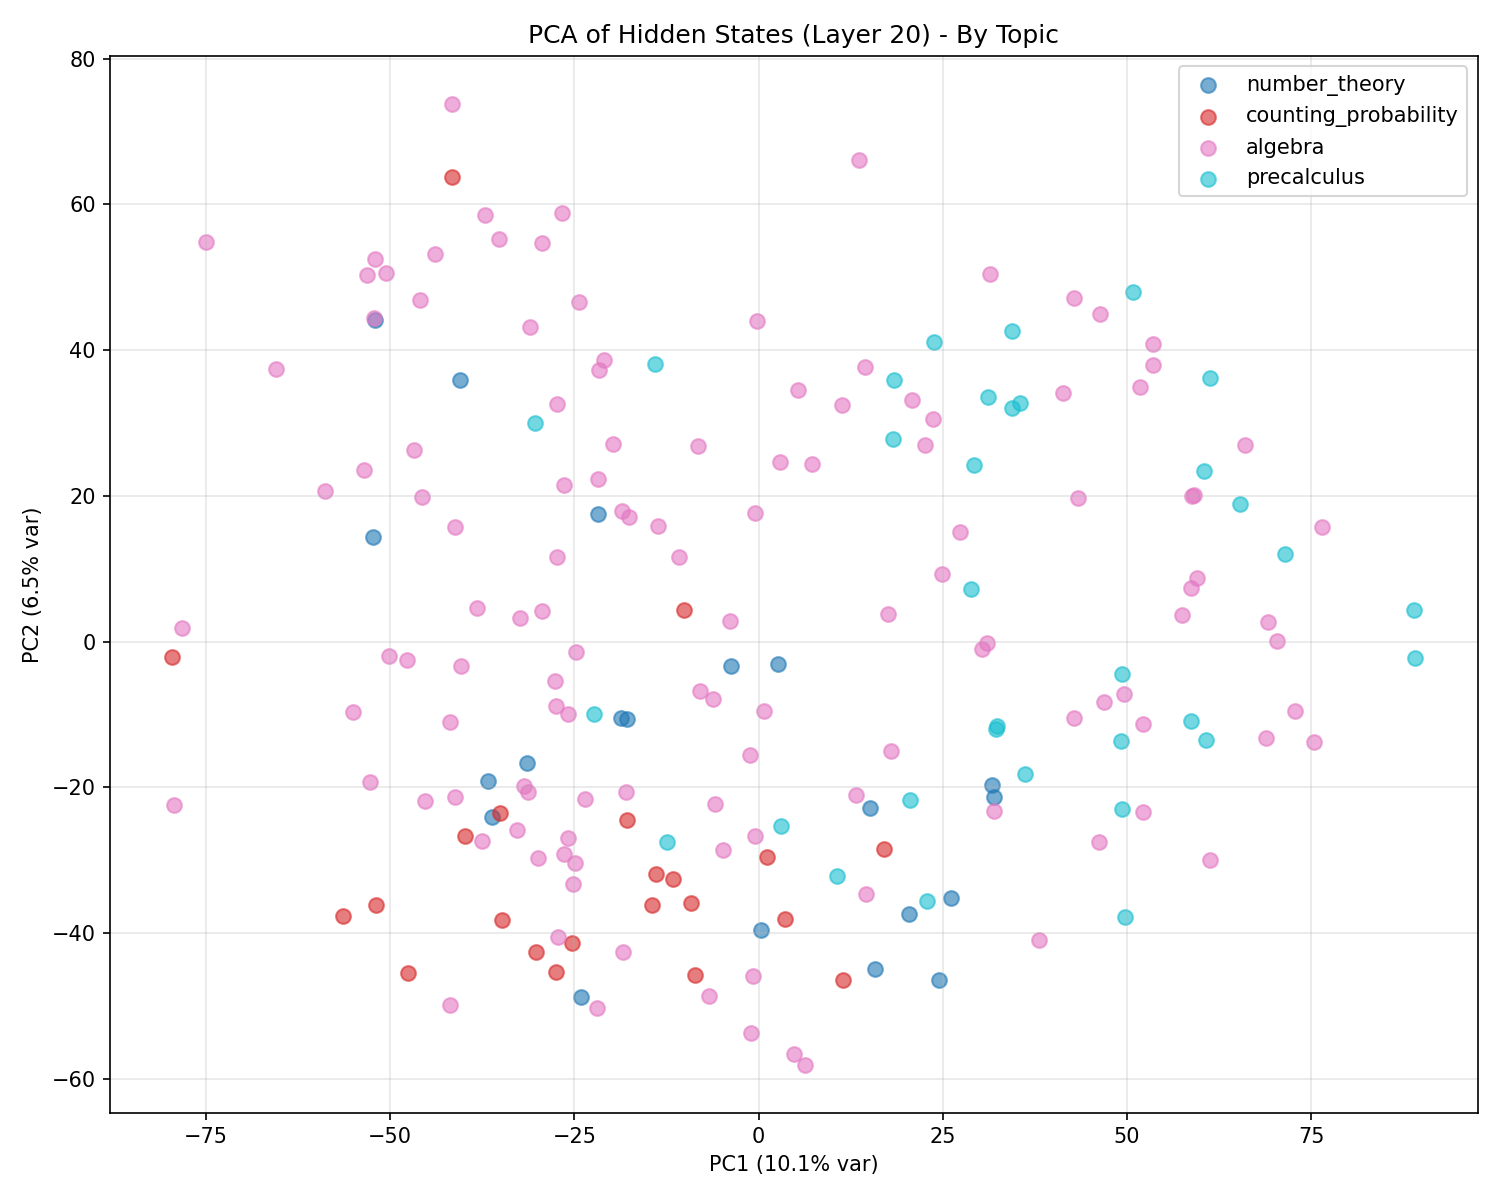


success_probe_accuracy.png:


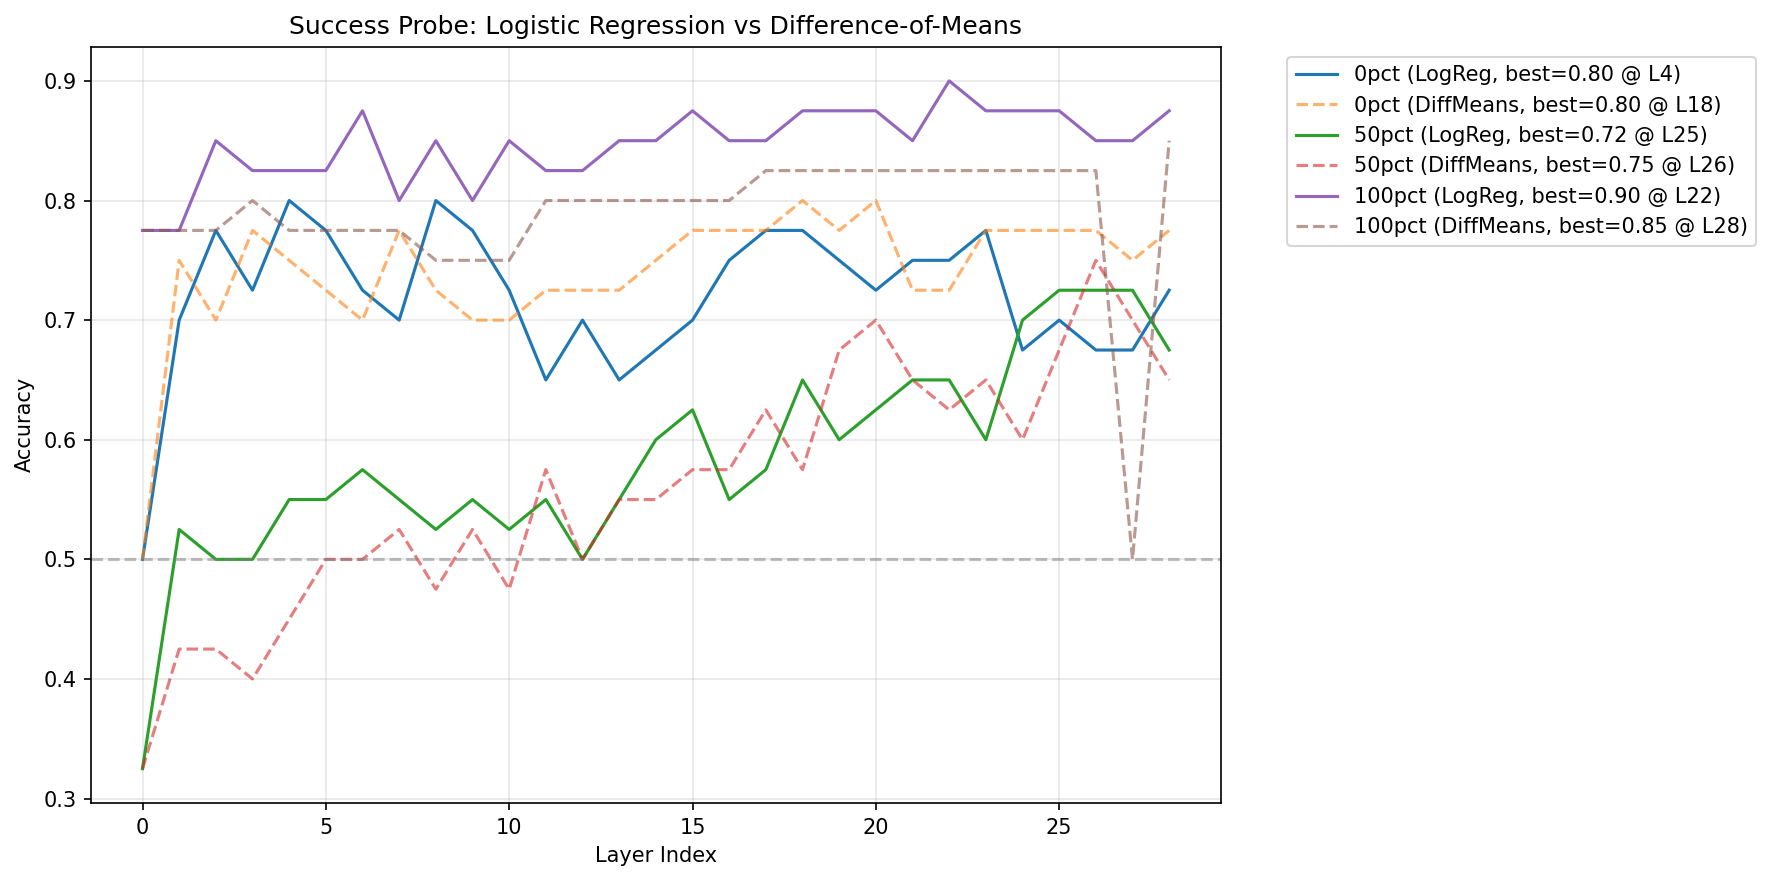


success_probe_heatmap_2d.png:


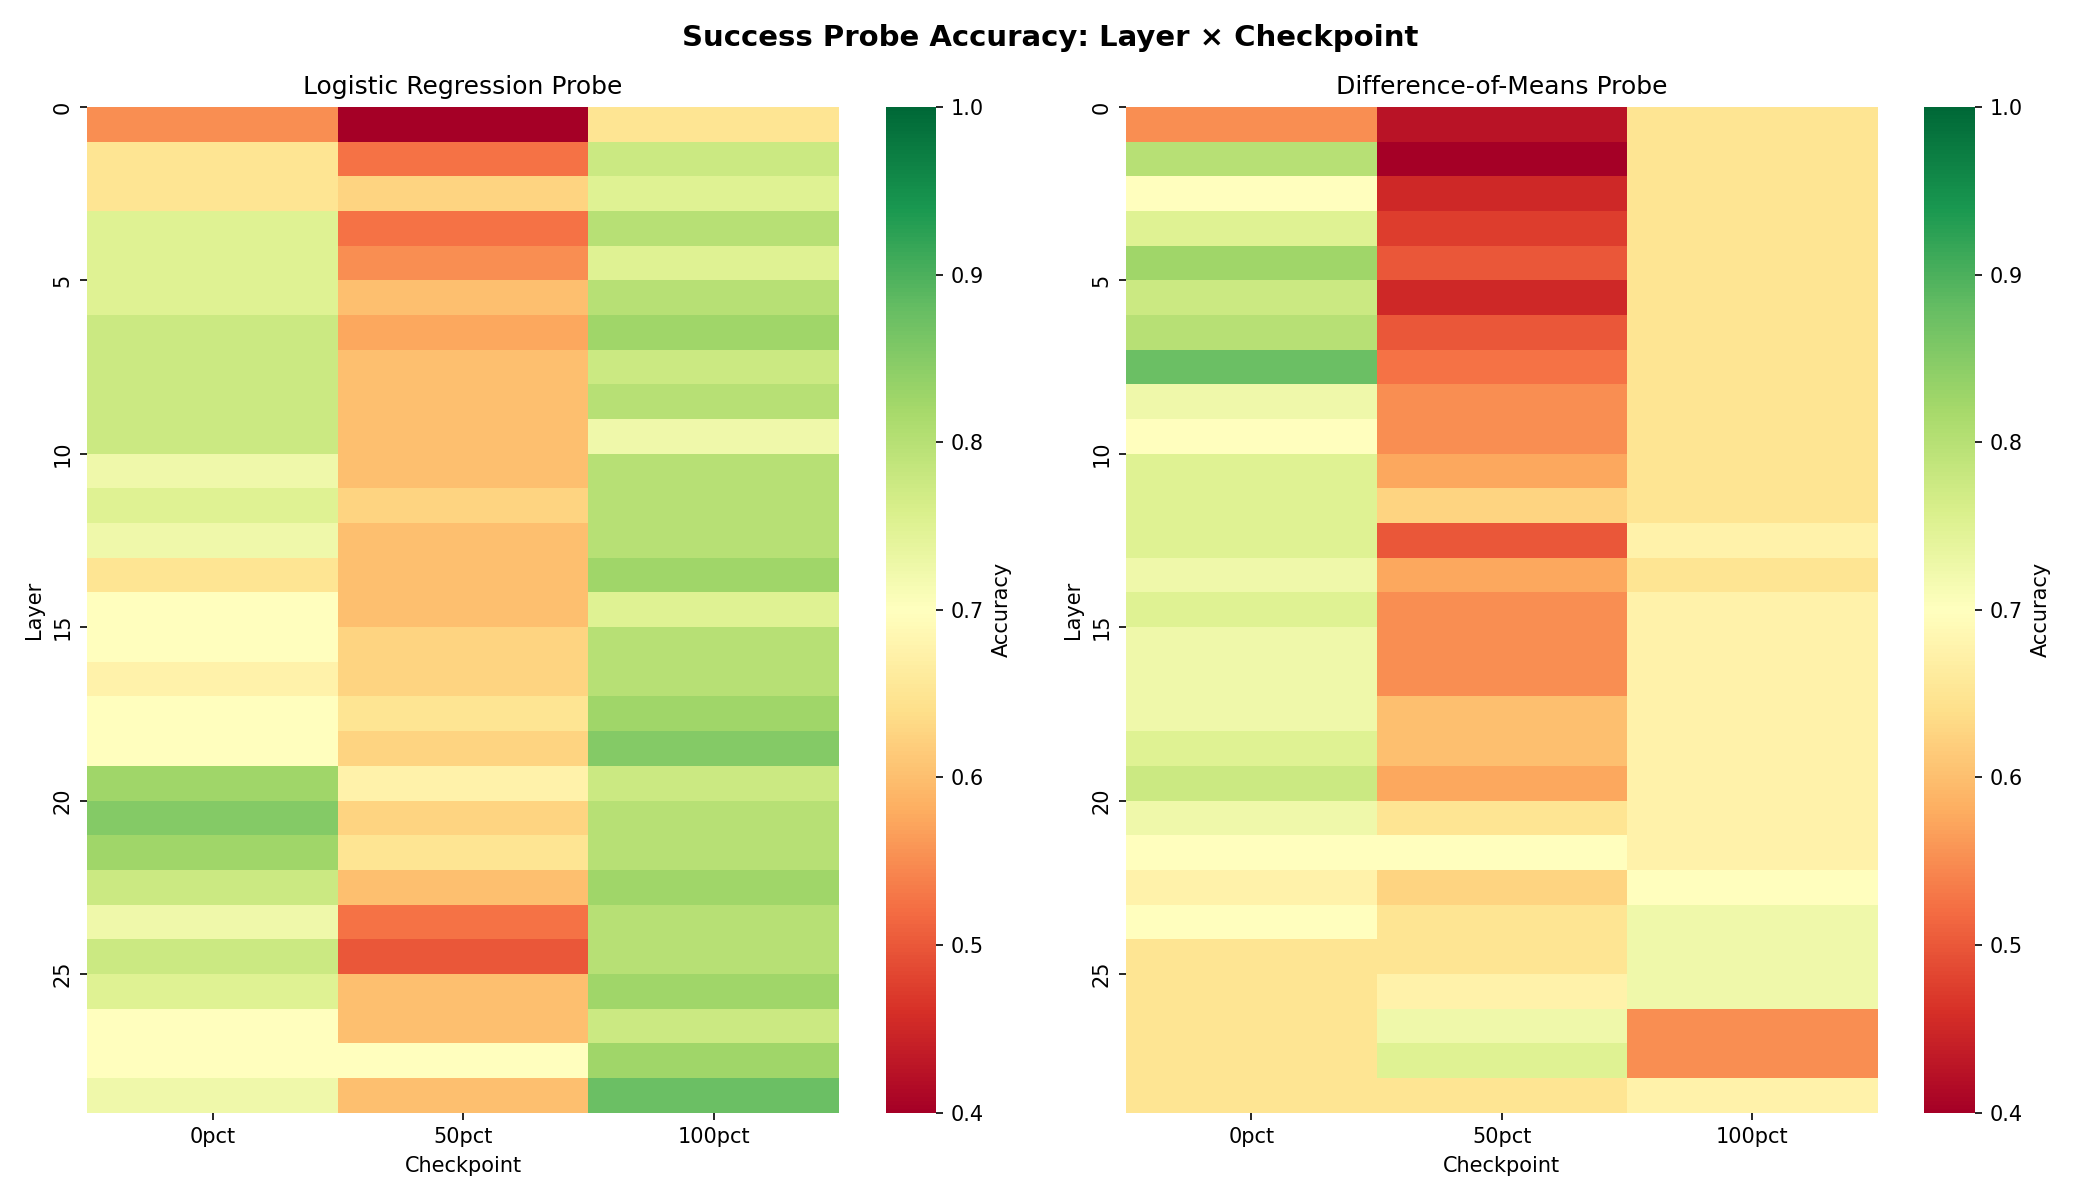


topic_probe_accuracy.png:


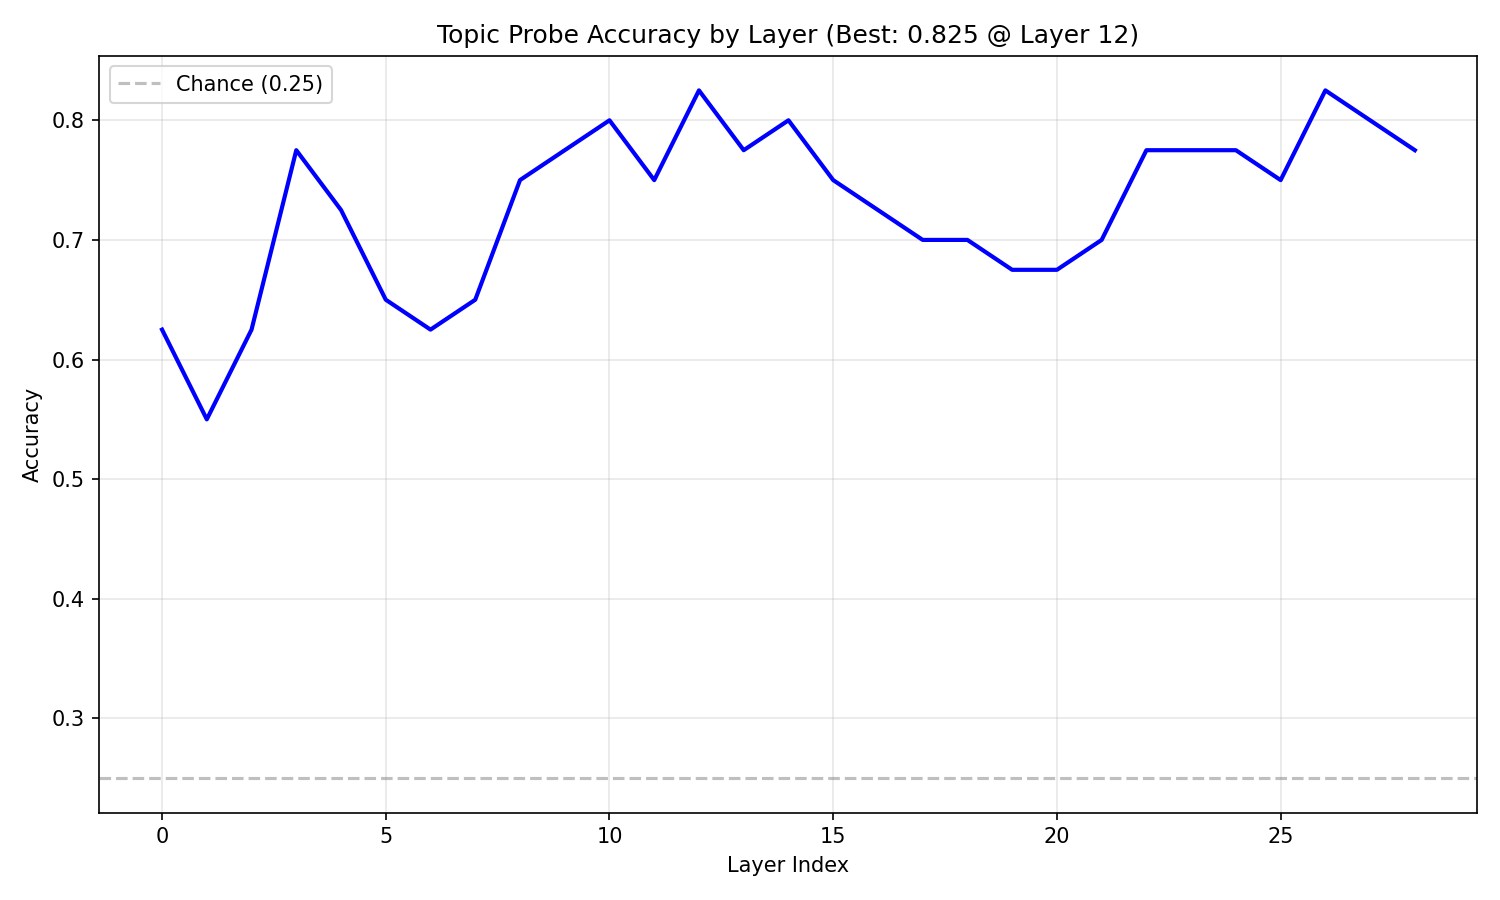

In [12]:
# ============================================================
# CELL 3: 7B MODEL COMPARISON (~5 hours for 200 samples)
# ============================================================
import shutil
import os

DRIVE_DIR = "/content/drive/MyDrive"

# 1. Switch model_utils.py to 7B
!sed -i 's/Qwen2.5-Math-1.5B-Instruct/Qwen2.5-Math-7B-Instruct/g' \
    probing-llm-math/src/model_utils.py

print("Switched to 7B model. Starting data collection...")

# 2. Collect data (200 samples, last_token only for speed)
!python probing-llm-math/src/collect_probe_data.py \
    --num_samples 200 \
    --dataset math \
    --balance \
    --pooling last_token \
    --output_file probe_data_7b_200.pt \
    --seed 42

# 3. Save data to Drive IMMEDIATELY (in case runtime dies)
shutil.copy("probe_data_7b_200.pt", f"{DRIVE_DIR}/probe_data_7b_200.pt")
shutil.copy("probe_audit.csv", f"{DRIVE_DIR}/probe_audit_7b_200.csv")
print("✓ 7B data saved to Drive!")

# 4. Train probes
!python probing-llm-math/src/train_probe.py \
    --data_file probe_data_7b_200.pt \
    --output_dir probe_results_7b

# 5. Save probe results to Drive
shutil.copytree("probe_results_7b", f"{DRIVE_DIR}/probe_results_7b", dirs_exist_ok=True)
print("✓ 7B probe results saved to Drive!")

# 6. Display results
from IPython.display import Image, display
for f in sorted(os.listdir("probe_results_7b")):
    if f.endswith('.png'):
        print(f"\n{f}:")
        display(Image(f"probe_results_7b/{f}"))

In [13]:
# ============================================================
# CELL 4: REVERT TO 1.5B MODEL
# ============================================================

# Revert model_utils.py back to 1.5B
!sed -i 's/Qwen2.5-Math-7B-Instruct/Qwen2.5-Math-1.5B-Instruct/g' \
    probing-llm-math/src/model_utils.py

# Verify the change
!grep "Qwen2.5-Math" probing-llm-math/src/model_utils.py

# Clear model from VRAM
import gc
import torch
try:
    del model
    del tokenizer
except:
    pass
gc.collect()
torch.cuda.empty_cache()

print("✓ Reverted to 1.5B model and cleared VRAM")

def load_model(model_name="Qwen/Qwen2.5-Math-1.5B-Instruct", device="cuda", load_in_4bit=True):
✓ Reverted to 1.5B model and cleared VRAM
